# Untied attention model for realistic data

In [124]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import glob
import os
import seaborn as sns
import string
from matplotlib.patches import Rectangle

In [125]:
run_id = "20251218_1108" # sans mask
# run_id = "20251216_1605" # avec mask

# run_id = "20251220_1538" # dmlp 10

# run_id = "20251230_1021"

run_dir = f"../results/run_{run_id}/"
config_path = f"../results/run_{run_id}/config.csv"
base_path = f"../results/run_{run_id}/summary.csv"

plot_path = f"../results/run_{run_id}/plots/"
os.makedirs(plot_path, exist_ok=True)

In [126]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
    'figure.dpi': 300,
    'savefig.bbox': 'tight',
})

## 1. experiment config

In [127]:
# --- Read the CSV file ---
config = pd.read_csv(config_path)
print(f"⚙️ Config loaded ({len(config)} rows) from {config_path}")

# --- Quick preview ---
display(config)

⚙️ Config loaded (15 rows) from ../results/run_20251218_1108/config.csv


,D,L,T,d_mlp_list,alpha,rho,beta,lambda_candidates,k_folds,samples,...,run_index,seed,batch_size,R,N_alpha,N_ft,N_train,N,MLP_dim,lambda
0,100,15,30,[100],0.010000,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,0,42,64,100,100,0,100,2100,100,0.00001
1,100,15,30,[100],0.080714,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,1,42,64,100,807,0,807,2807,100,0.00010
2,100,15,30,[100],0.151429,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,2,42,64,100,1514,0,1514,3514,100,0.00010
3,100,15,30,[100],0.292857,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,4,42,64,100,2928,0,2928,4928,100,0.00010
4,100,15,30,[100],0.222143,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,3,42,64,100,2221,0,2221,4221,100,0.00001
5,100,15,30,[100],0.434286,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,6,42,64,100,4342,0,4342,6342,100,0.00010
6,100,15,30,[100],0.505000,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,7,42,64,100,5050,0,5050,7050,100,0.00010
7,100,15,30,[100],0.363571,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,5,42,64,100,3635,0,3635,5635,100,0.00010
8,100,15,30,[100],0.575714,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,8,42,64,100,5757,0,5757,7757,100,0.00010
9,100,15,30,[100],0.929286,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,13,42,64,100,9292,0,9292,11292,100,0.00010


## 2. Metrics for parameters ($\alpha$, $d_{MLP}$, $p_{ft}$)

✅ Summary loaded (15 rows) from ../results/run_20251218_1108/summary.csv


,alpha,MLP_dim,rho,p_ft,lamda,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,...,acc_train_mean,acc_train_std,rank_Q_before_mean,rank_Q_before_std,rank_K_before_mean,rank_K_before_std,rank_Q_after_mean,rank_Q_after_std,rank_K_after_mean,rank_K_after_std
0,0.010000,100,1.0,0.0,0.00001,0.767183,0.012330,0.000015,0.000016,0.000031,...,0.944109,0.057144,100.0,0.000000,99.9,0.316228,100.0,0.000000,99.9,0.316228
1,0.080714,100,1.0,0.0,0.00010,0.463255,0.059917,0.000087,0.000042,0.000129,...,0.678222,0.099034,85.5,8.834906,84.8,9.295160,85.5,8.834906,84.8,9.295160
2,0.151429,100,1.0,0.0,0.00010,0.338693,0.082759,0.000086,0.000040,0.000126,...,0.691667,0.097565,83.8,7.004760,84.0,7.133645,83.8,7.004760,84.0,7.133645
3,0.292857,100,1.0,0.0,0.00010,0.338433,0.052884,0.000094,0.000040,0.000134,...,0.672373,0.056150,76.4,9.593980,76.1,8.332667,76.4,9.593980,76.1,8.332667
4,0.222143,100,1.0,0.0,0.00001,0.392842,0.094825,0.000091,0.000012,0.000102,...,0.651631,0.089628,93.2,7.656515,92.0,9.545214,93.2,7.656515,92.0,9.545214


✅ Summary loaded (15 rows)
✅ Saved plot: ../results/run_20251218_1108/plots/label_error_vs_alpha_run20251218_1108.png


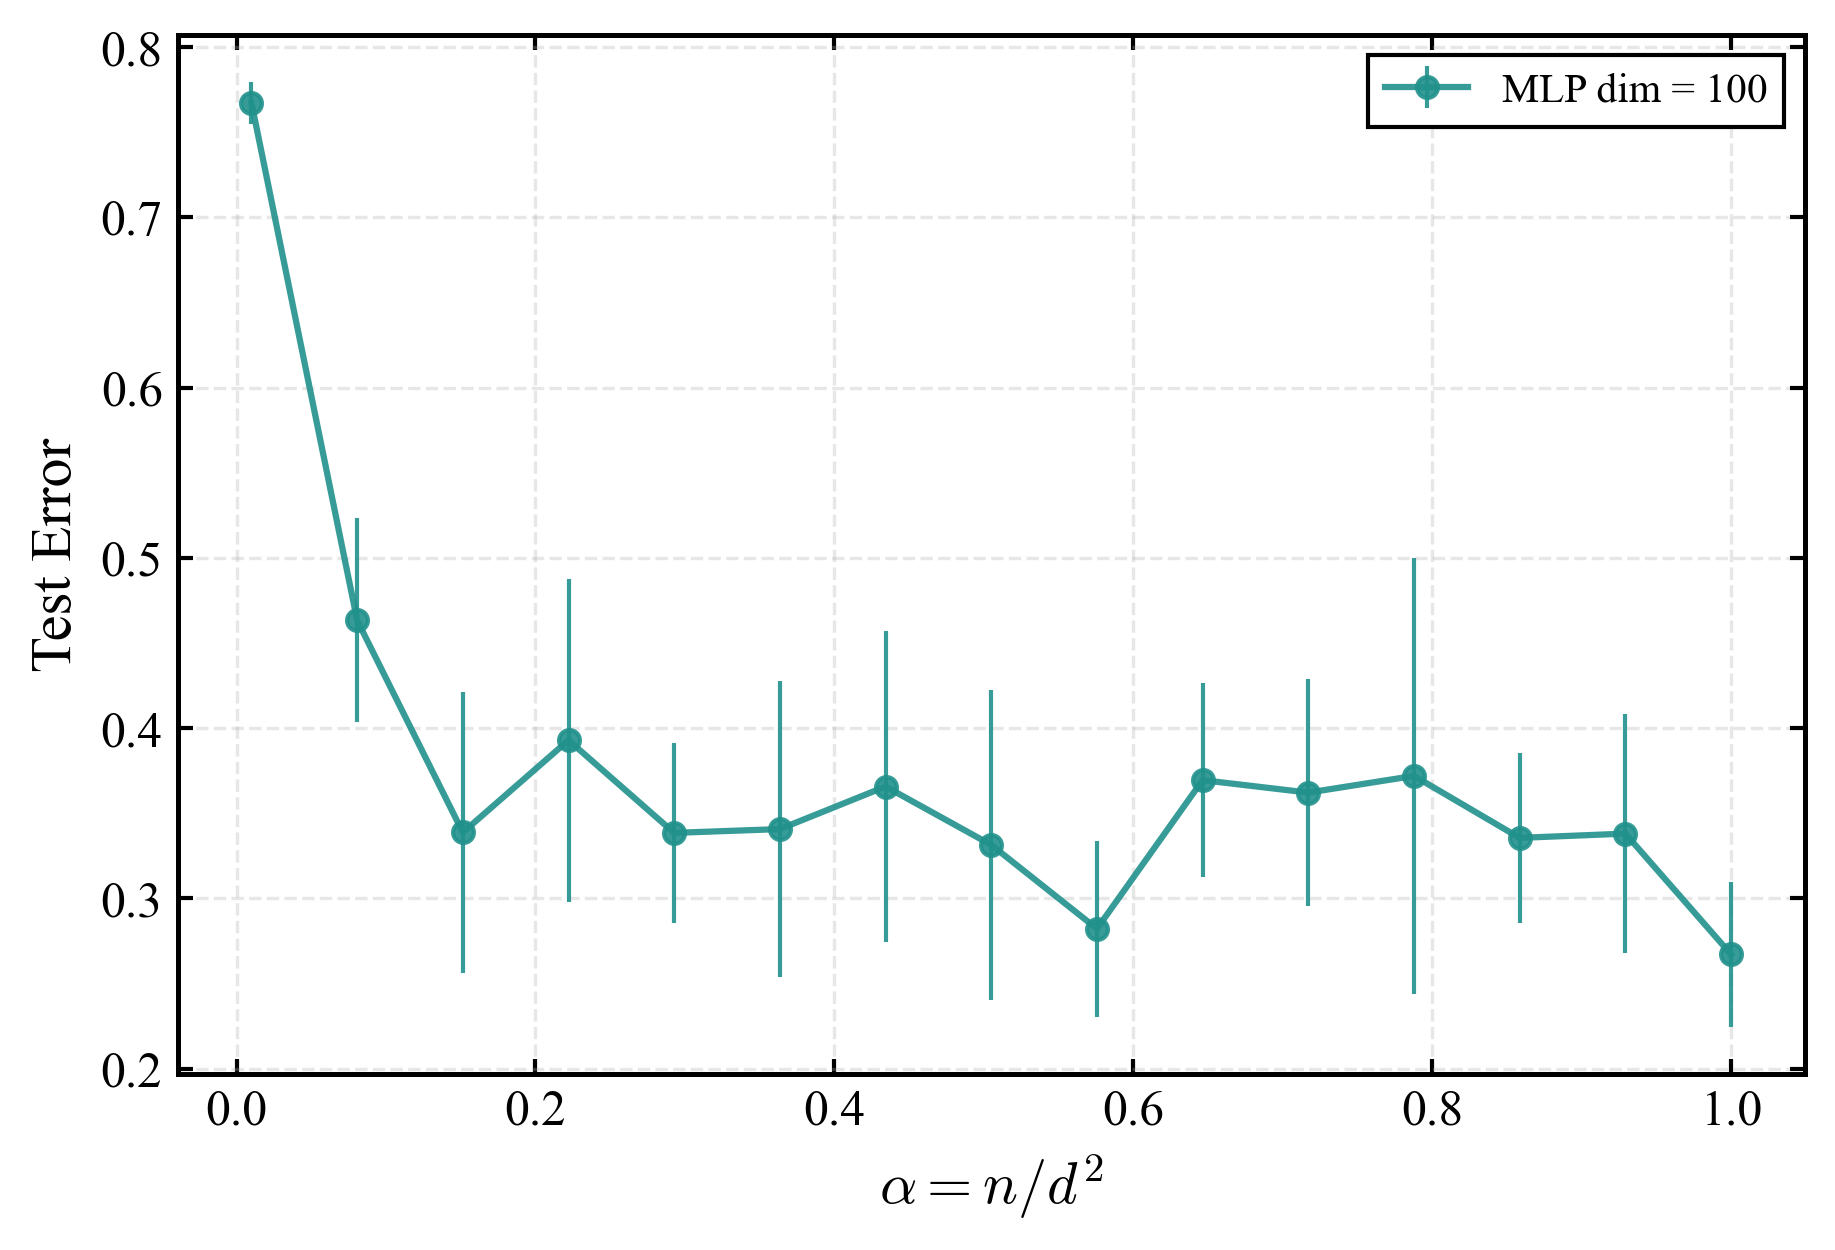

✅ Saved plot: ../results/run_20251218_1108/plots/train_data_vs_alpha_run20251218_1108.png


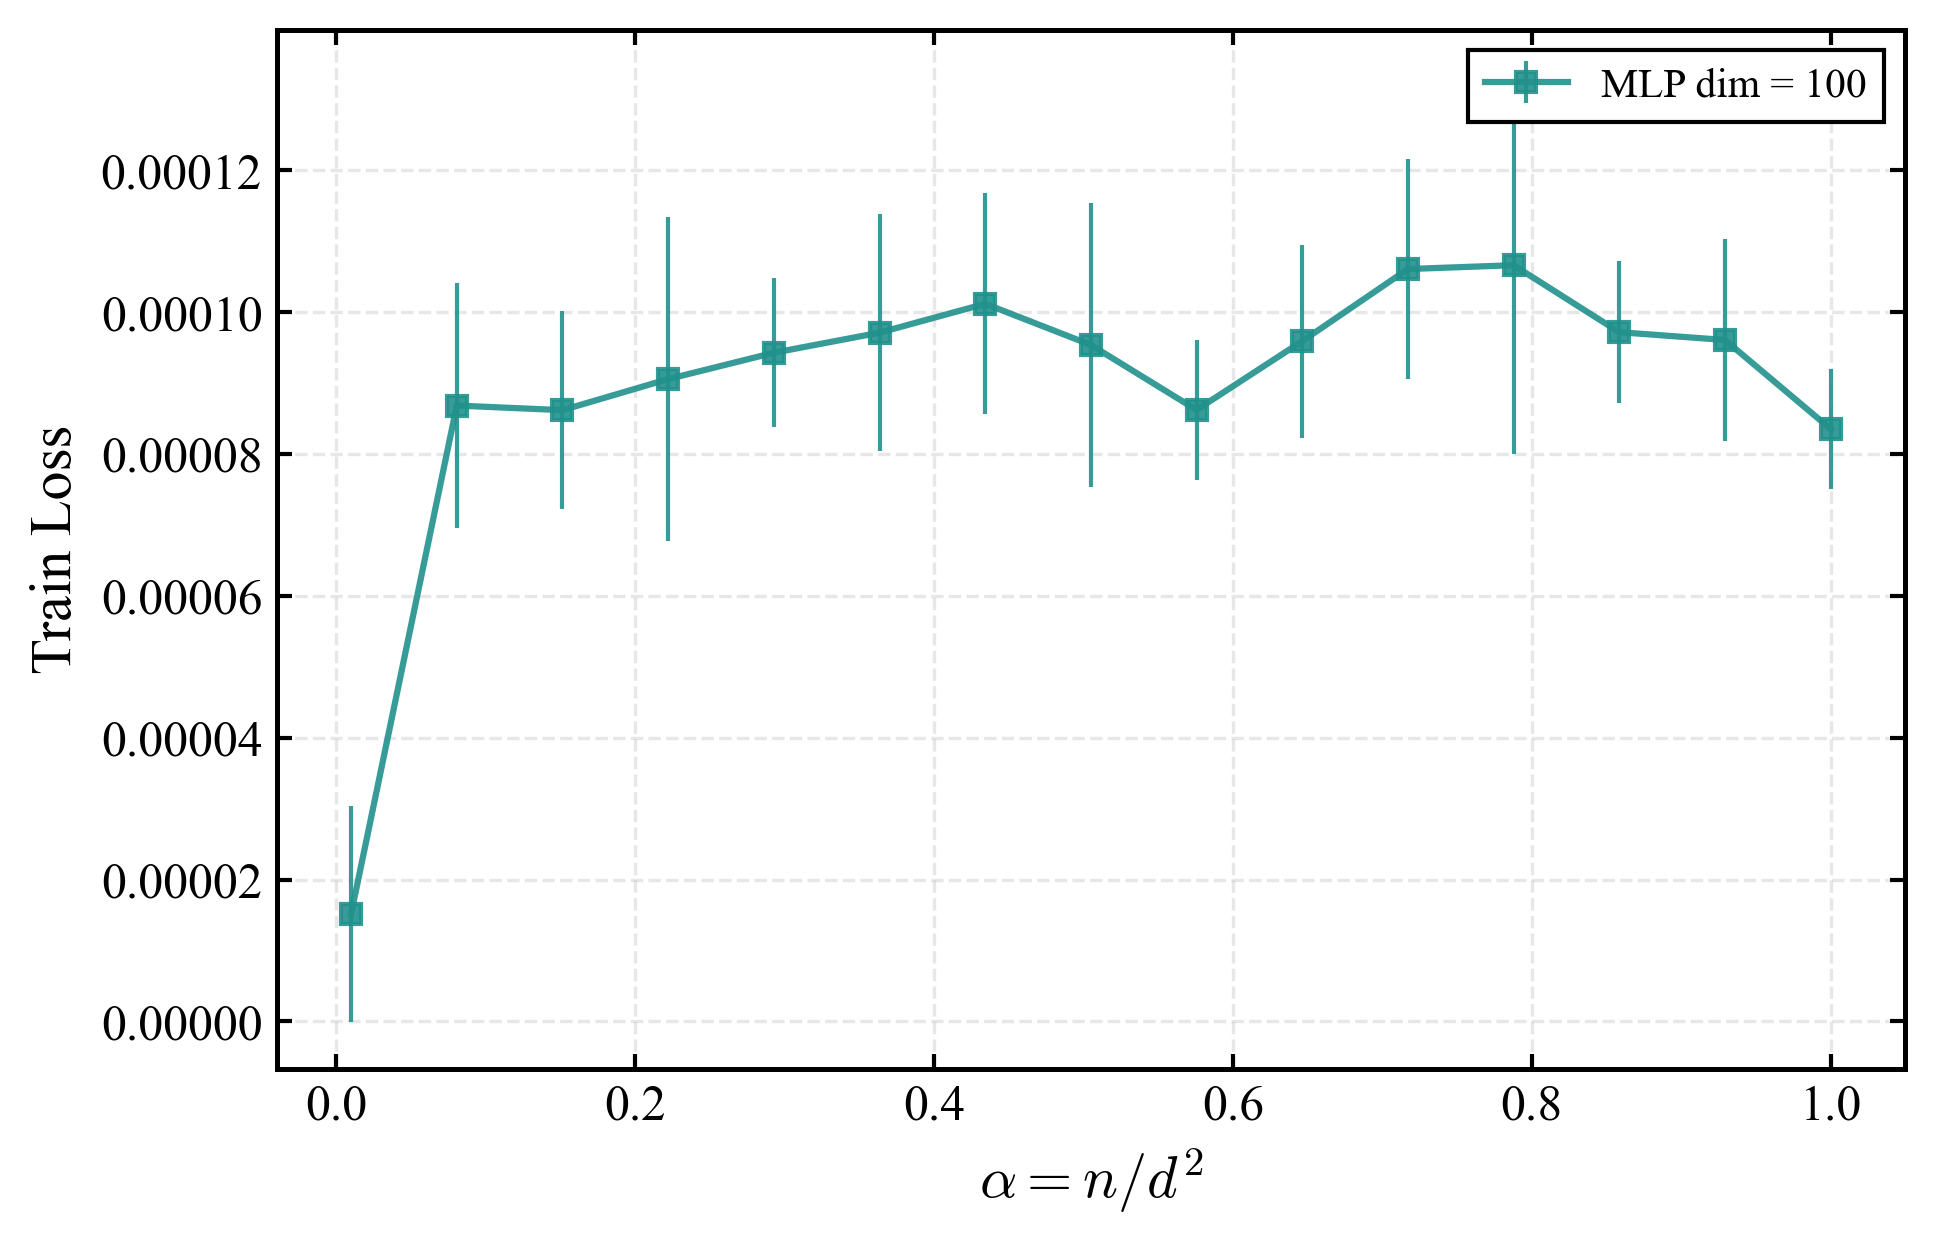

✅ Saved plot: ../results/run_20251218_1108/plots/train_accuracy_vs_alpha_run20251218_1108.png


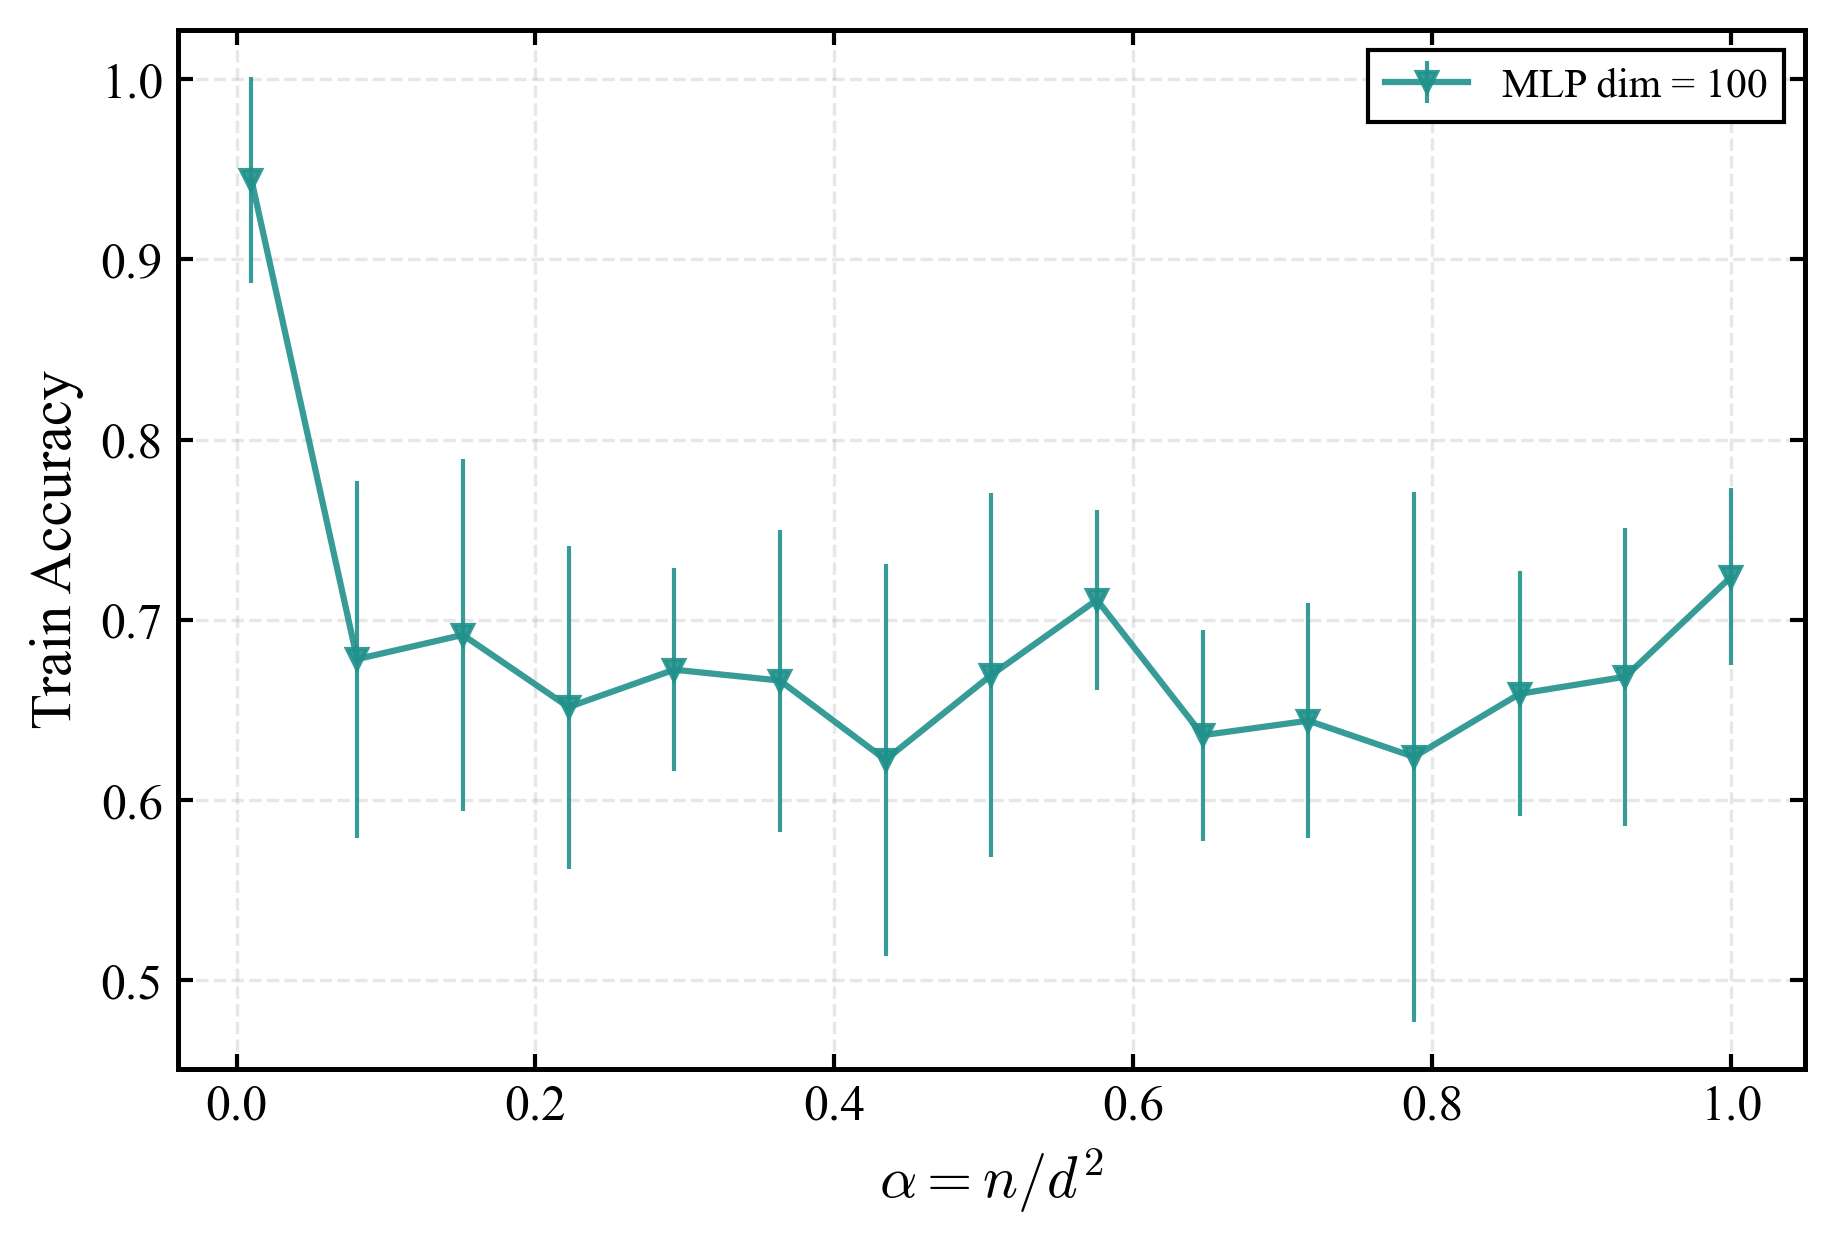

✅ Saved plot: ../results/run_20251218_1108/plots/fine_tune_accuracy_vs_alpha_run20251218_1108.png


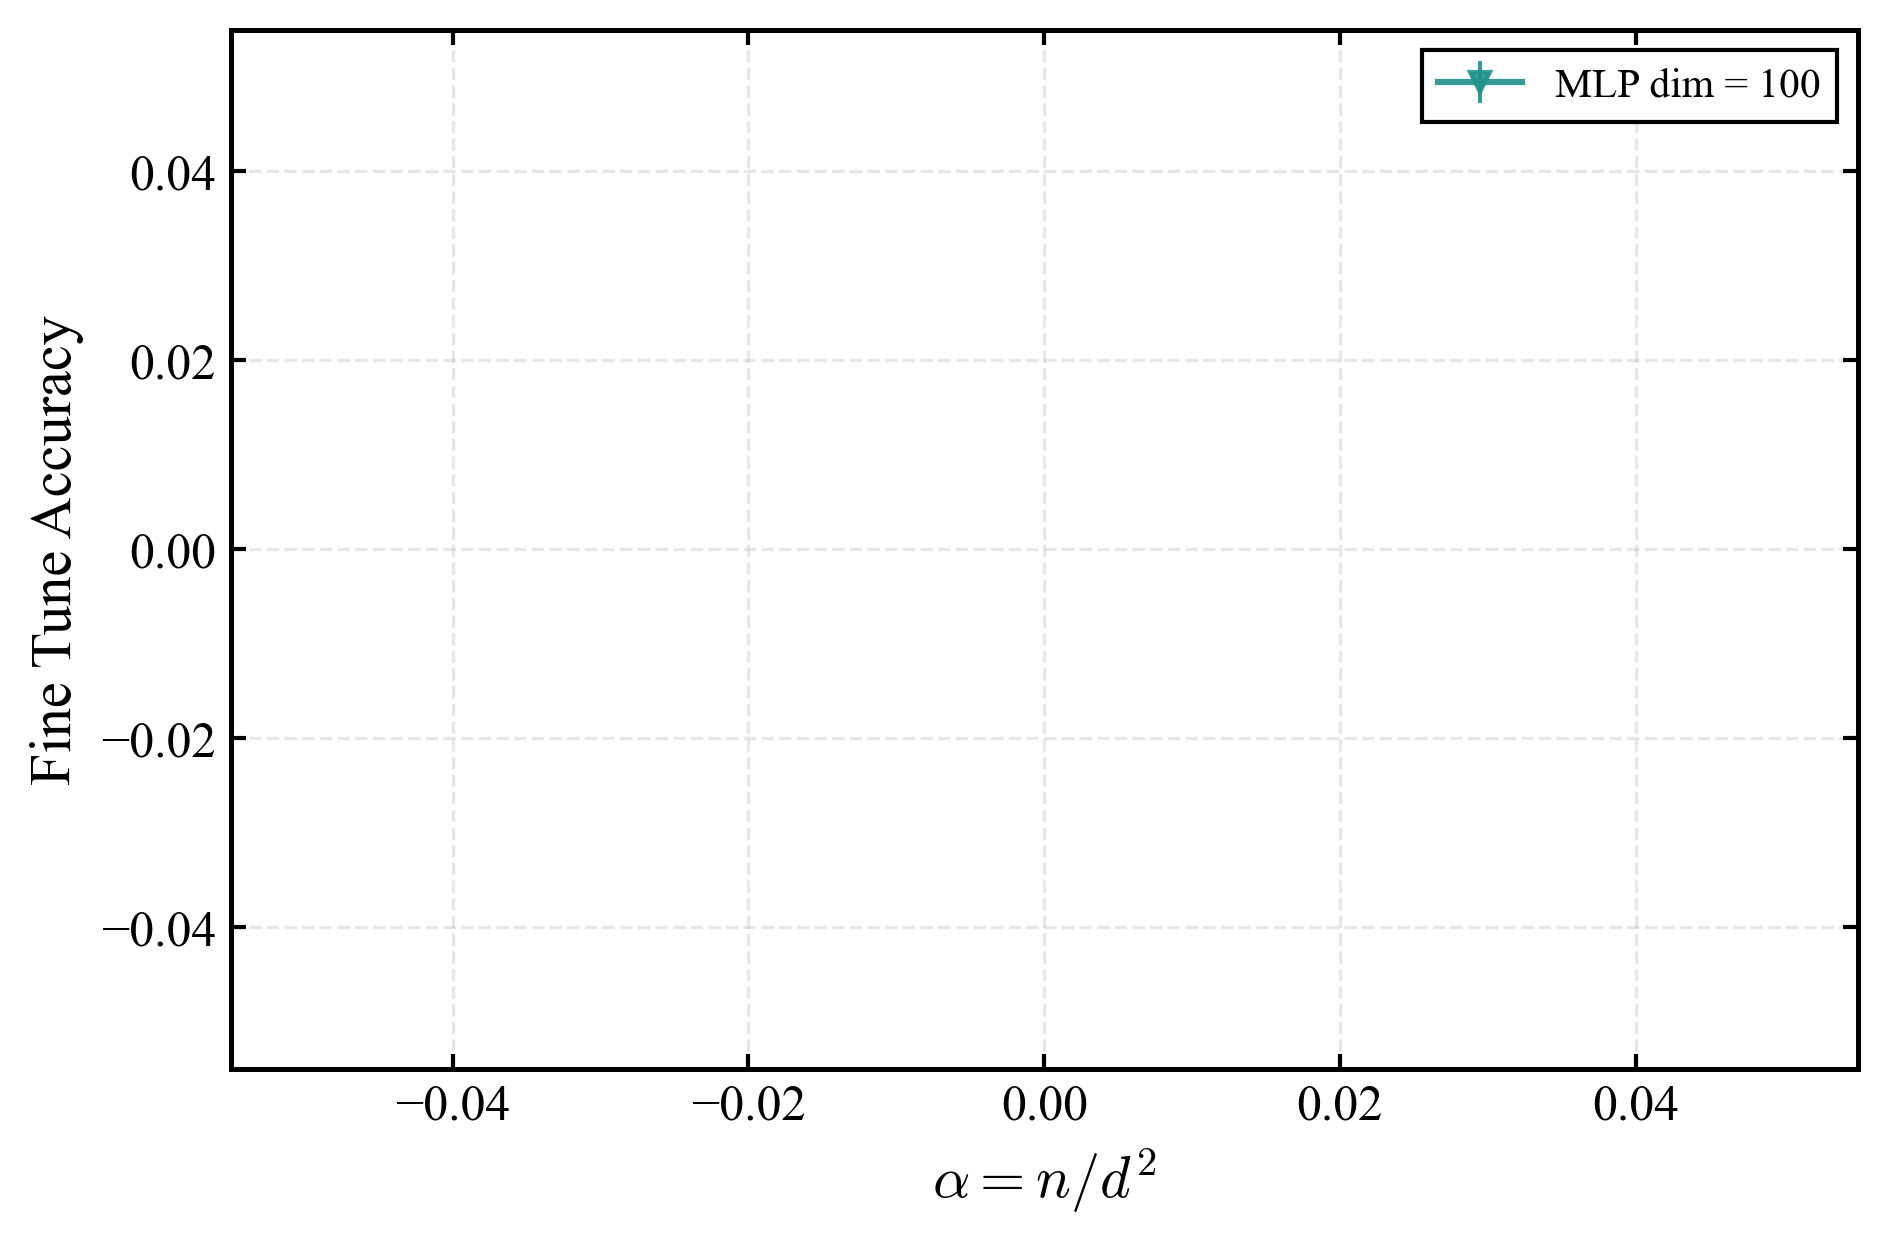

✅ Saved plot: ../results/run_20251218_1108/plots/test_accuracy_vs_alpha_run20251218_1108.png


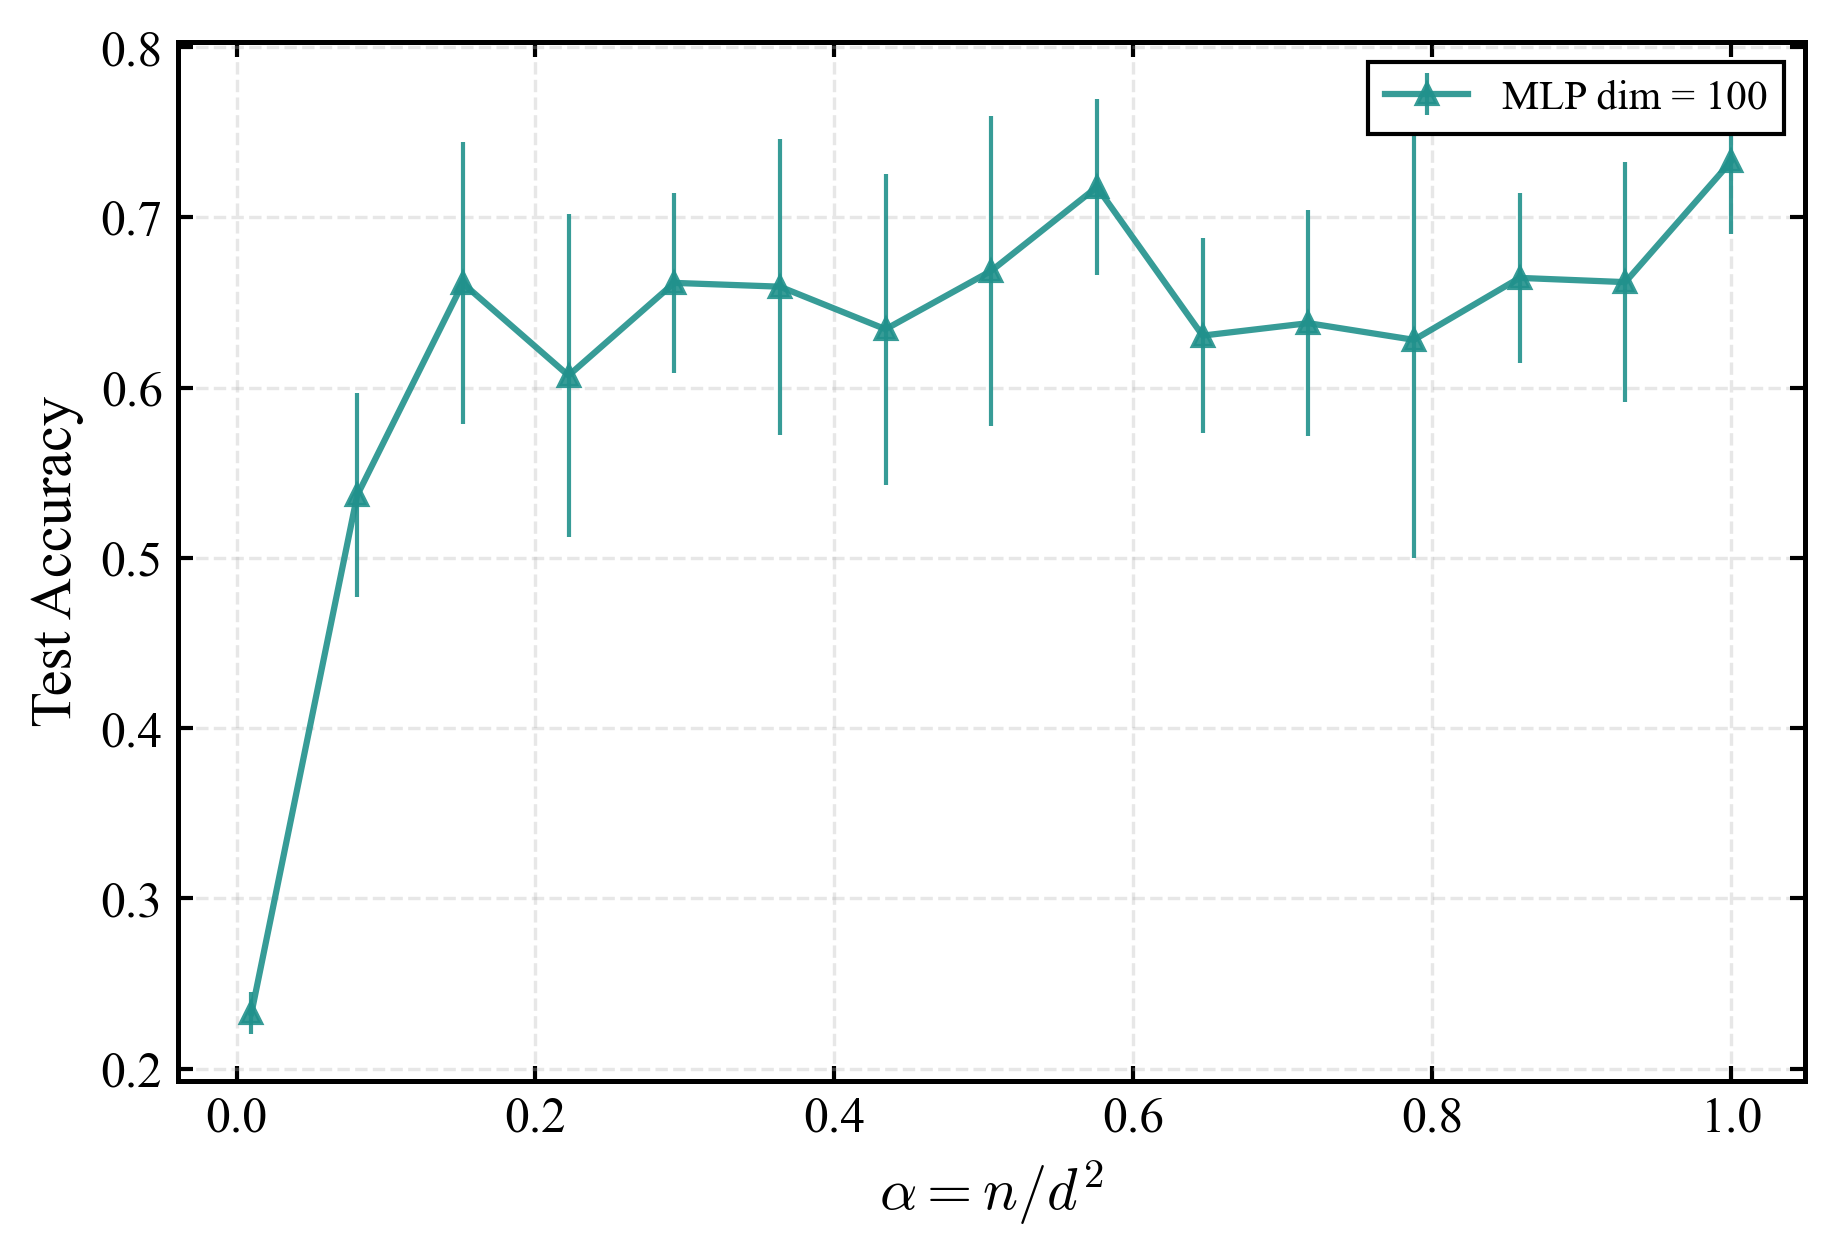

In [128]:
# --- Read the CSV file ---
df = pd.read_csv(base_path)
print(f"✅ Summary loaded ({len(df)} rows) from {base_path}")

# --- Quick preview ---
display(df.head())

# --- 2. Load Data ---
# Ensure base_path, run_id, and plot_path are defined
# df = pd.read_csv(base_path)
print(f"✅ Summary loaded ({len(df)} rows)")

# --- 3. Setup Colors for MLP Dimensions ---
# We map each unique MLP_dim to a specific color so it stays consistent across all plots
unique_dims = sorted(df["MLP_dim"].unique())
palette = sns.color_palette("viridis", n_colors=len(unique_dims))
color_map = {dim: color for dim, color in zip(unique_dims, palette)}

# --- 4. The Generic Plotting Function ---
def plot_metric_by_mlp(df, y_col, y_err_col, ylabel, filename, marker='o', log_y=False):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    
    # Loop through dimensions
    for mlp_dim in unique_dims:
        subset = df[df["MLP_dim"] == mlp_dim].sort_values("alpha")
        
        if subset.empty:
            continue
            
        ax.errorbar(
            subset["alpha"],
            subset[y_col],
            yerr=subset.get(y_err_col, 0),
            marker=marker,
            label=f"MLP dim = {mlp_dim}",
            color=color_map[mlp_dim], # Consistent color
            capsize=0,
            elinewidth=1.0,
            alpha=0.9
        )

    # Labels and Formatting
    ax.set_xlabel(r"$\alpha = n/d^2$")
    ax.set_ylabel(ylabel)
    
    if log_y:
        ax.set_yscale('log')

    # --- BOX STYLE ---
    ax.set_axisbelow(True)
    ax.tick_params(direction='in', top=True, right=True, which='both', width=1.0)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)

    # Legend
    ax.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1.0, loc='best')

    # Save
    save_full = os.path.join(plot_path, filename)
    plt.savefig(save_full)
    print(f"✅ Saved plot: {save_full}")
    plt.show()

# --- 5. Generate All 7 Plots ---

# 1. Label Error
plot_metric_by_mlp(
    df, "label_err_mean", "label_err_std", 
    "Test Error", f"label_error_vs_alpha_run{run_id}.png", 
    marker='o'
)

# 2. Train Loss
plot_metric_by_mlp(
    df, "train_data_mean", "train_total_std", 
    "Train Loss", f"train_data_vs_alpha_run{run_id}.png", 
    marker='s' # Square
)

# 3. Train Accuracy
plot_metric_by_mlp(
    df, "acc_train_mean", "acc_train_std", 
    "Train Accuracy", f"train_accuracy_vs_alpha_run{run_id}.png", 
    marker='v' # Down triangle
)

# 4. Fine Tune Accuracy
plot_metric_by_mlp(
    df, "acc_fine_tune_mean", "acc_fine_tune_std", 
    "Fine Tune Accuracy", f"fine_tune_accuracy_vs_alpha_run{run_id}.png", 
    marker='v'
)

# 5. Test Accuracy
plot_metric_by_mlp(
    df, "acc_test_mean", "acc_test_std", 
    "Test Accuracy", f"test_accuracy_vs_alpha_run{run_id}.png", 
    marker='^' # Up triangle
)

✅ Saved plot: ../results/run_20251218_1108/plots/rank_Q_vs_K_before_run20251218_1108.png


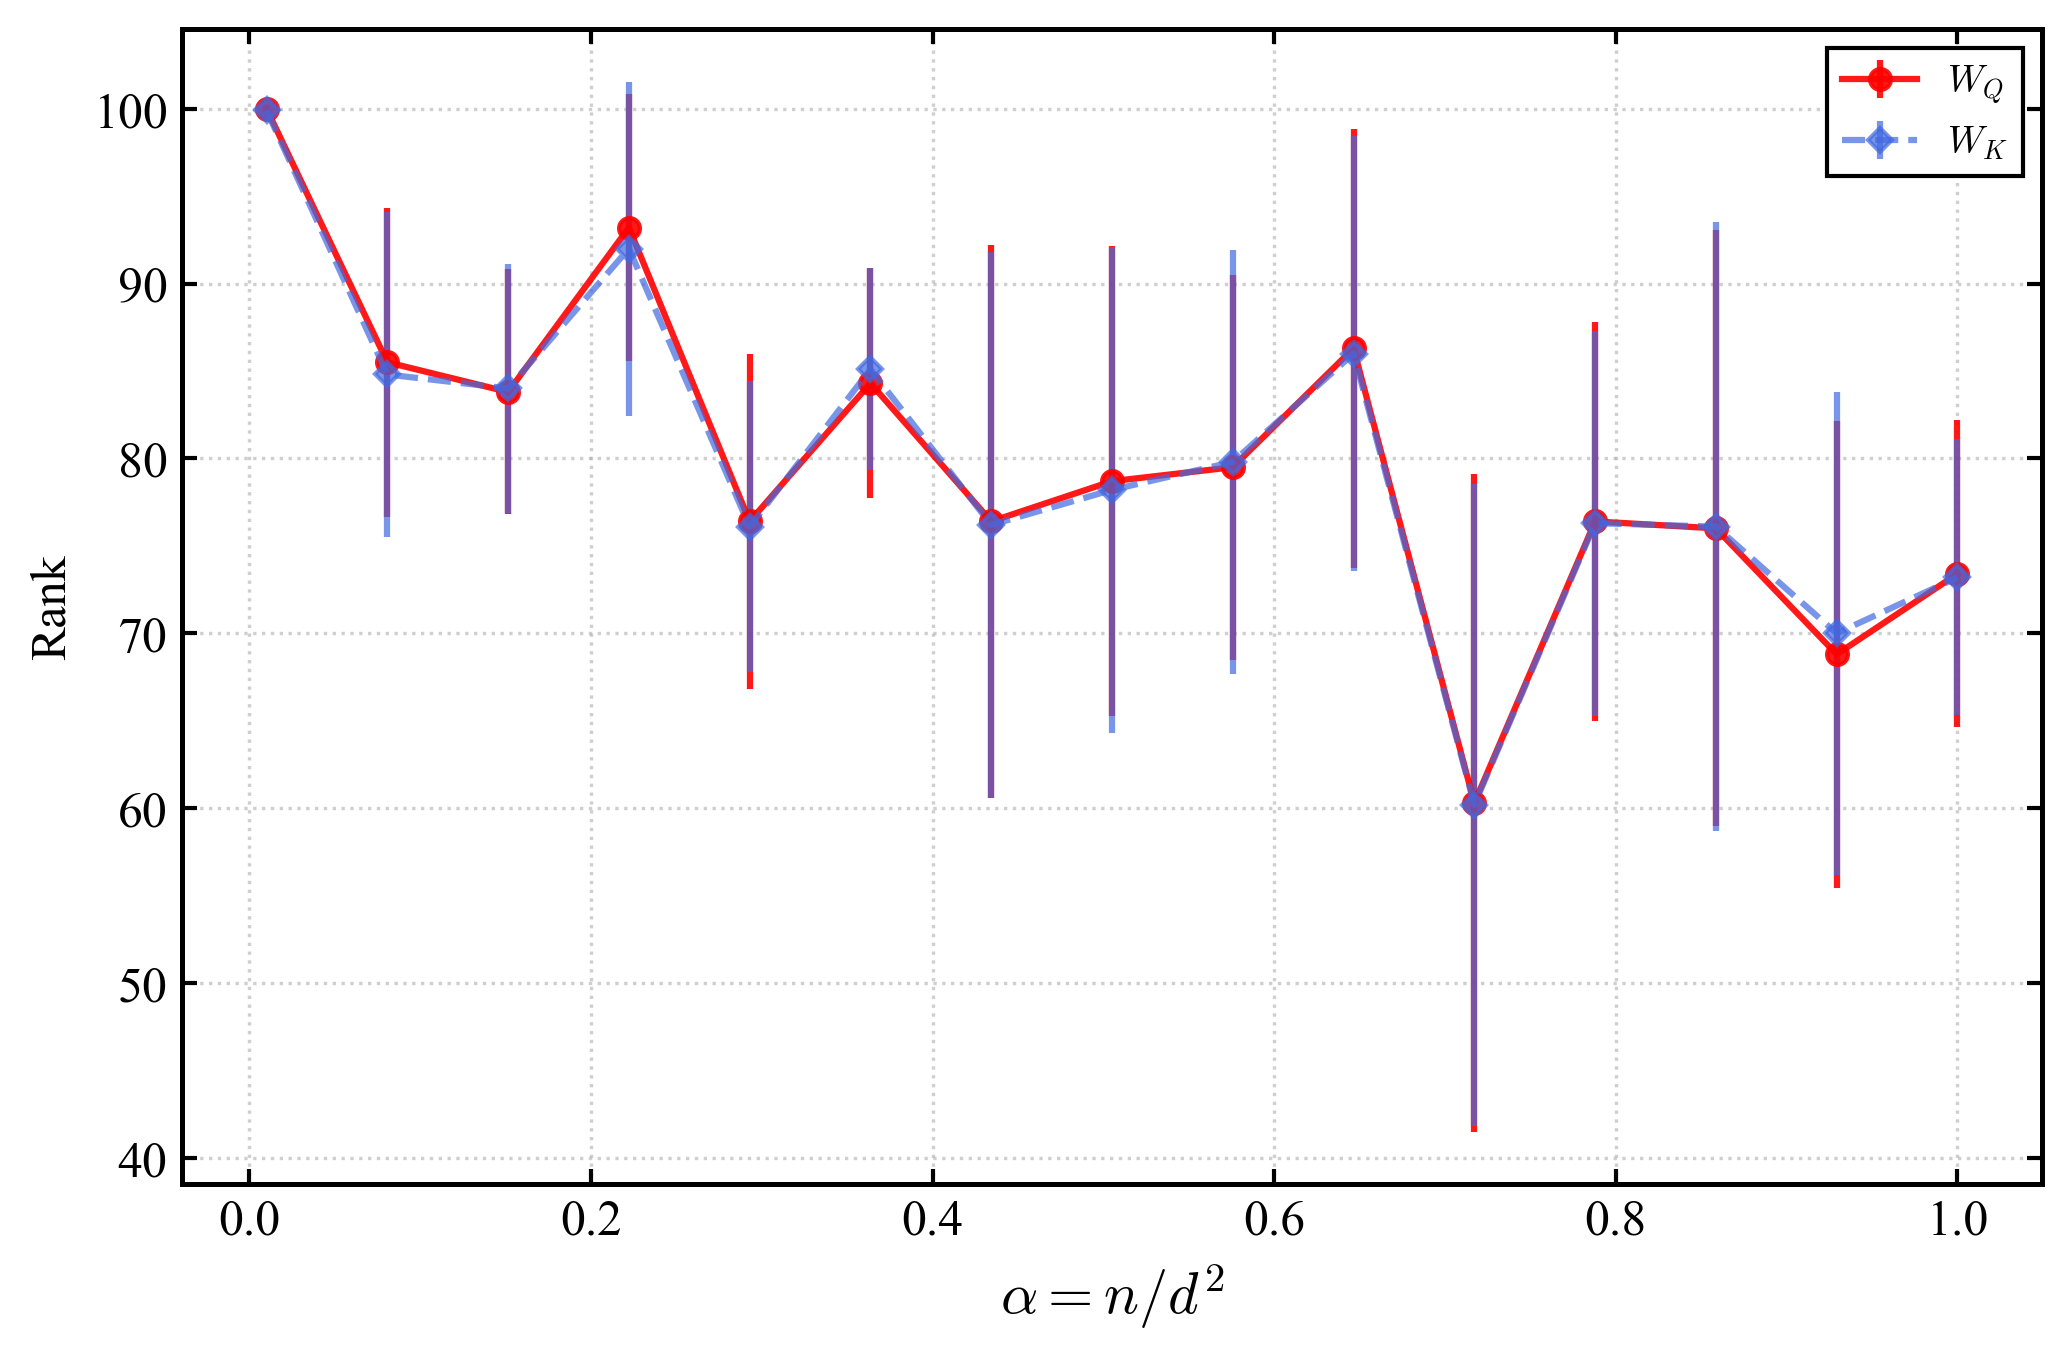

✅ Saved plot: ../results/run_20251218_1108/plots/rank_Q_vs_K_after_run20251218_1108.png


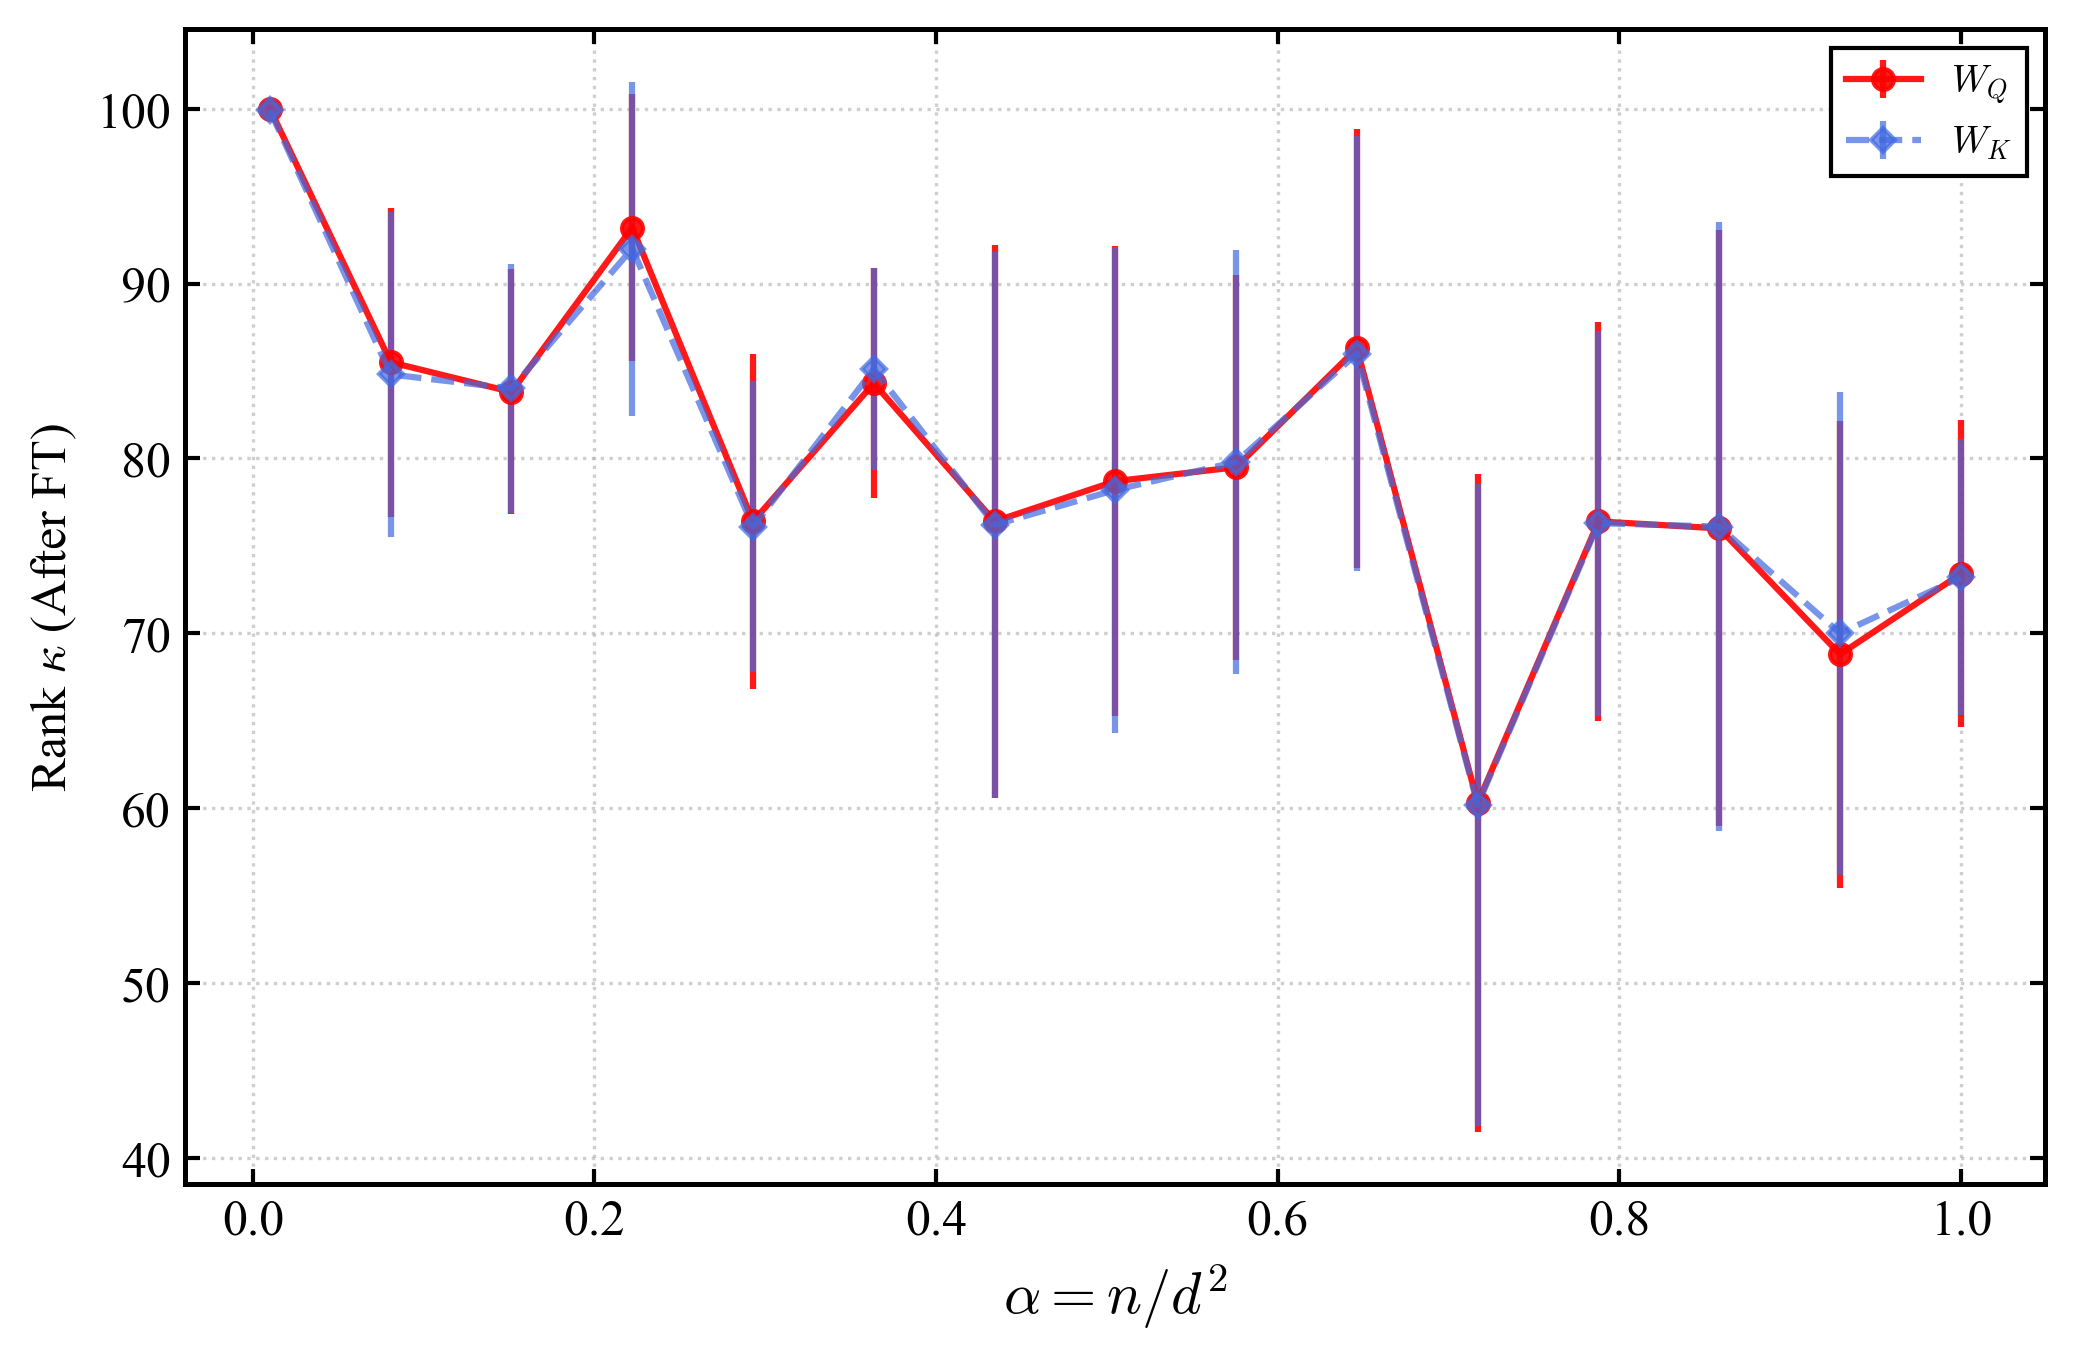

In [129]:
# --- 2. Setup Colors ---
unique_dims = sorted(df["MLP_dim"].unique())
palette = sns.color_palette("viridis", n_colors=len(unique_dims))
color_map = {dim: color for dim, color in zip(unique_dims, palette)}

# --- 3. The Superposed Plotting Function ---
def plot_ranks_superposed(df, q_col, q_err, k_col, k_err, ylabel, filename):
    fig, ax = plt.subplots(figsize=(8, 5)) # Un peu plus large pour la légende
    
    # Loop through dimensions
    for mlp_dim in unique_dims:
        subset = df[df["MLP_dim"] == mlp_dim].sort_values("alpha")
        
        if subset.empty:
            continue
            
        c = color_map[mlp_dim]
        
        # --- Plot Q (Solid Line, Circle Marker) ---
        ax.errorbar(
            subset["alpha"],
            subset[q_col],
            yerr=subset.get(q_err, 0),
            marker='o',
            linestyle='-', # Solid
            label=fr"$W_Q$",
            color="red",
            capsize=0,
            elinewidth=1.5,
            alpha=0.9
        )
        
        # --- Plot K (Dashed Line, Diamond Marker) ---
        ax.errorbar(
            subset["alpha"],
            subset[k_col],
            yerr=subset.get(k_err, 0),
            marker='D', 
            markersize=4,
            linestyle='--', # Dashed
            label=fr"$W_K$",
            color="royalblue",
            capsize=0,
            elinewidth=1.5,
            alpha=0.7 # Légèrement plus transparent pour distinguer si superposition parfaite
        )

    # Labels and Formatting
    ax.set_xlabel(r"$\alpha = n/d^2$")
    ax.set_ylabel(ylabel, fontsize=12)
    
    # --- BOX STYLE ---
    ax.set_axisbelow(True)
    ax.grid(True, linestyle=':', alpha=0.6) # Ajout d'une grille légère pour lire les rangs
    ax.tick_params(direction='in', top=True, right=True, which='both', width=1.0)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)

    # Legend (Optimized)
    # On met la légende en dehors si trop chargée, ou "best"
    ax.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1.0, loc='best', fontsize=9)

    # Save
    save_full = os.path.join(plot_path, filename)
    plt.savefig(save_full, dpi=300, bbox_inches='tight')
    print(f"✅ Saved plot: {save_full}")
    plt.show()

# --- 4. Generate the Rank Plots ---

# 1. Ranks Before Fine-Tuning (Comparison Q vs K)
# Vérifie que les colonnes existent bien dans ton CSV (généré par le script précédent)
if "rank_Q_before_mean" in df.columns:
    plot_ranks_superposed(
        df, 
        q_col="rank_Q_before_mean", q_err="rank_Q_before_std",
        k_col="rank_K_before_mean", k_err="rank_K_before_std",
        ylabel=r"Rank", 
        filename=f"rank_Q_vs_K_before_run{run_id}.png"
    )

# 2. Ranks After Fine-Tuning (Comparison Q vs K) - C'est souvent le plus intéressant
if "rank_Q_after_mean" in df.columns:
    plot_ranks_superposed(
        df, 
        q_col="rank_Q_after_mean", q_err="rank_Q_after_std",
        k_col="rank_K_after_mean", k_err="rank_K_after_std",
        ylabel=r"Rank $\kappa$ (After FT)", 
        filename=f"rank_Q_vs_K_after_run{run_id}.png"
    )

# --- 5. (Optionnel) Plot standard pour les autres métriques ---
# Tu peux garder ta fonction 'plot_metric_by_mlp' originale ici pour tracer
# label_err, accuracy, etc., comme dans ton snippet précédent.

## 3. Results visualisation

✅ Found 15 heavy_data files in ../results/run_20251218_1108/

Processing: heavy_data_0.pkl...
   📊 Plot saved: ../results/run_20251218_1108/plots/SVD_Compare_heavy_data_0.png

Processing: heavy_data_1.pkl...
   📊 Plot saved: ../results/run_20251218_1108/plots/SVD_Compare_heavy_data_1.png

Processing: heavy_data_10.pkl...
   📊 Plot saved: ../results/run_20251218_1108/plots/SVD_Compare_heavy_data_10.png

Processing: heavy_data_11.pkl...
   📊 Plot saved: ../results/run_20251218_1108/plots/SVD_Compare_heavy_data_11.png

Processing: heavy_data_12.pkl...
   📊 Plot saved: ../results/run_20251218_1108/plots/SVD_Compare_heavy_data_12.png

Processing: heavy_data_13.pkl...
   📊 Plot saved: ../results/run_20251218_1108/plots/SVD_Compare_heavy_data_13.png

Processing: heavy_data_14.pkl...
   📊 Plot saved: ../results/run_20251218_1108/plots/SVD_Compare_heavy_data_14.png

Processing: heavy_data_2.pkl...
   📊 Plot saved: ../results/run_20251218_1108/plots/SVD_Compare_heavy_data_2.png

Processing: heav

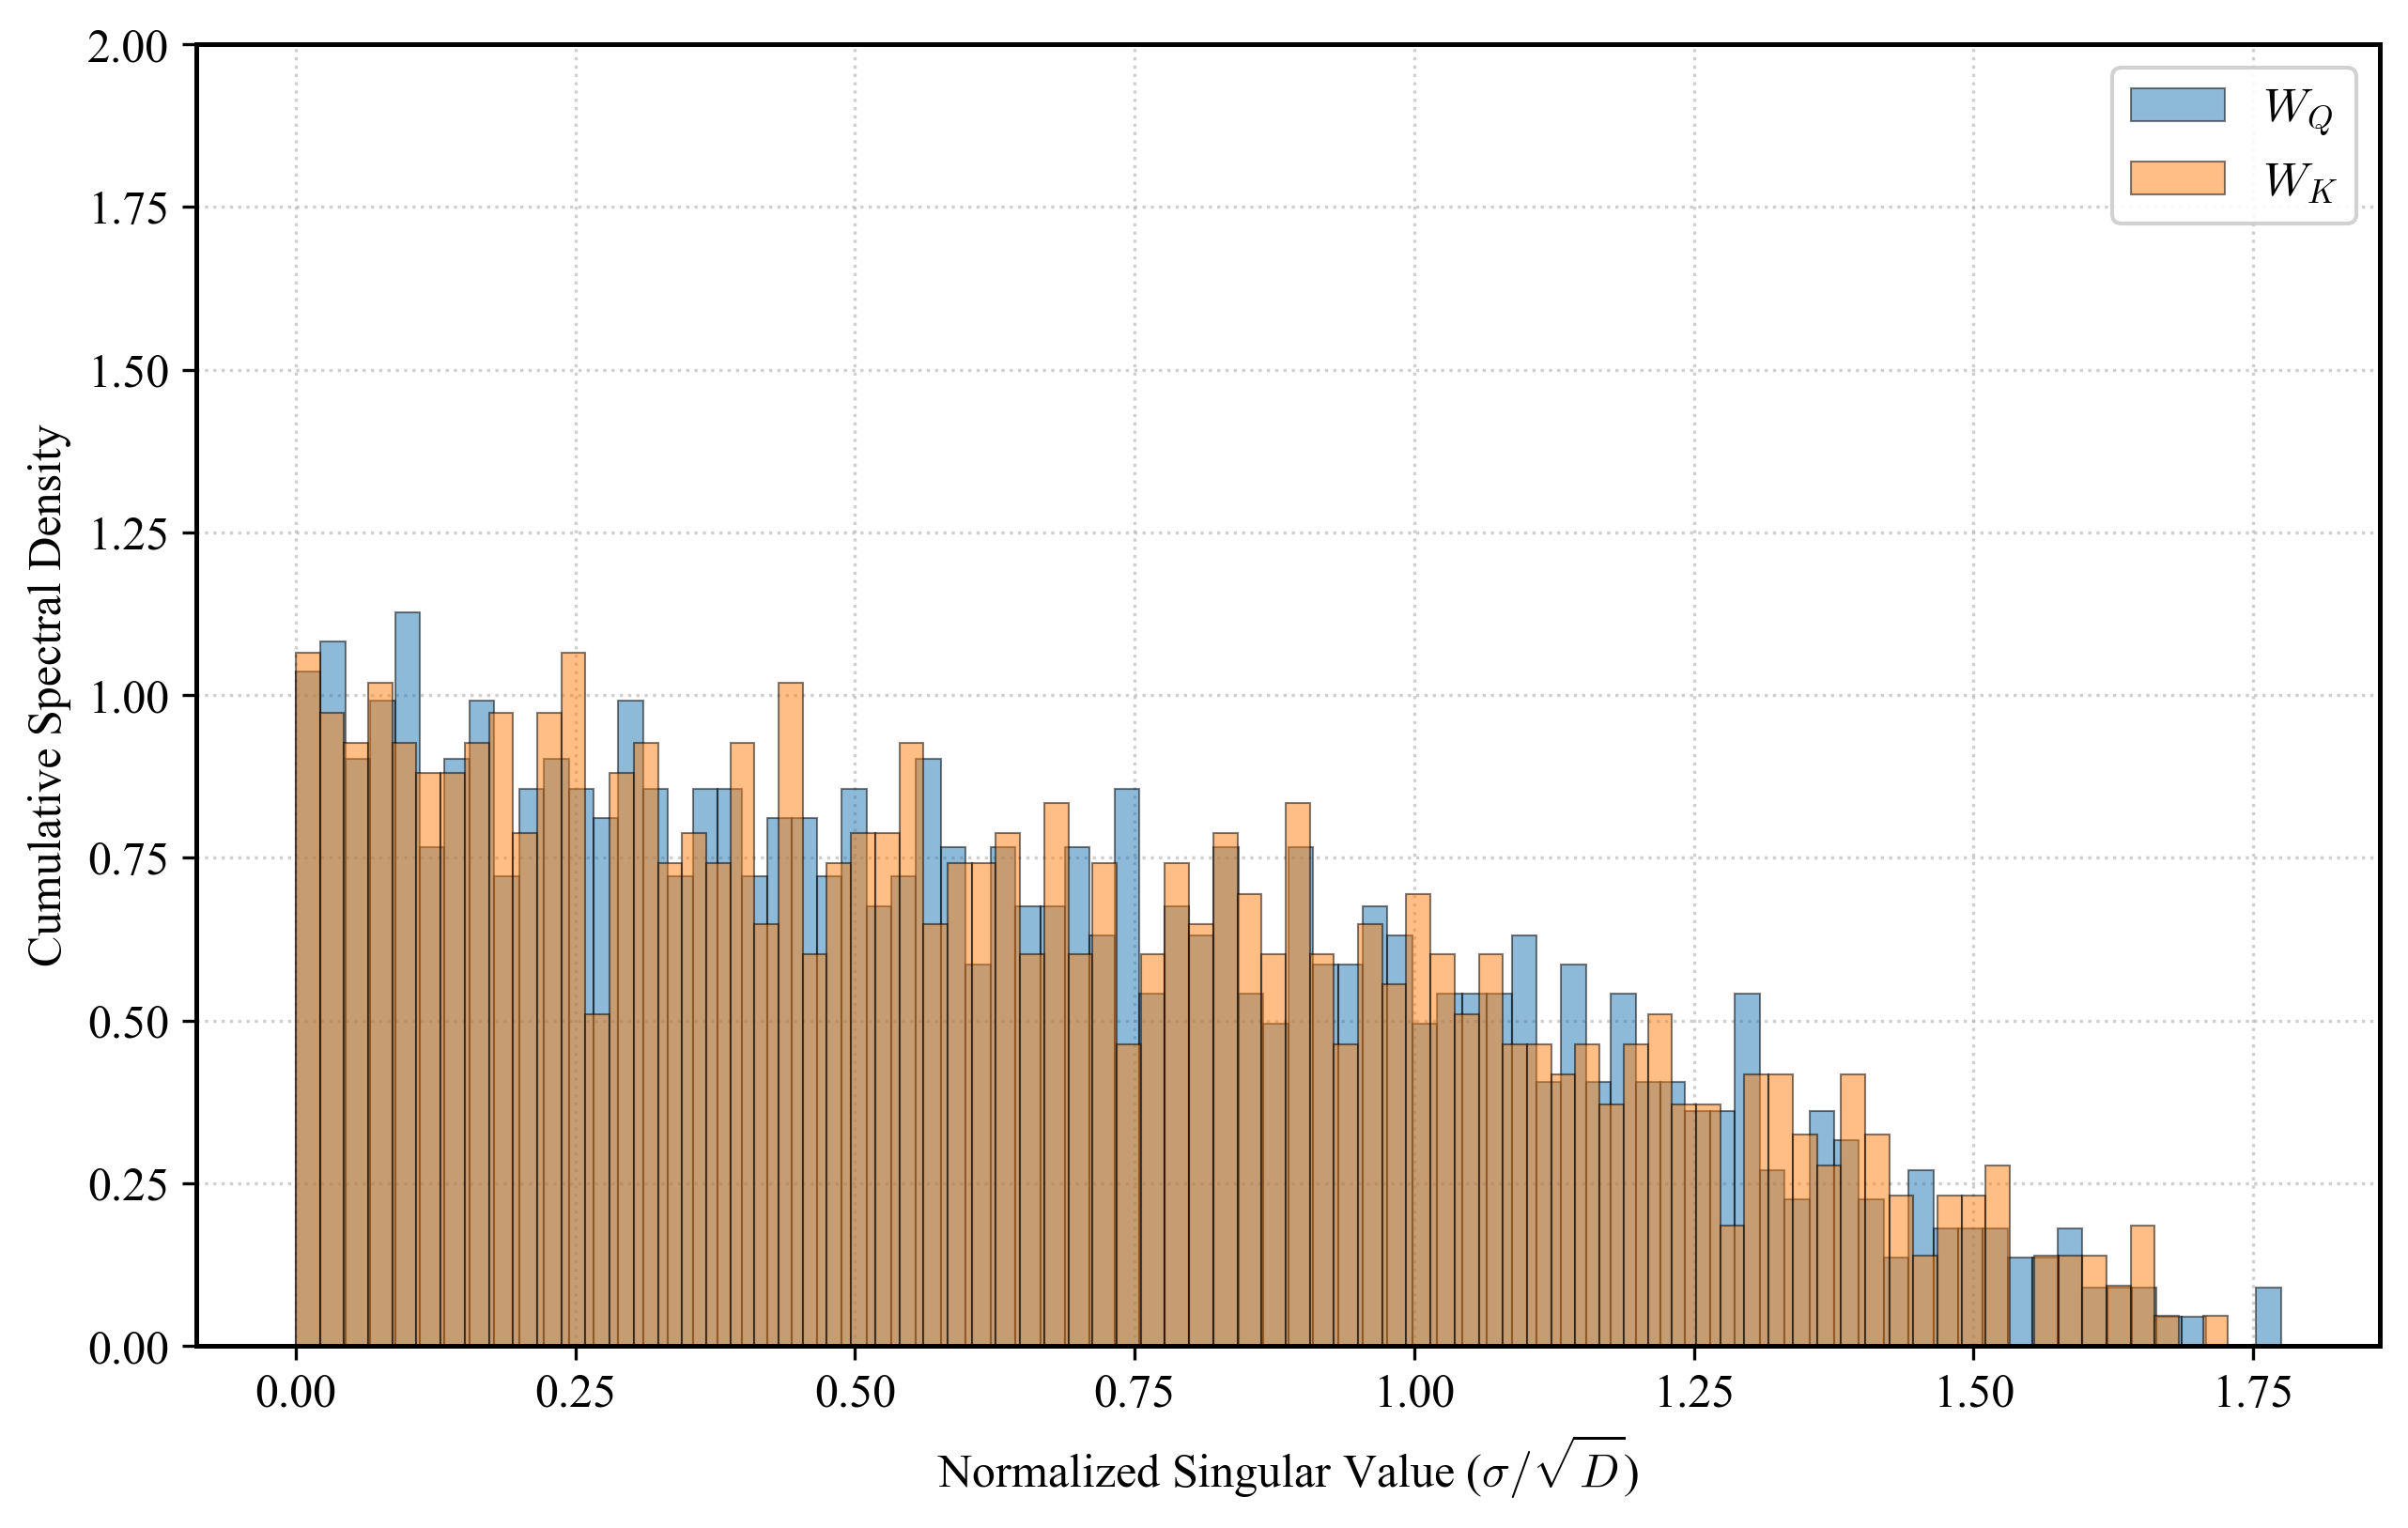

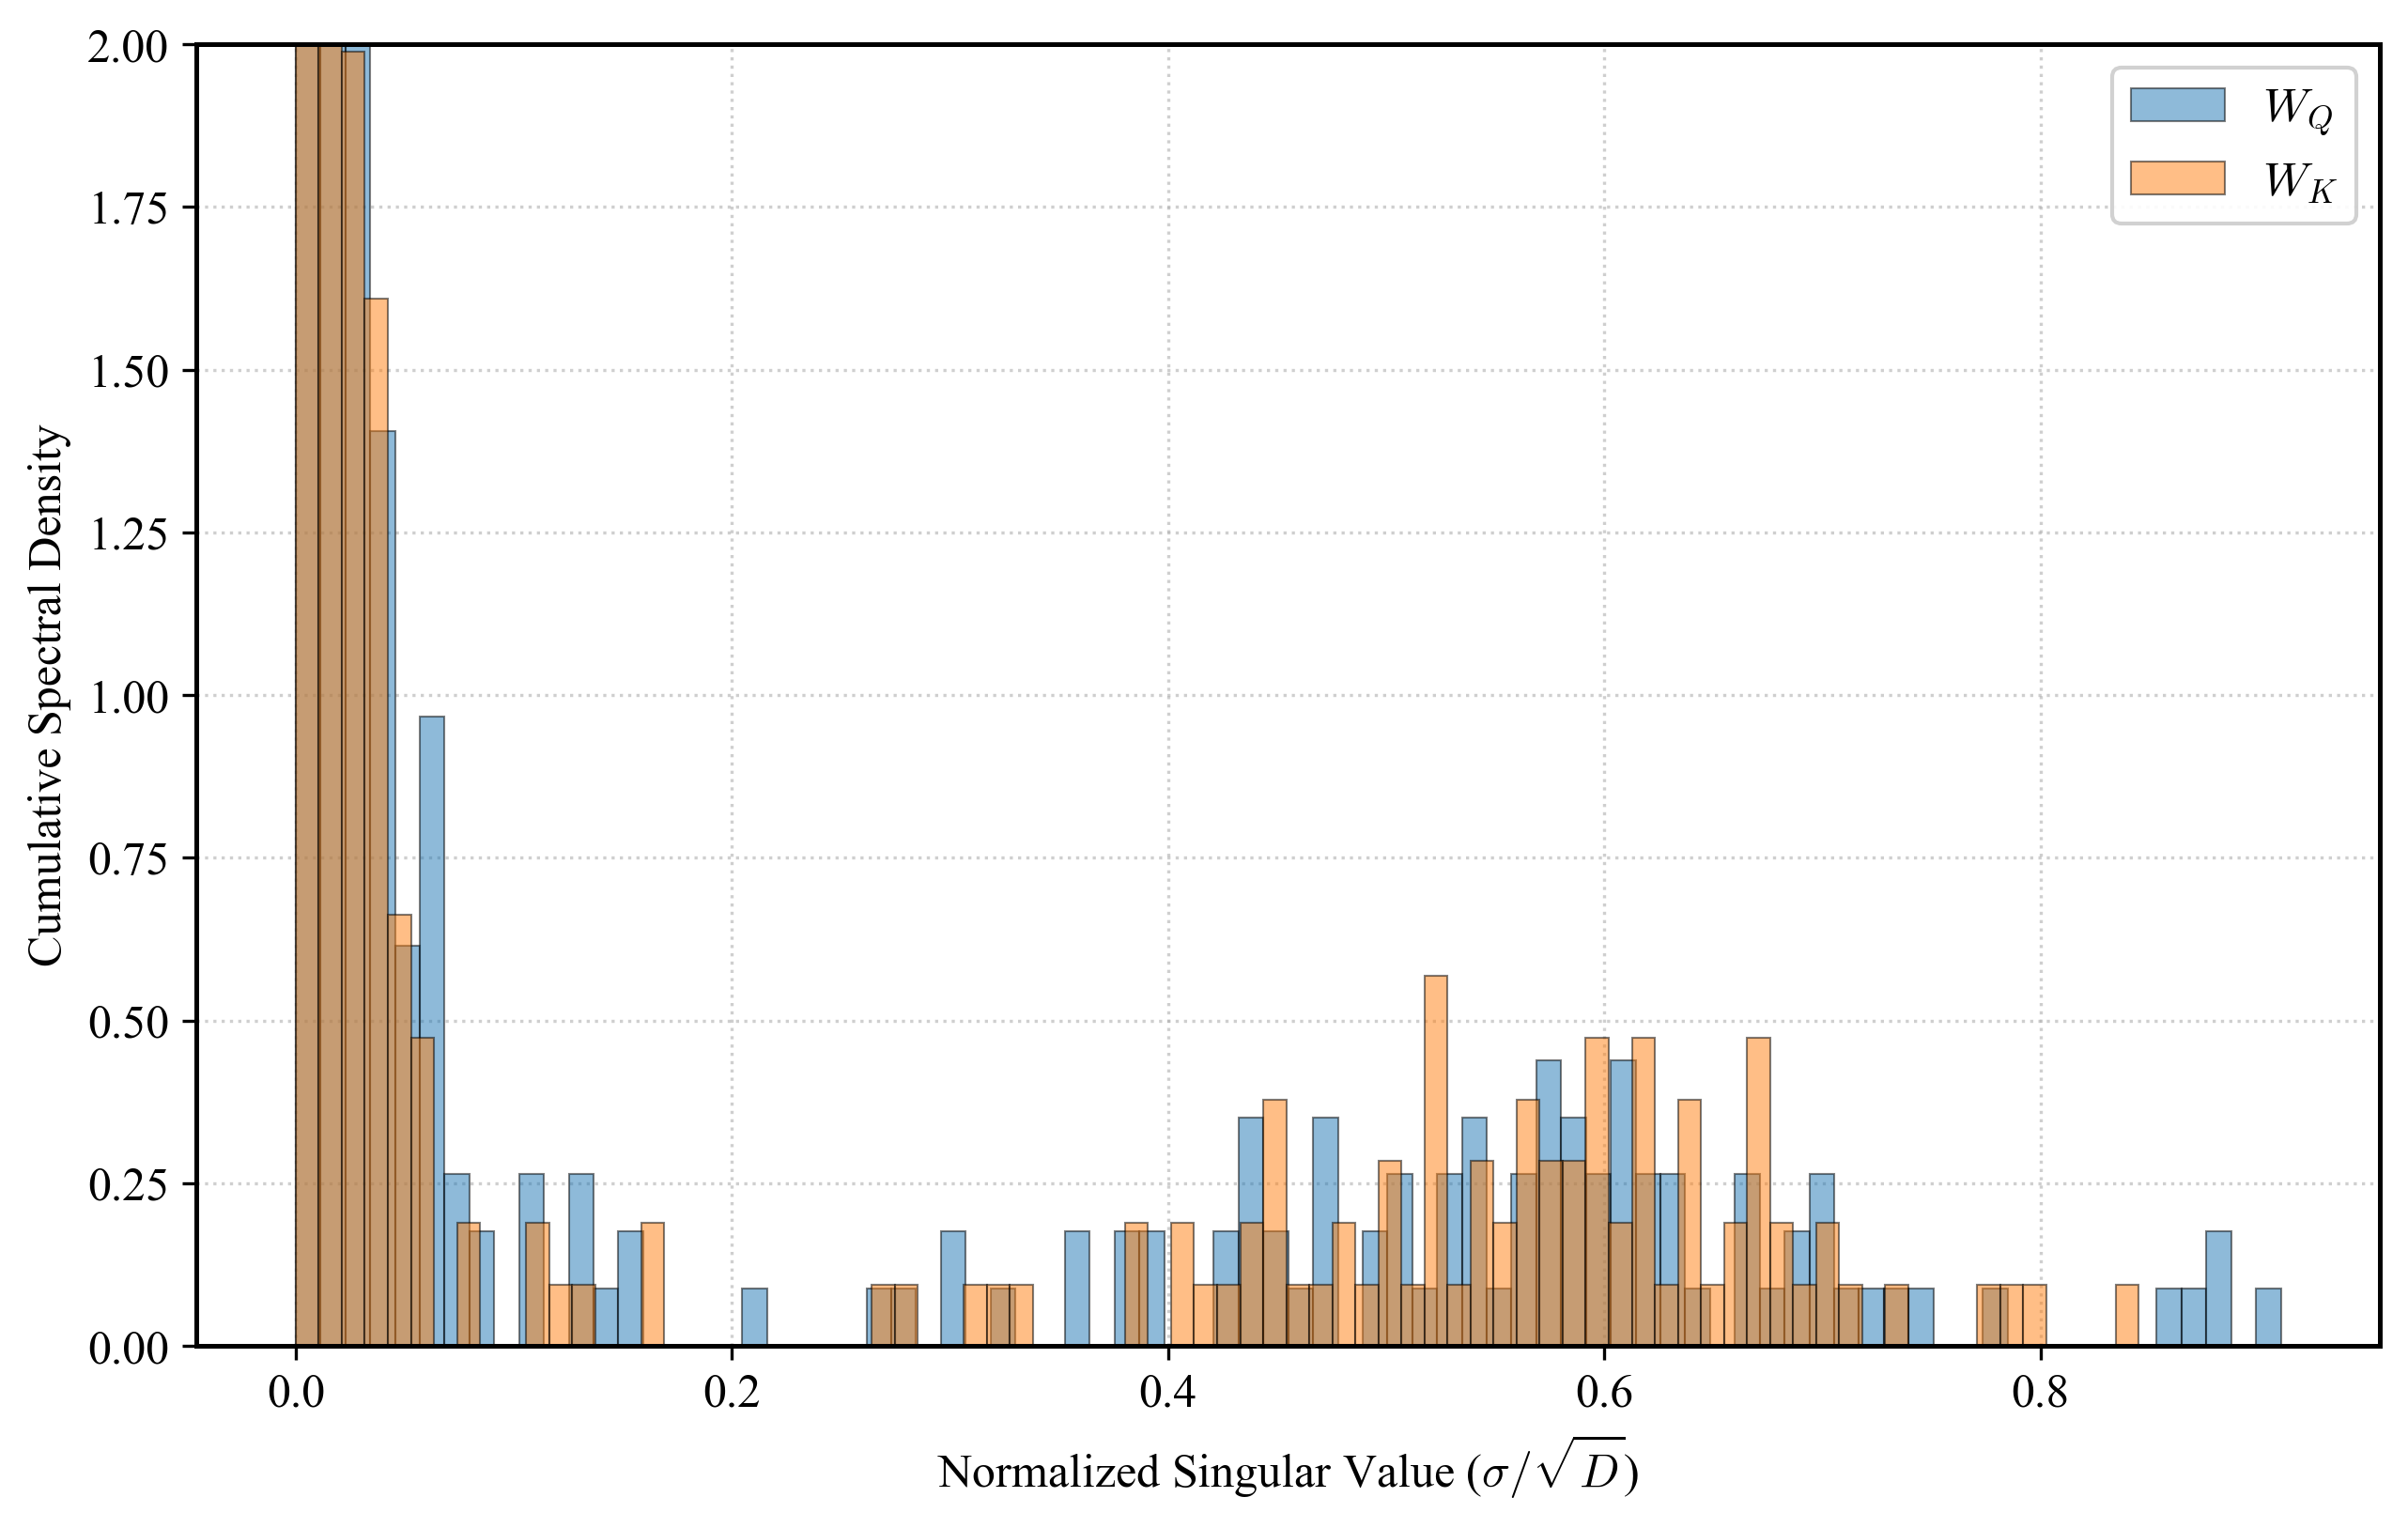

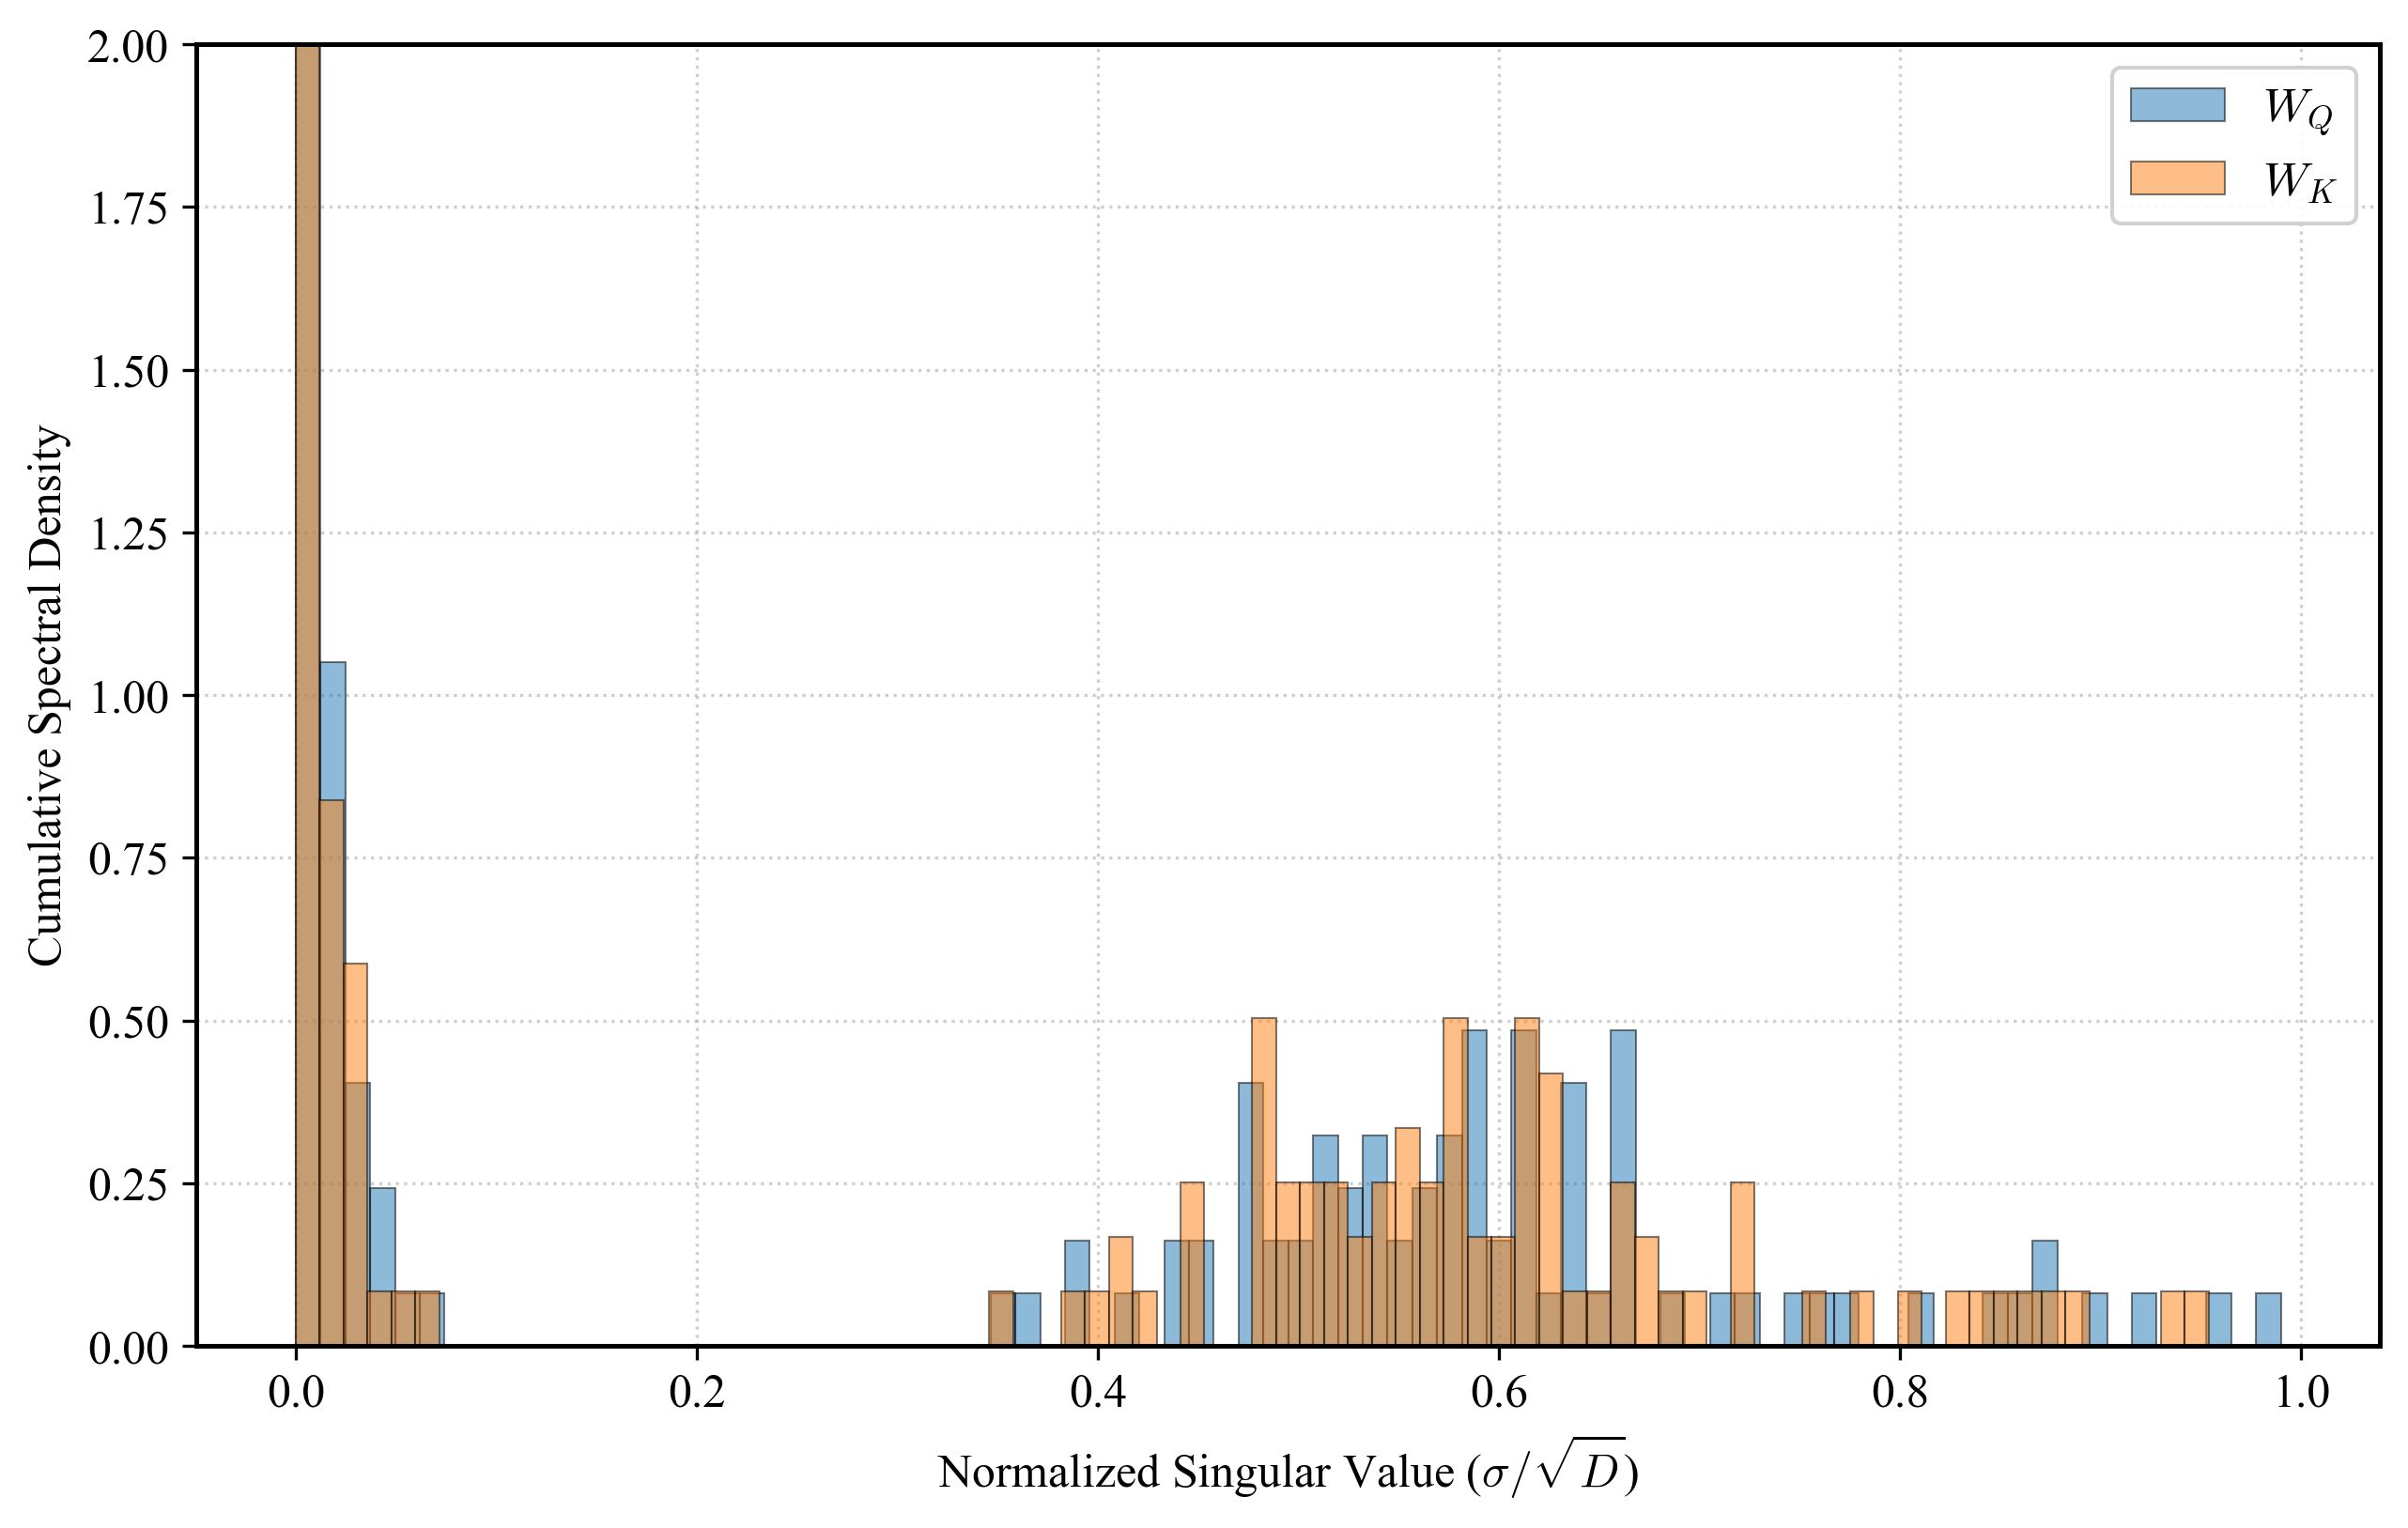

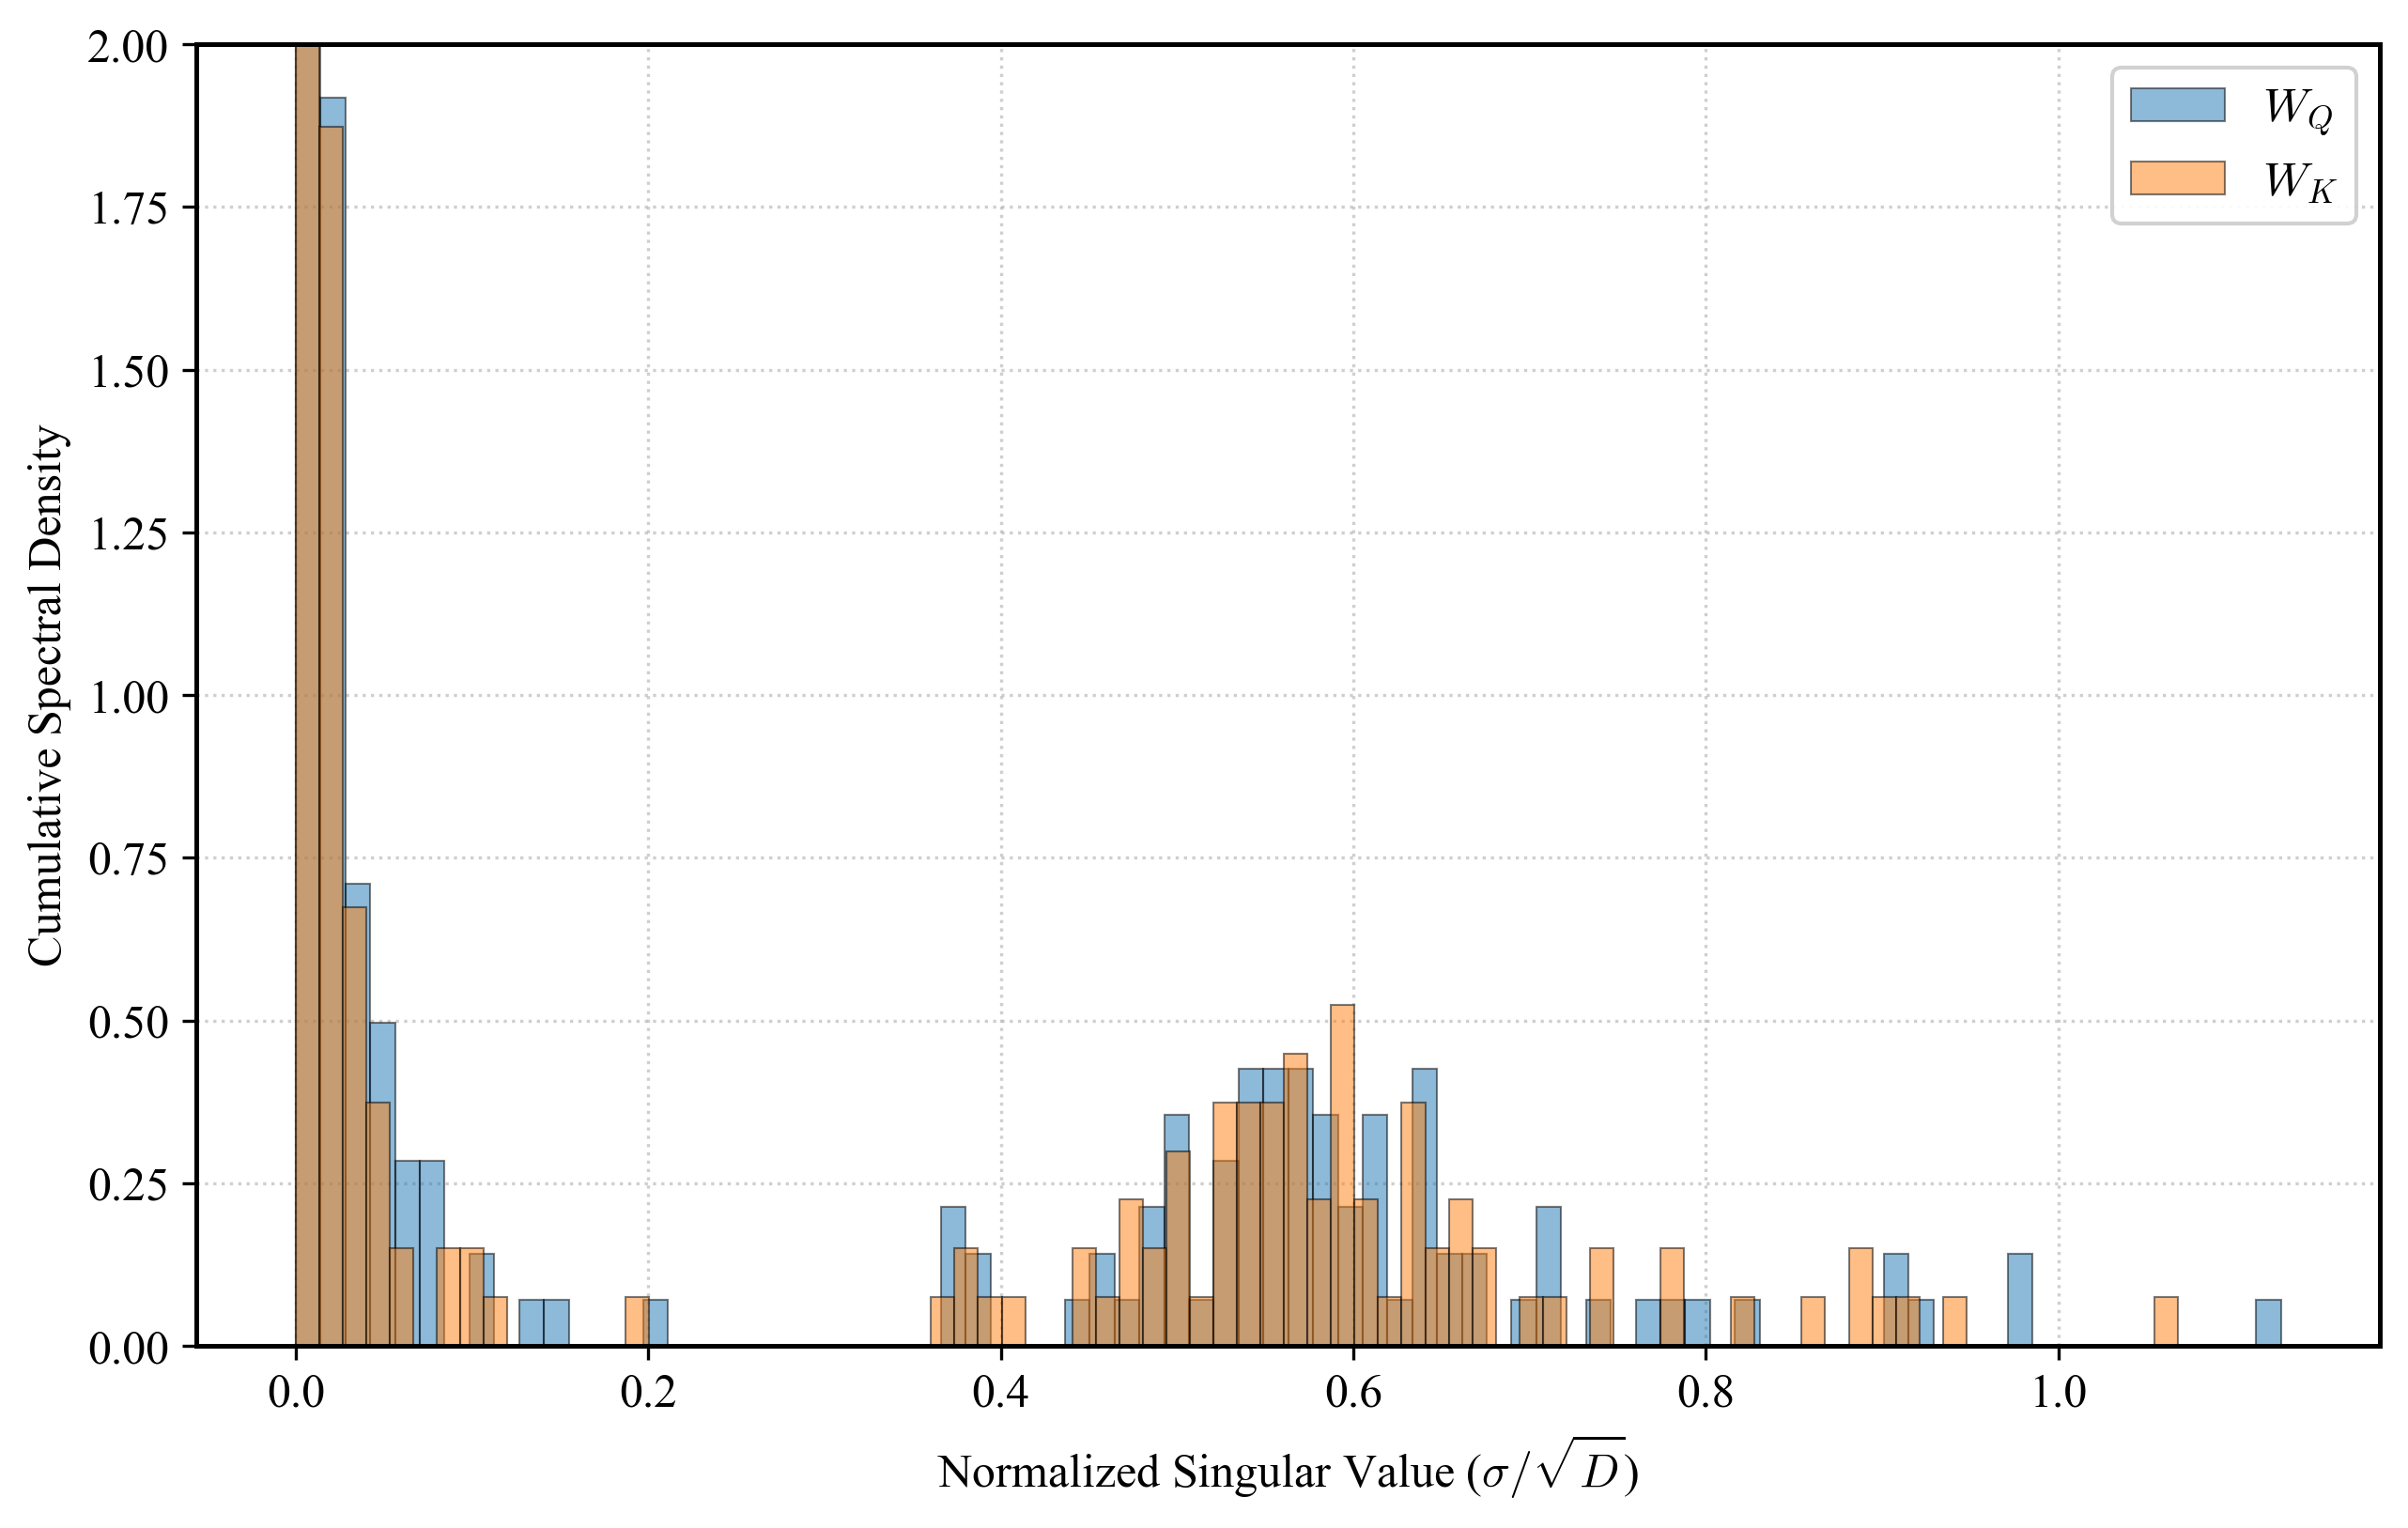

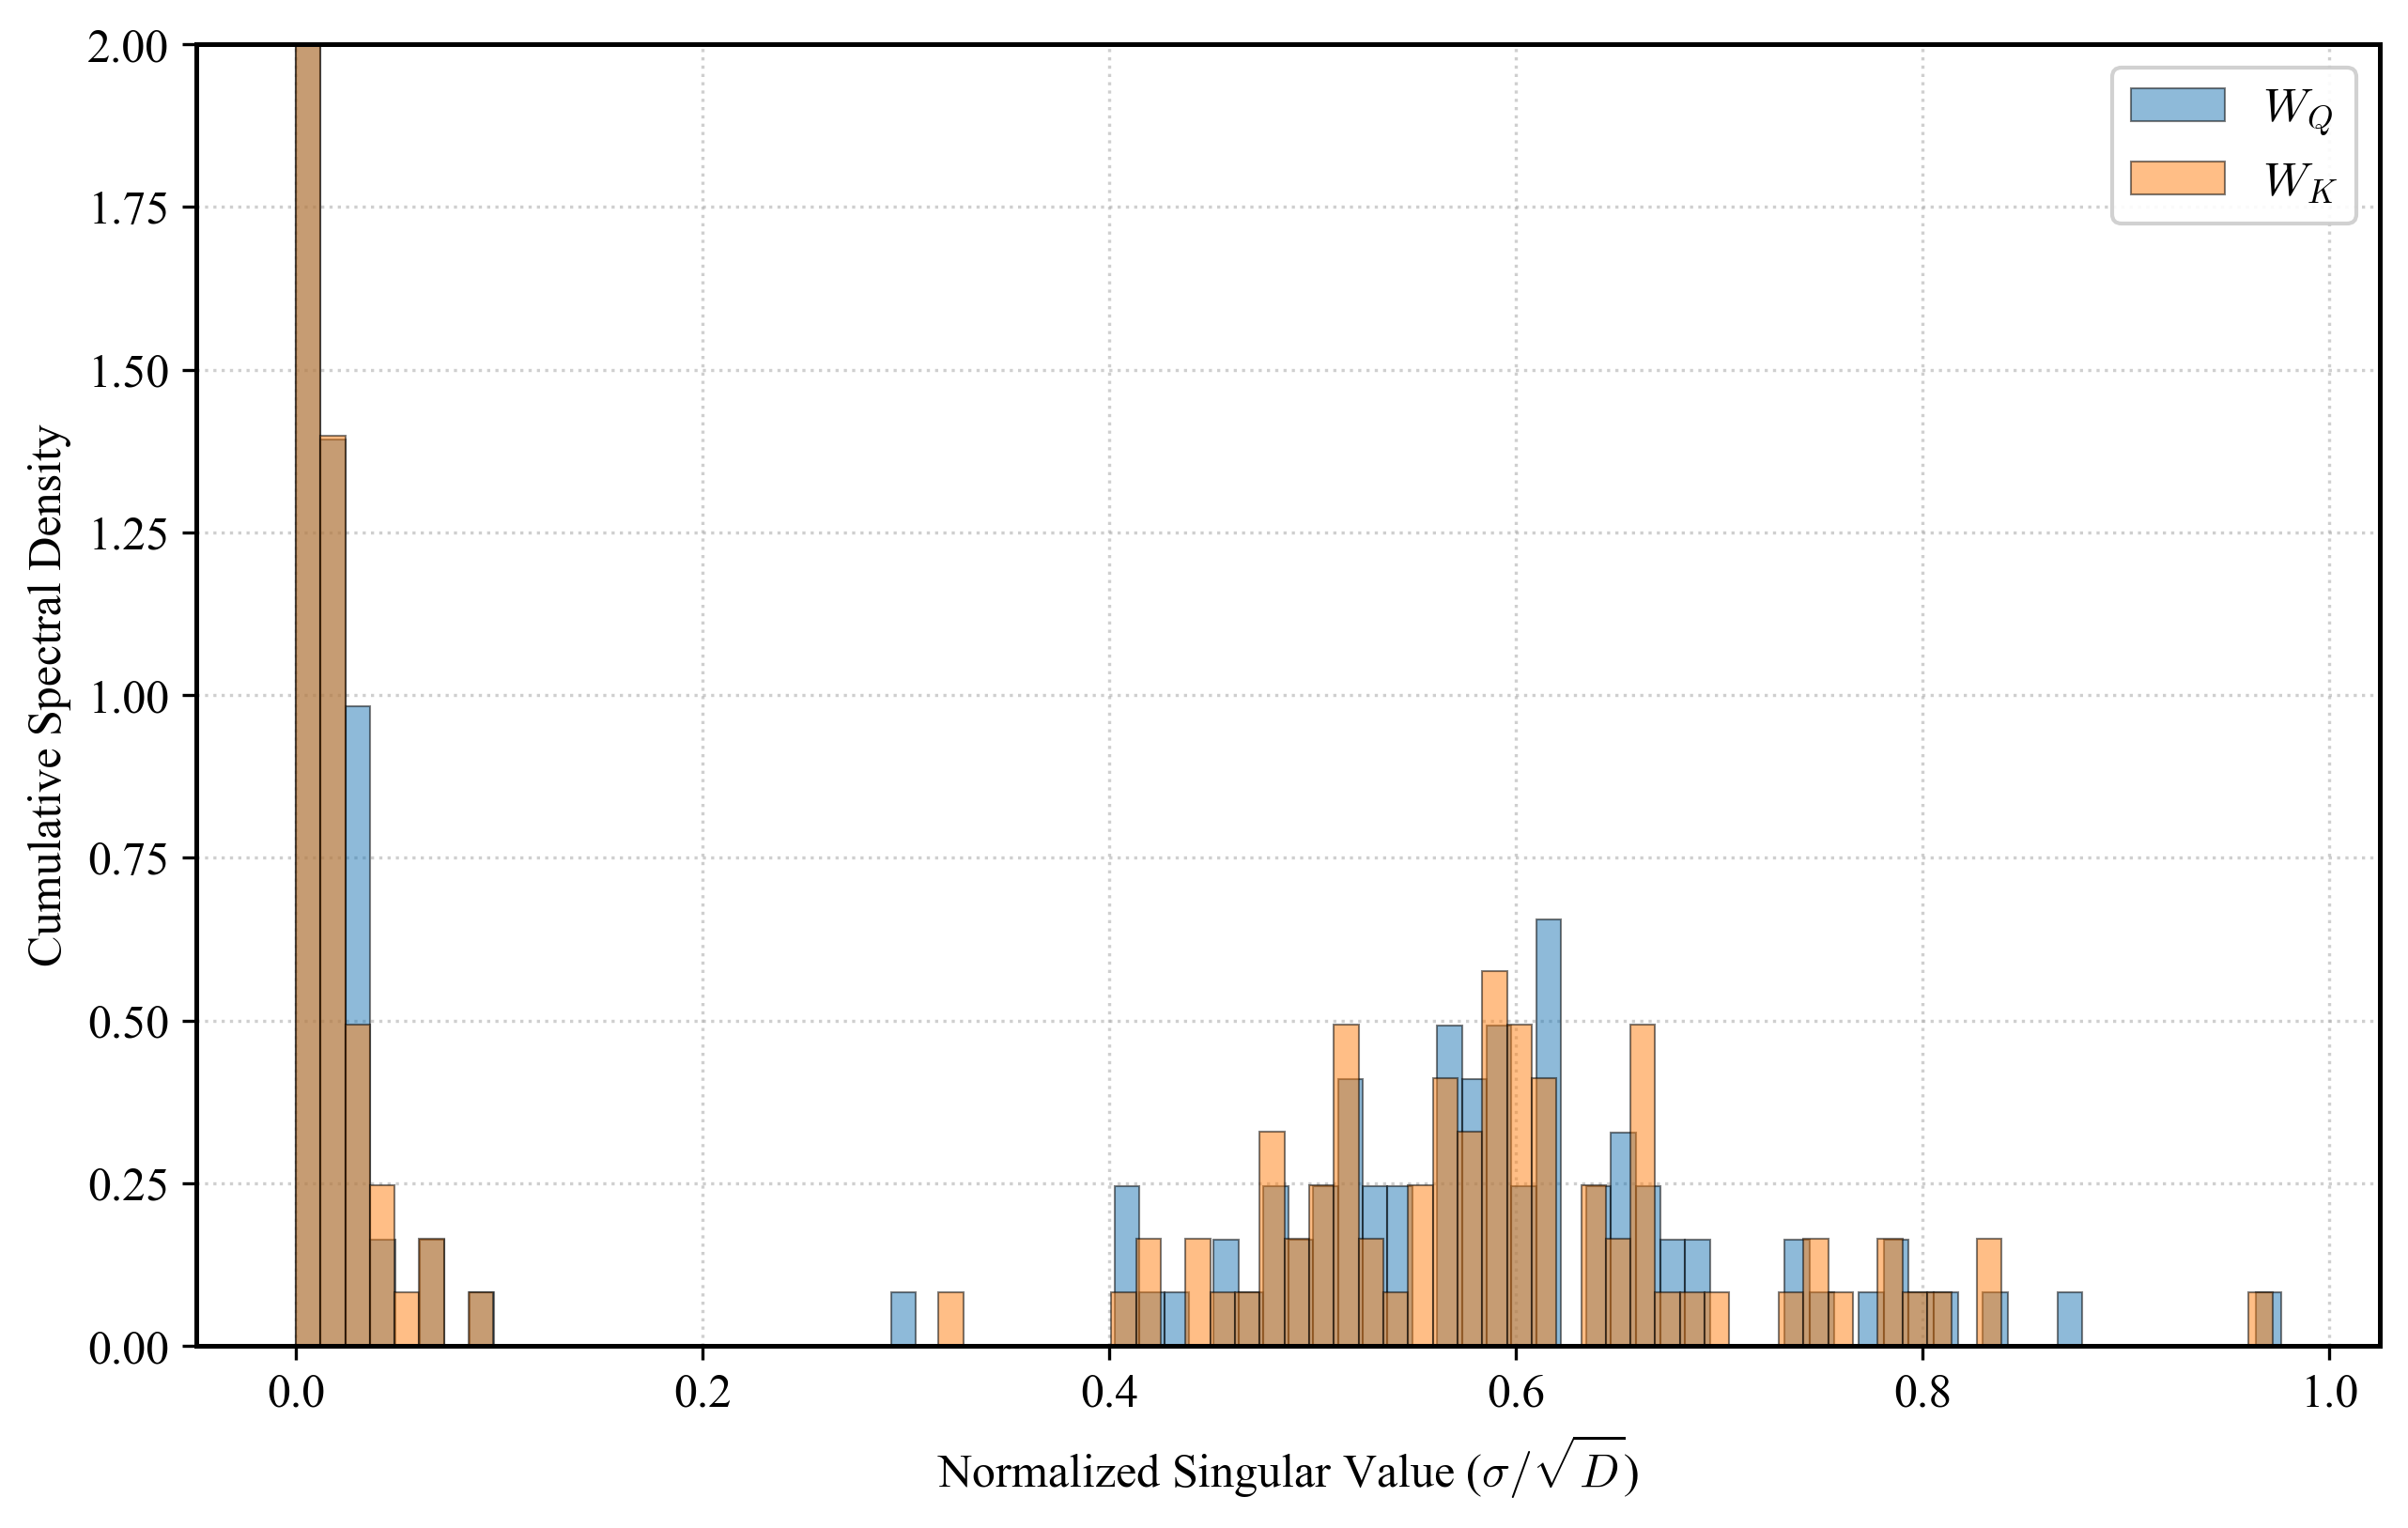

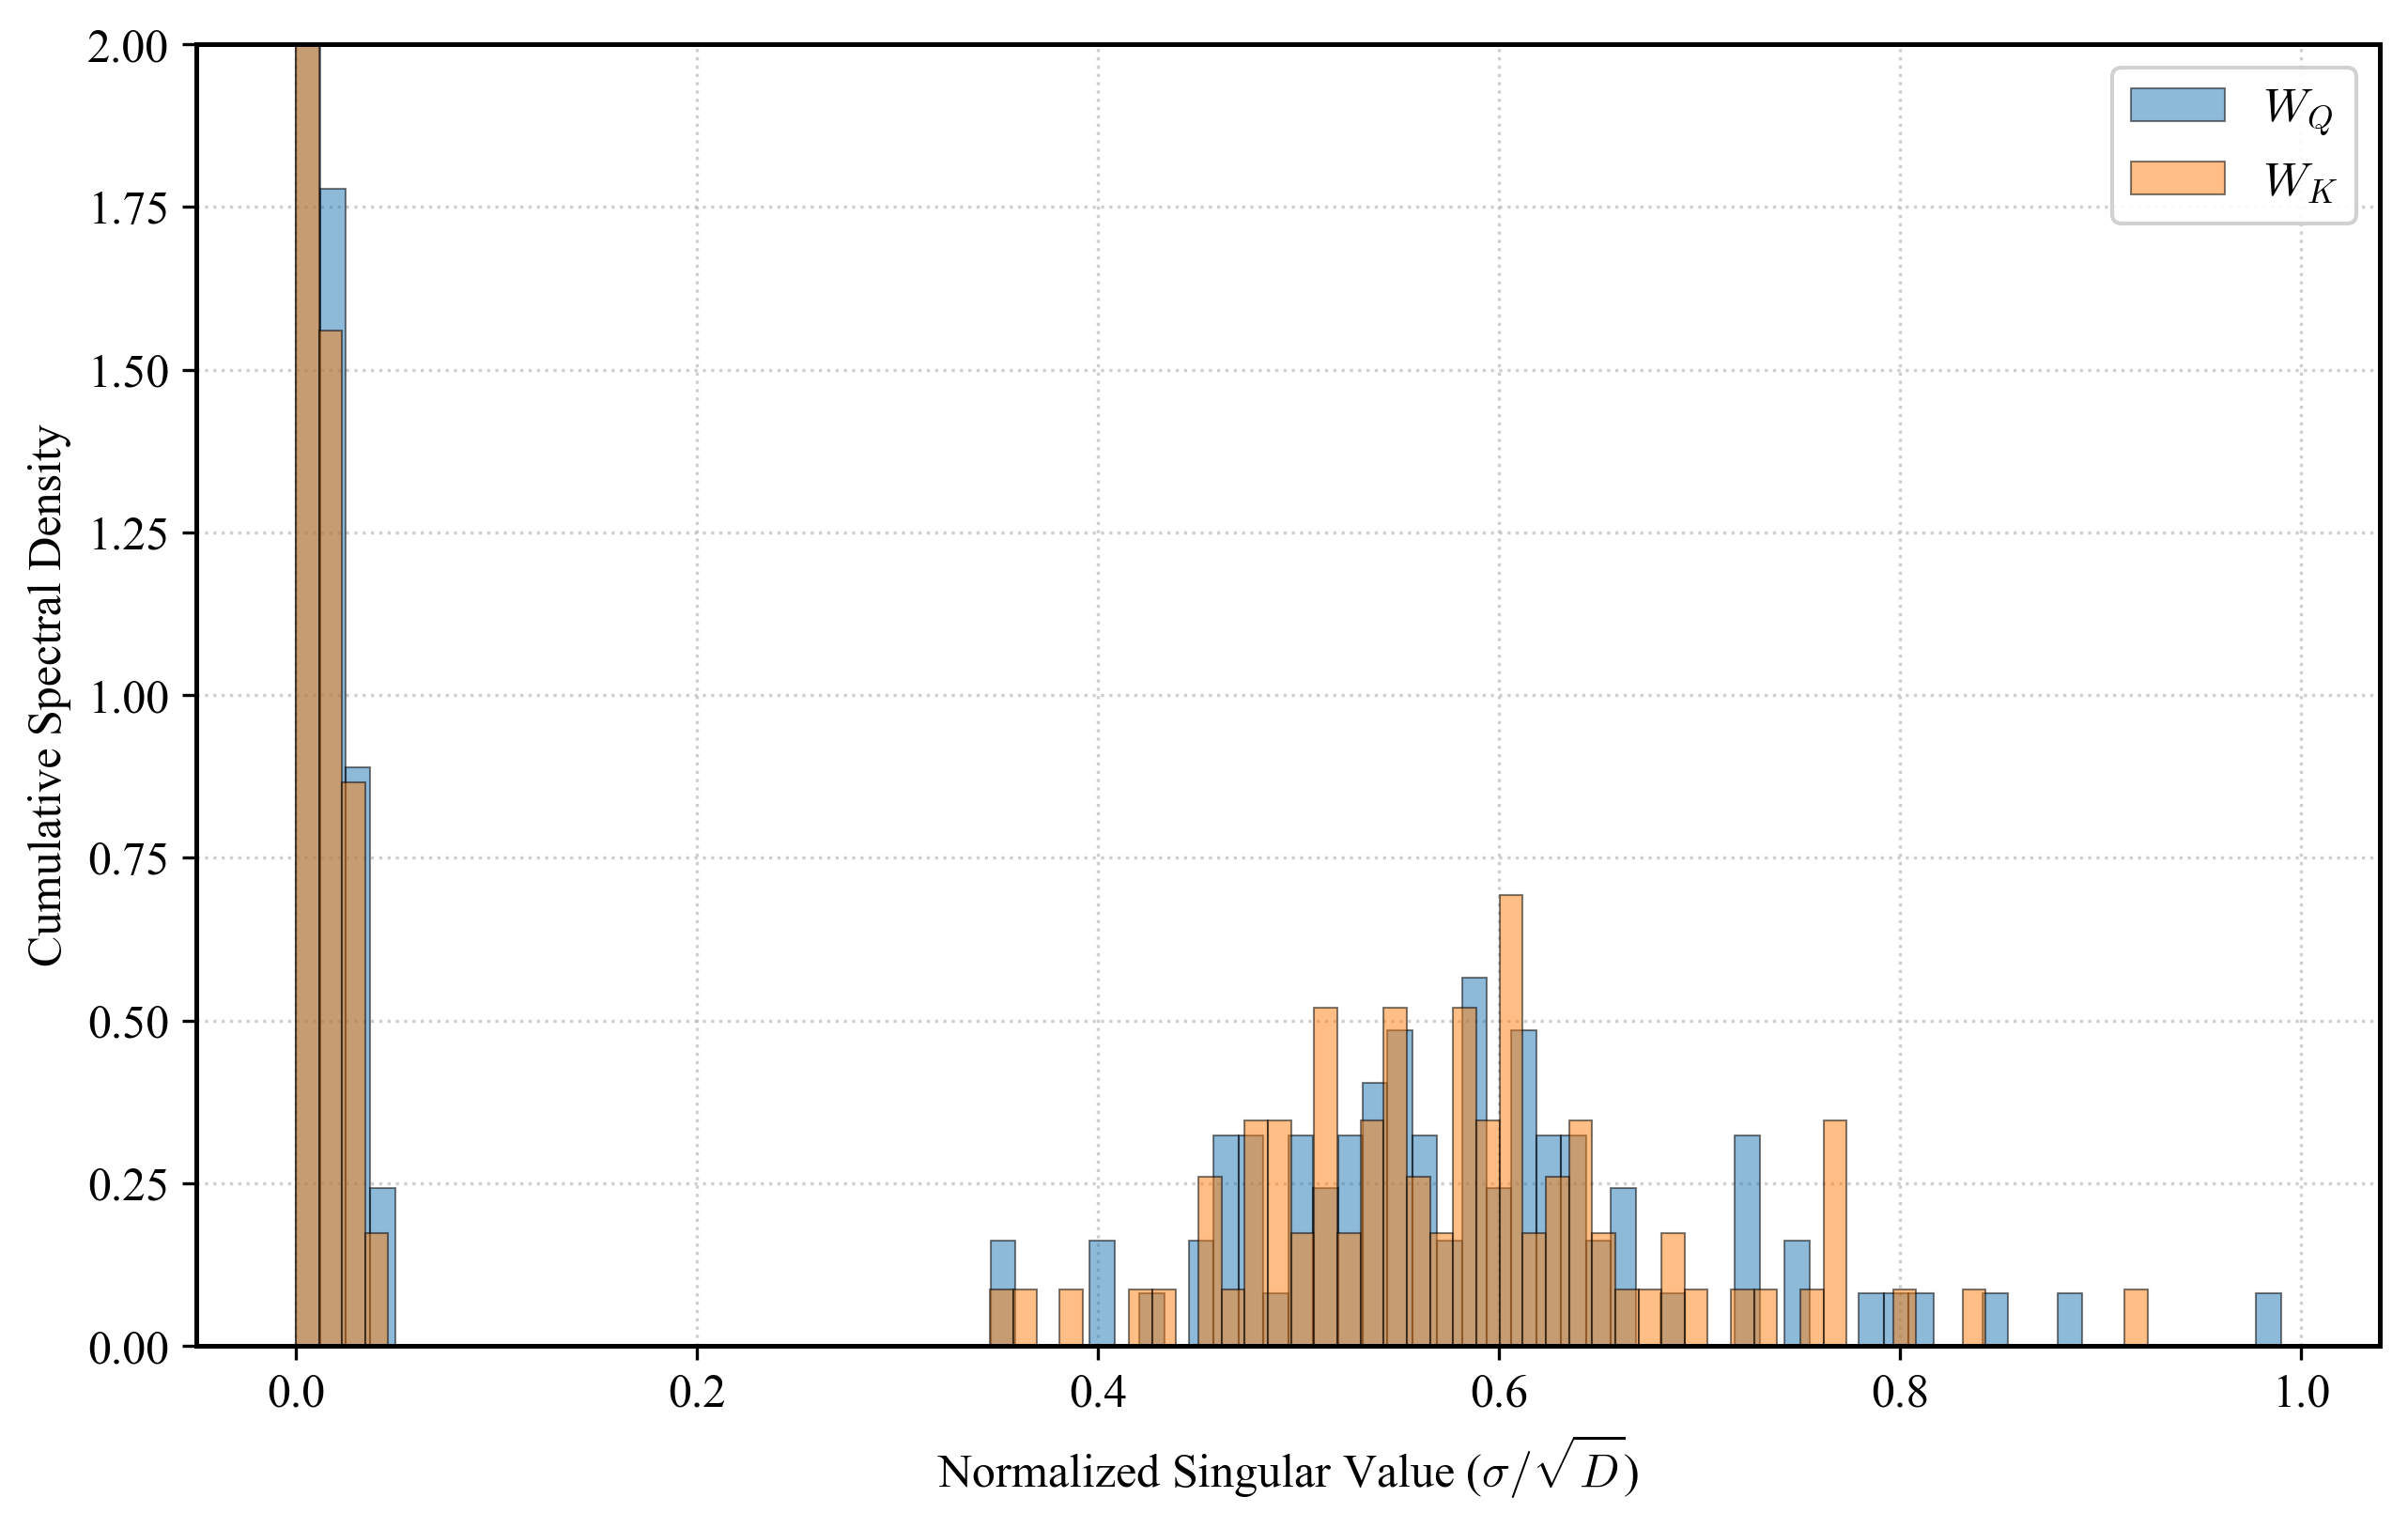

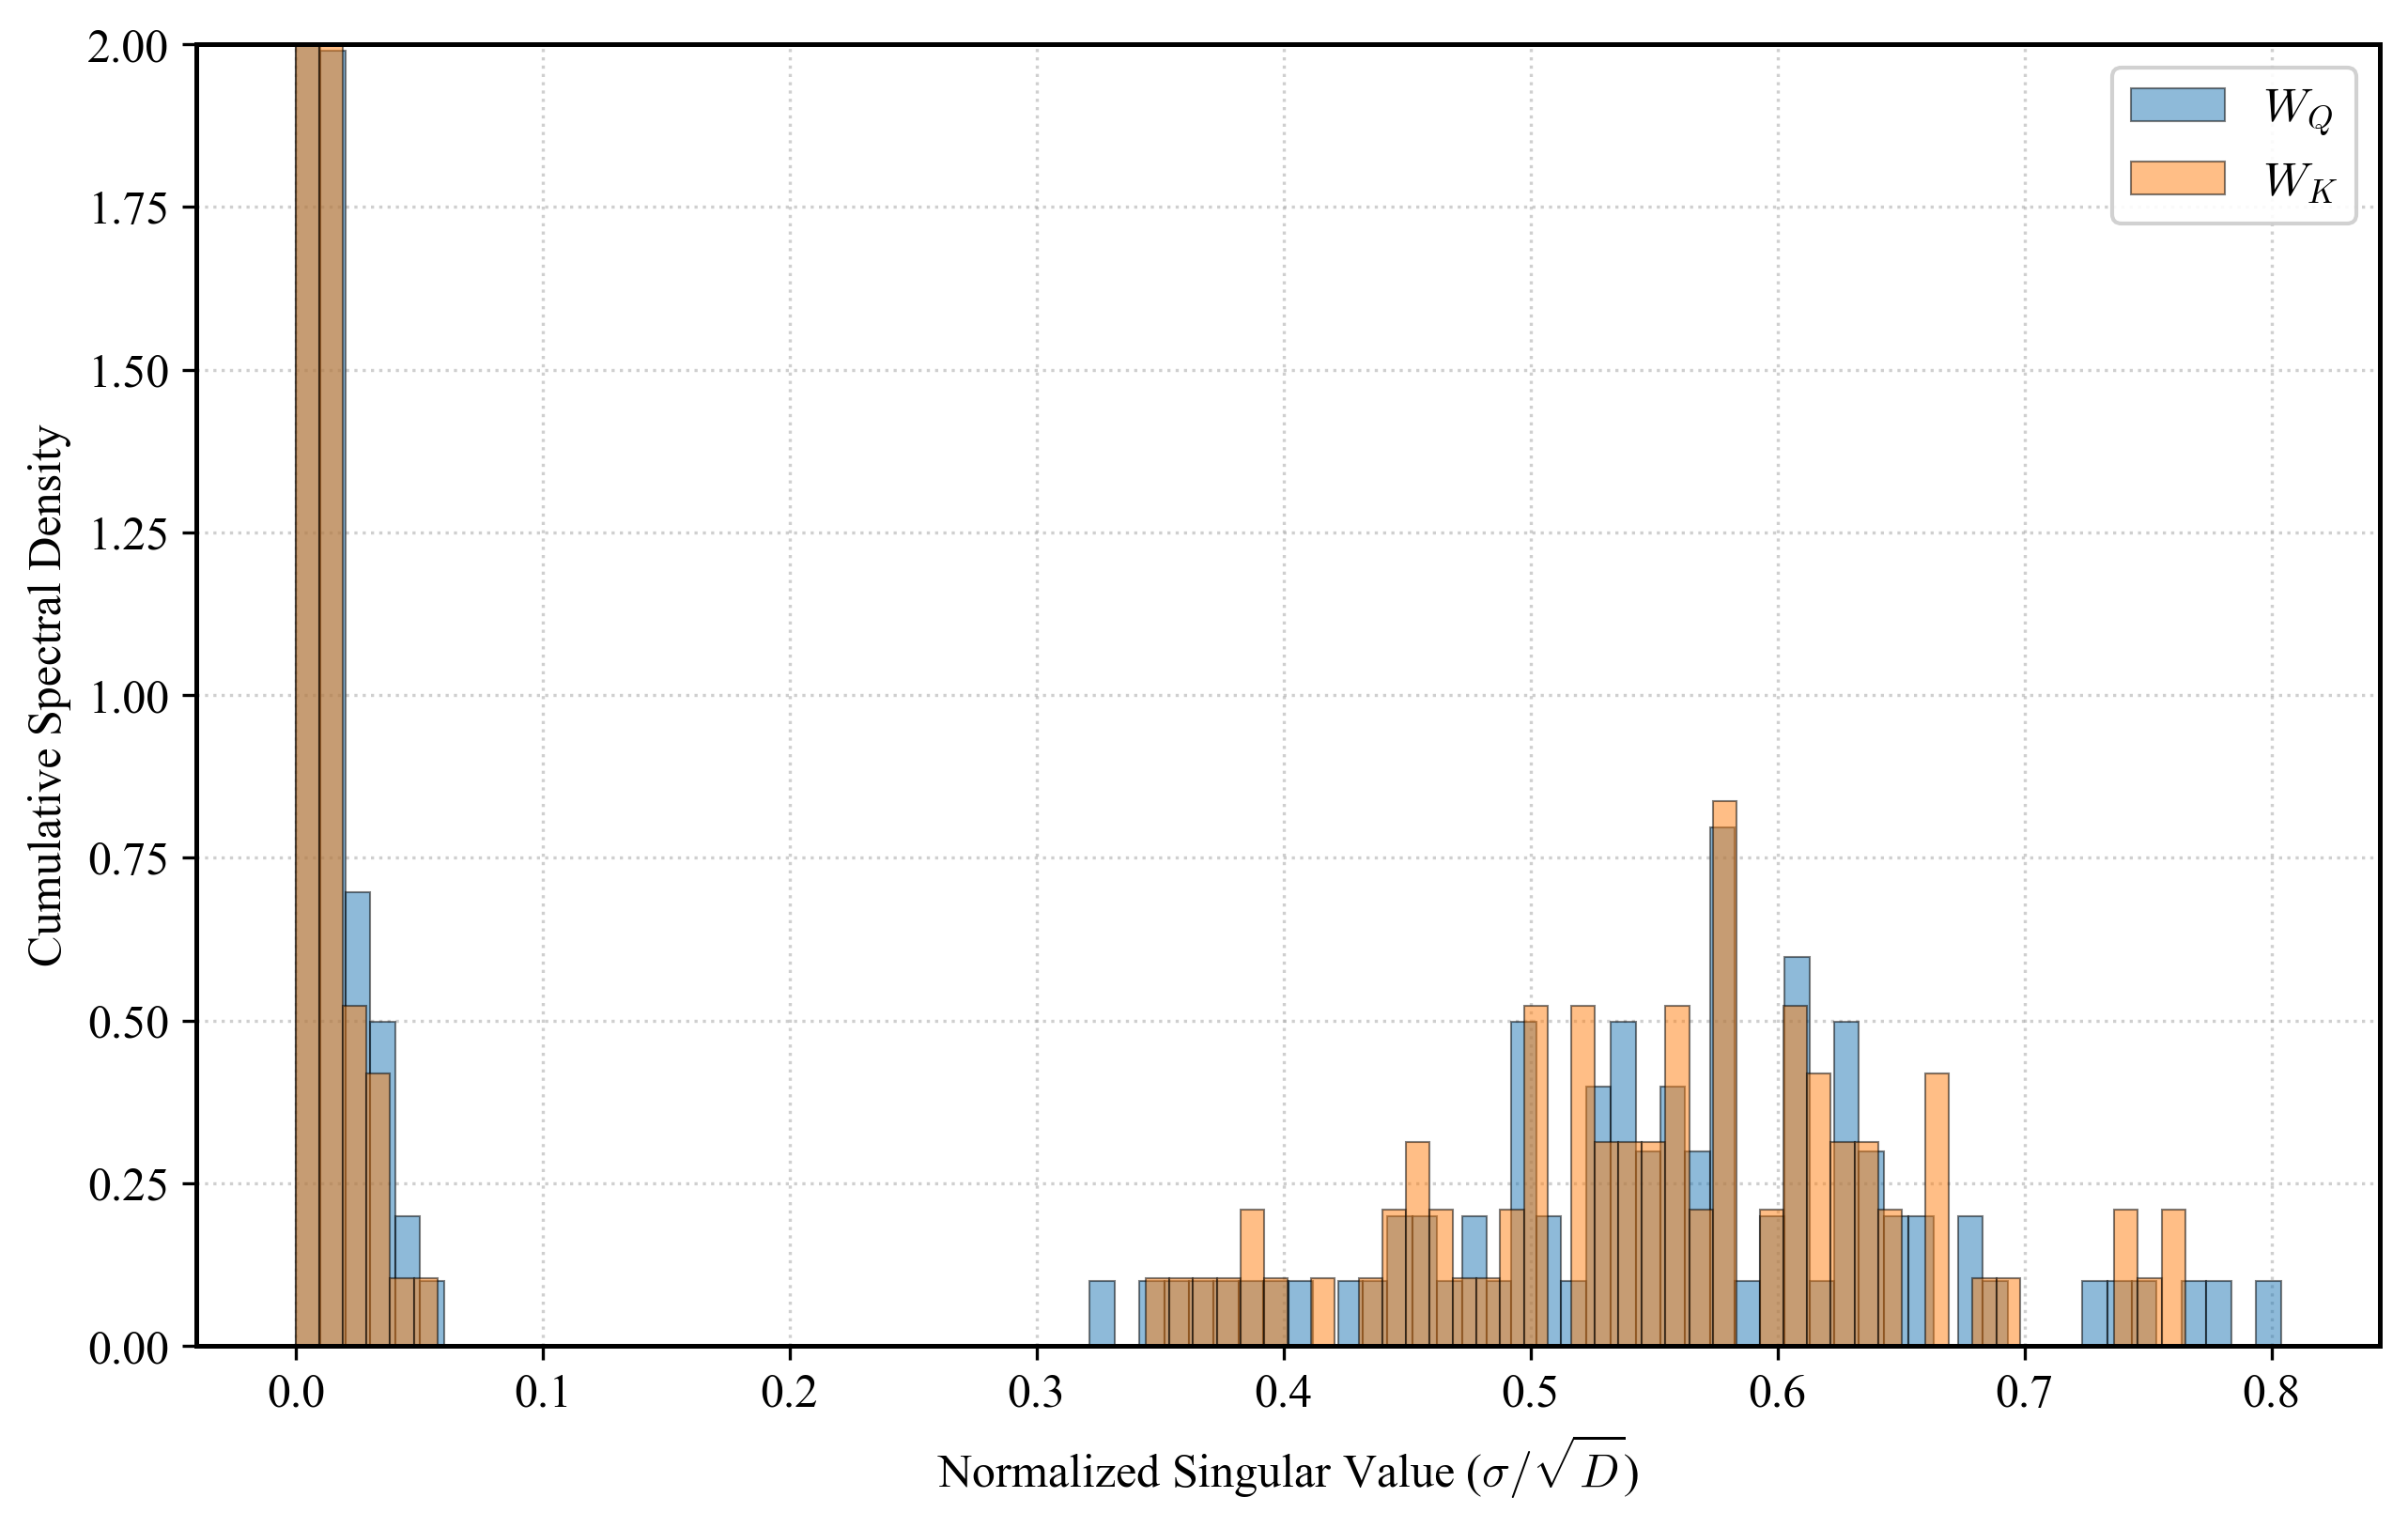

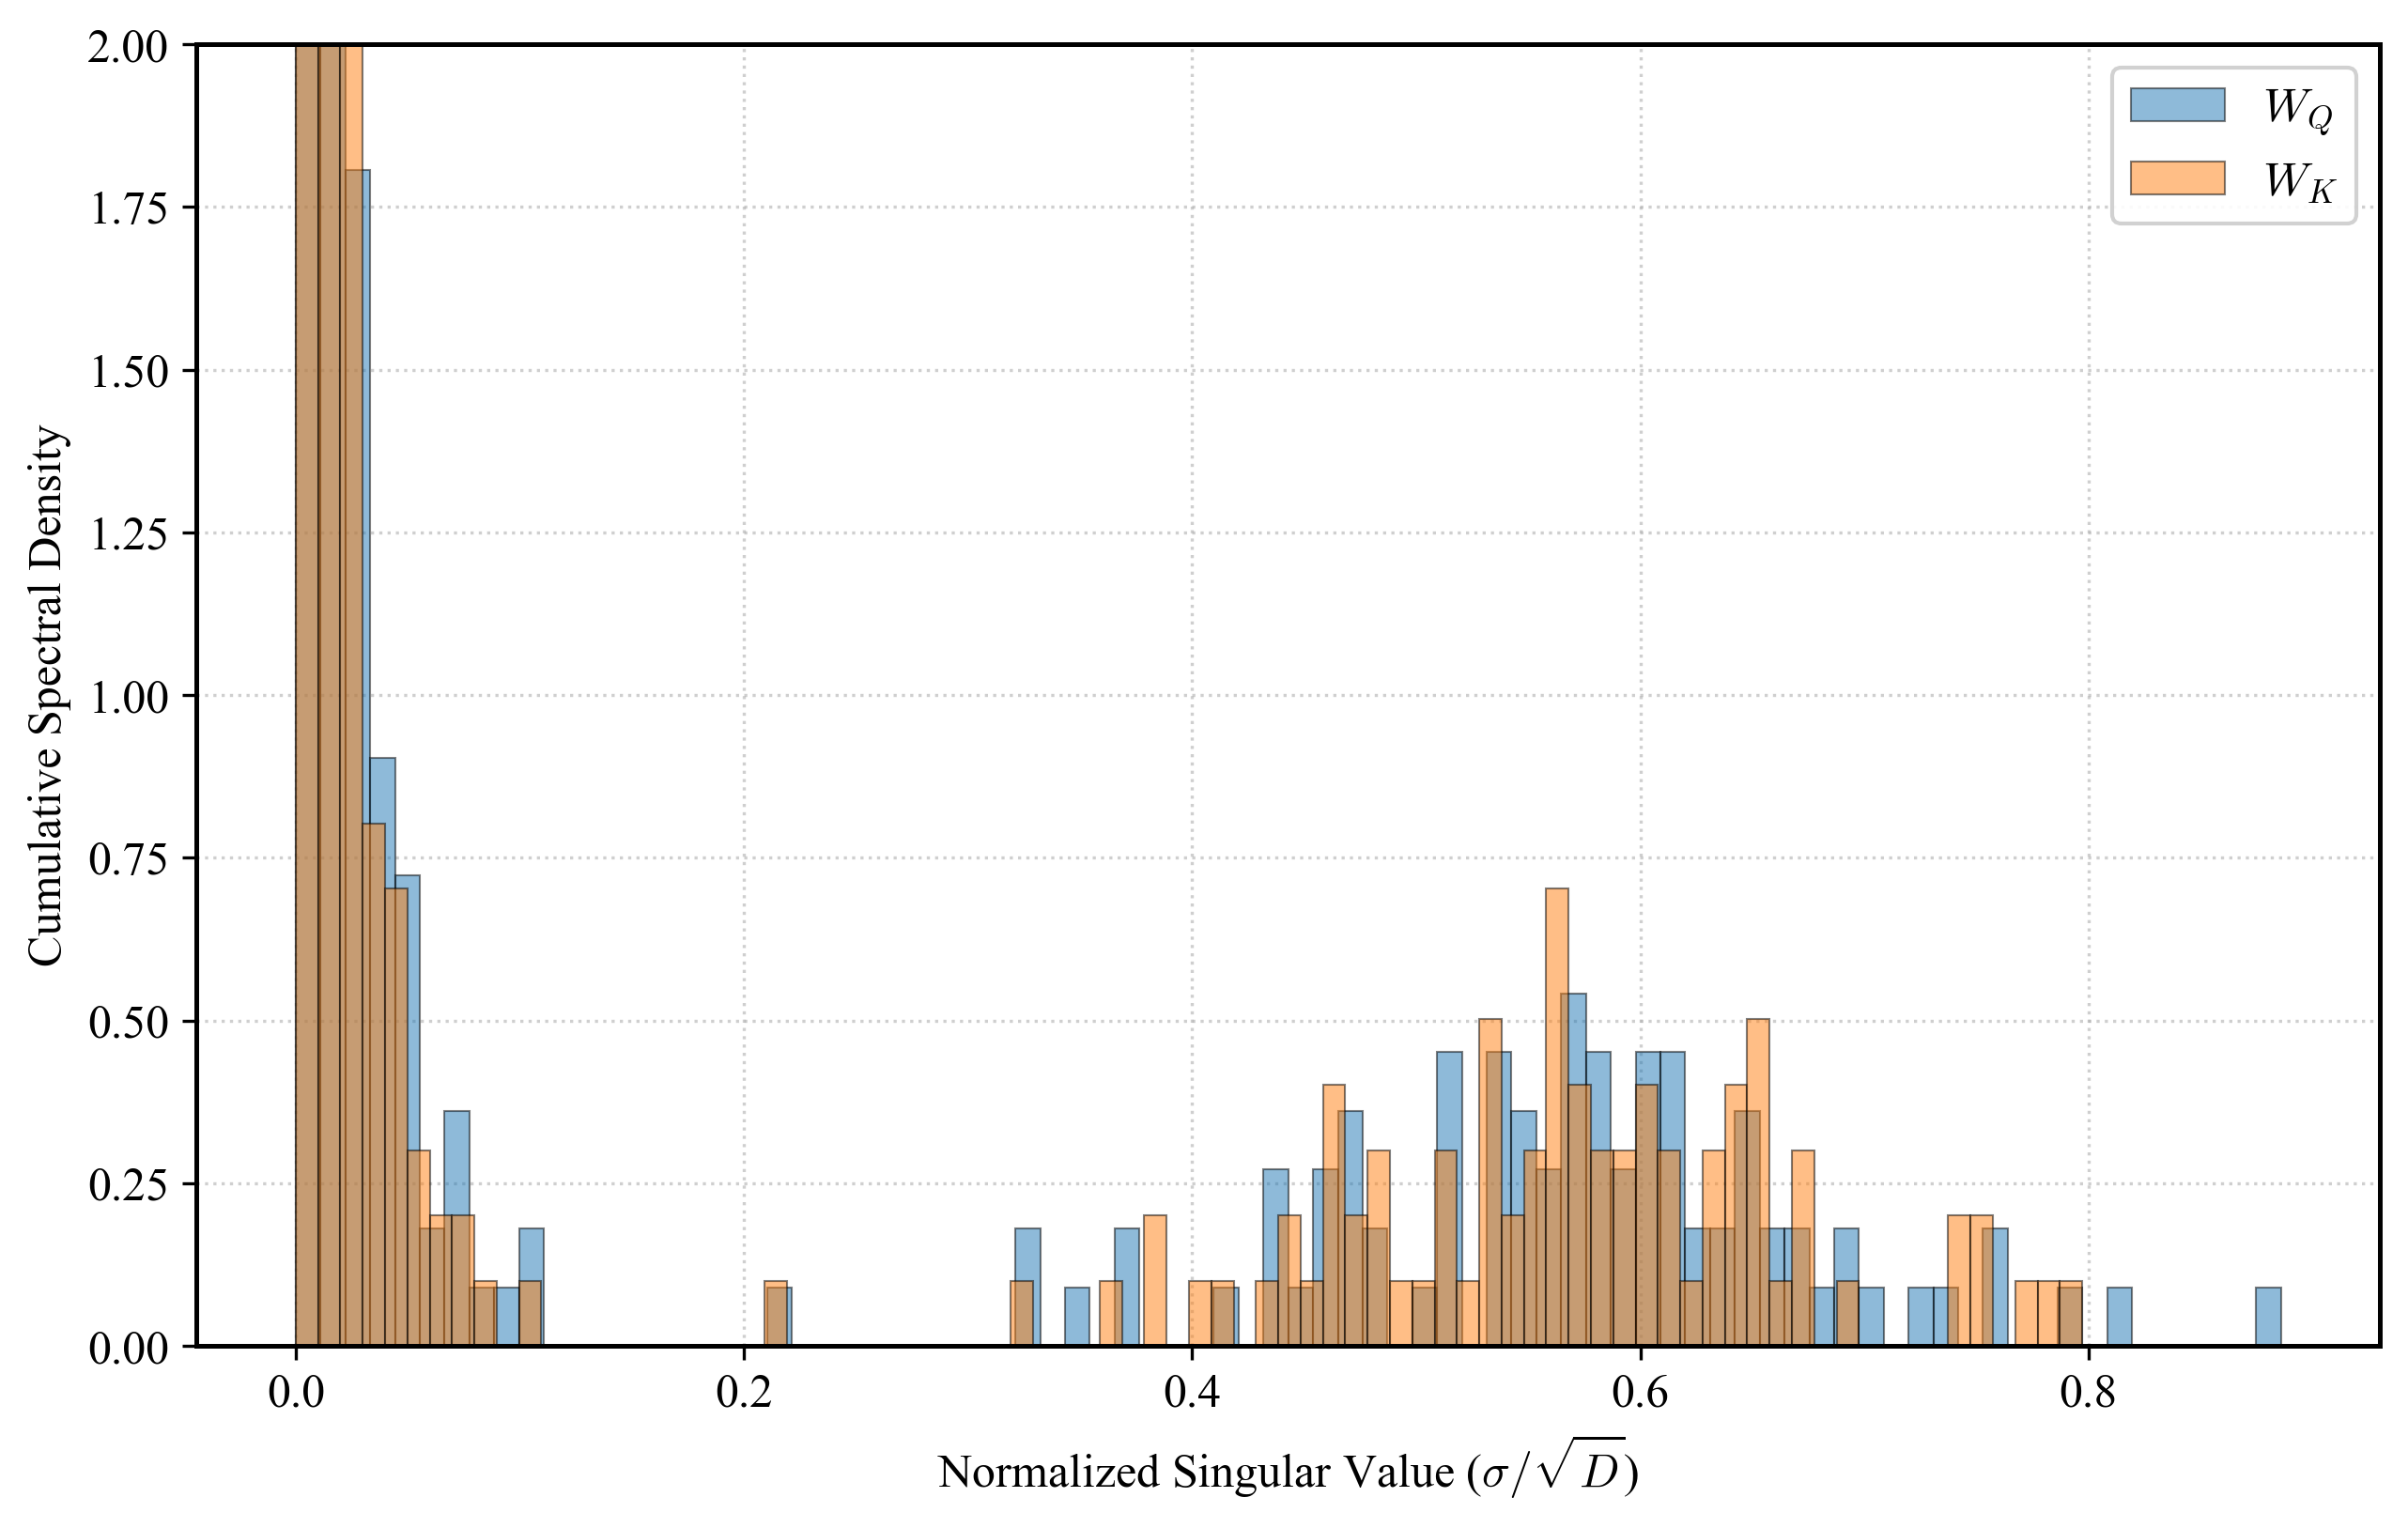

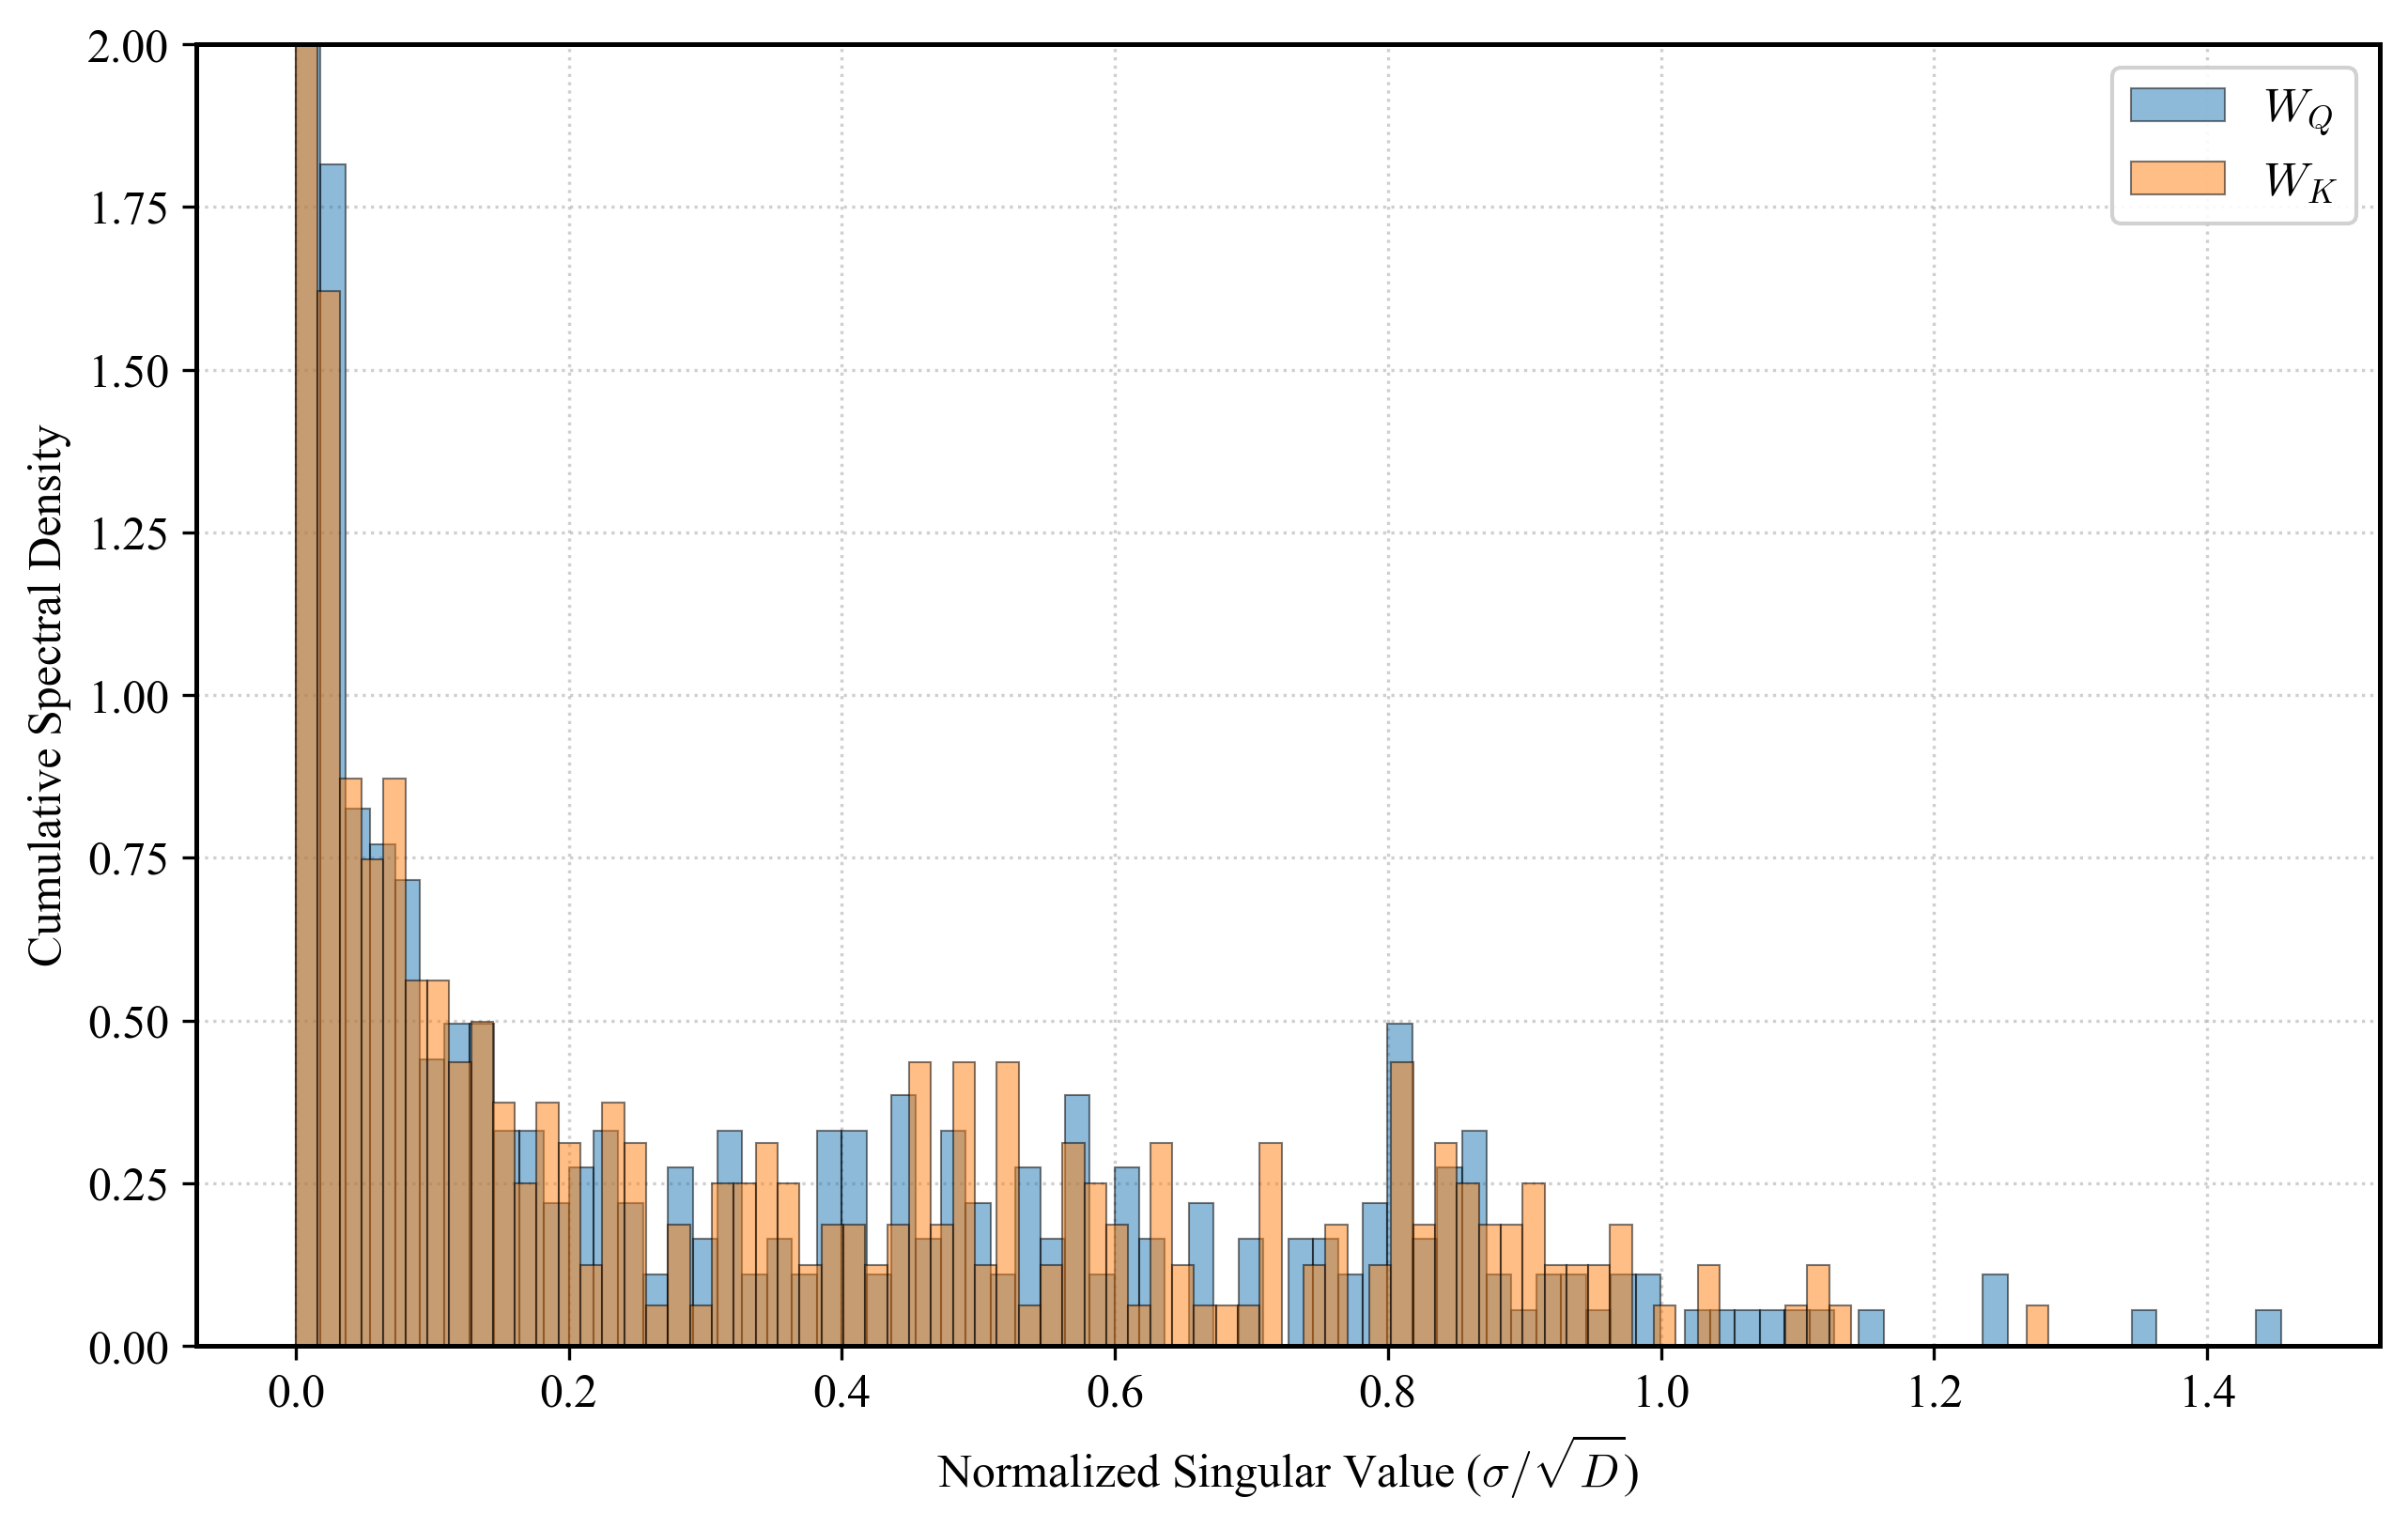

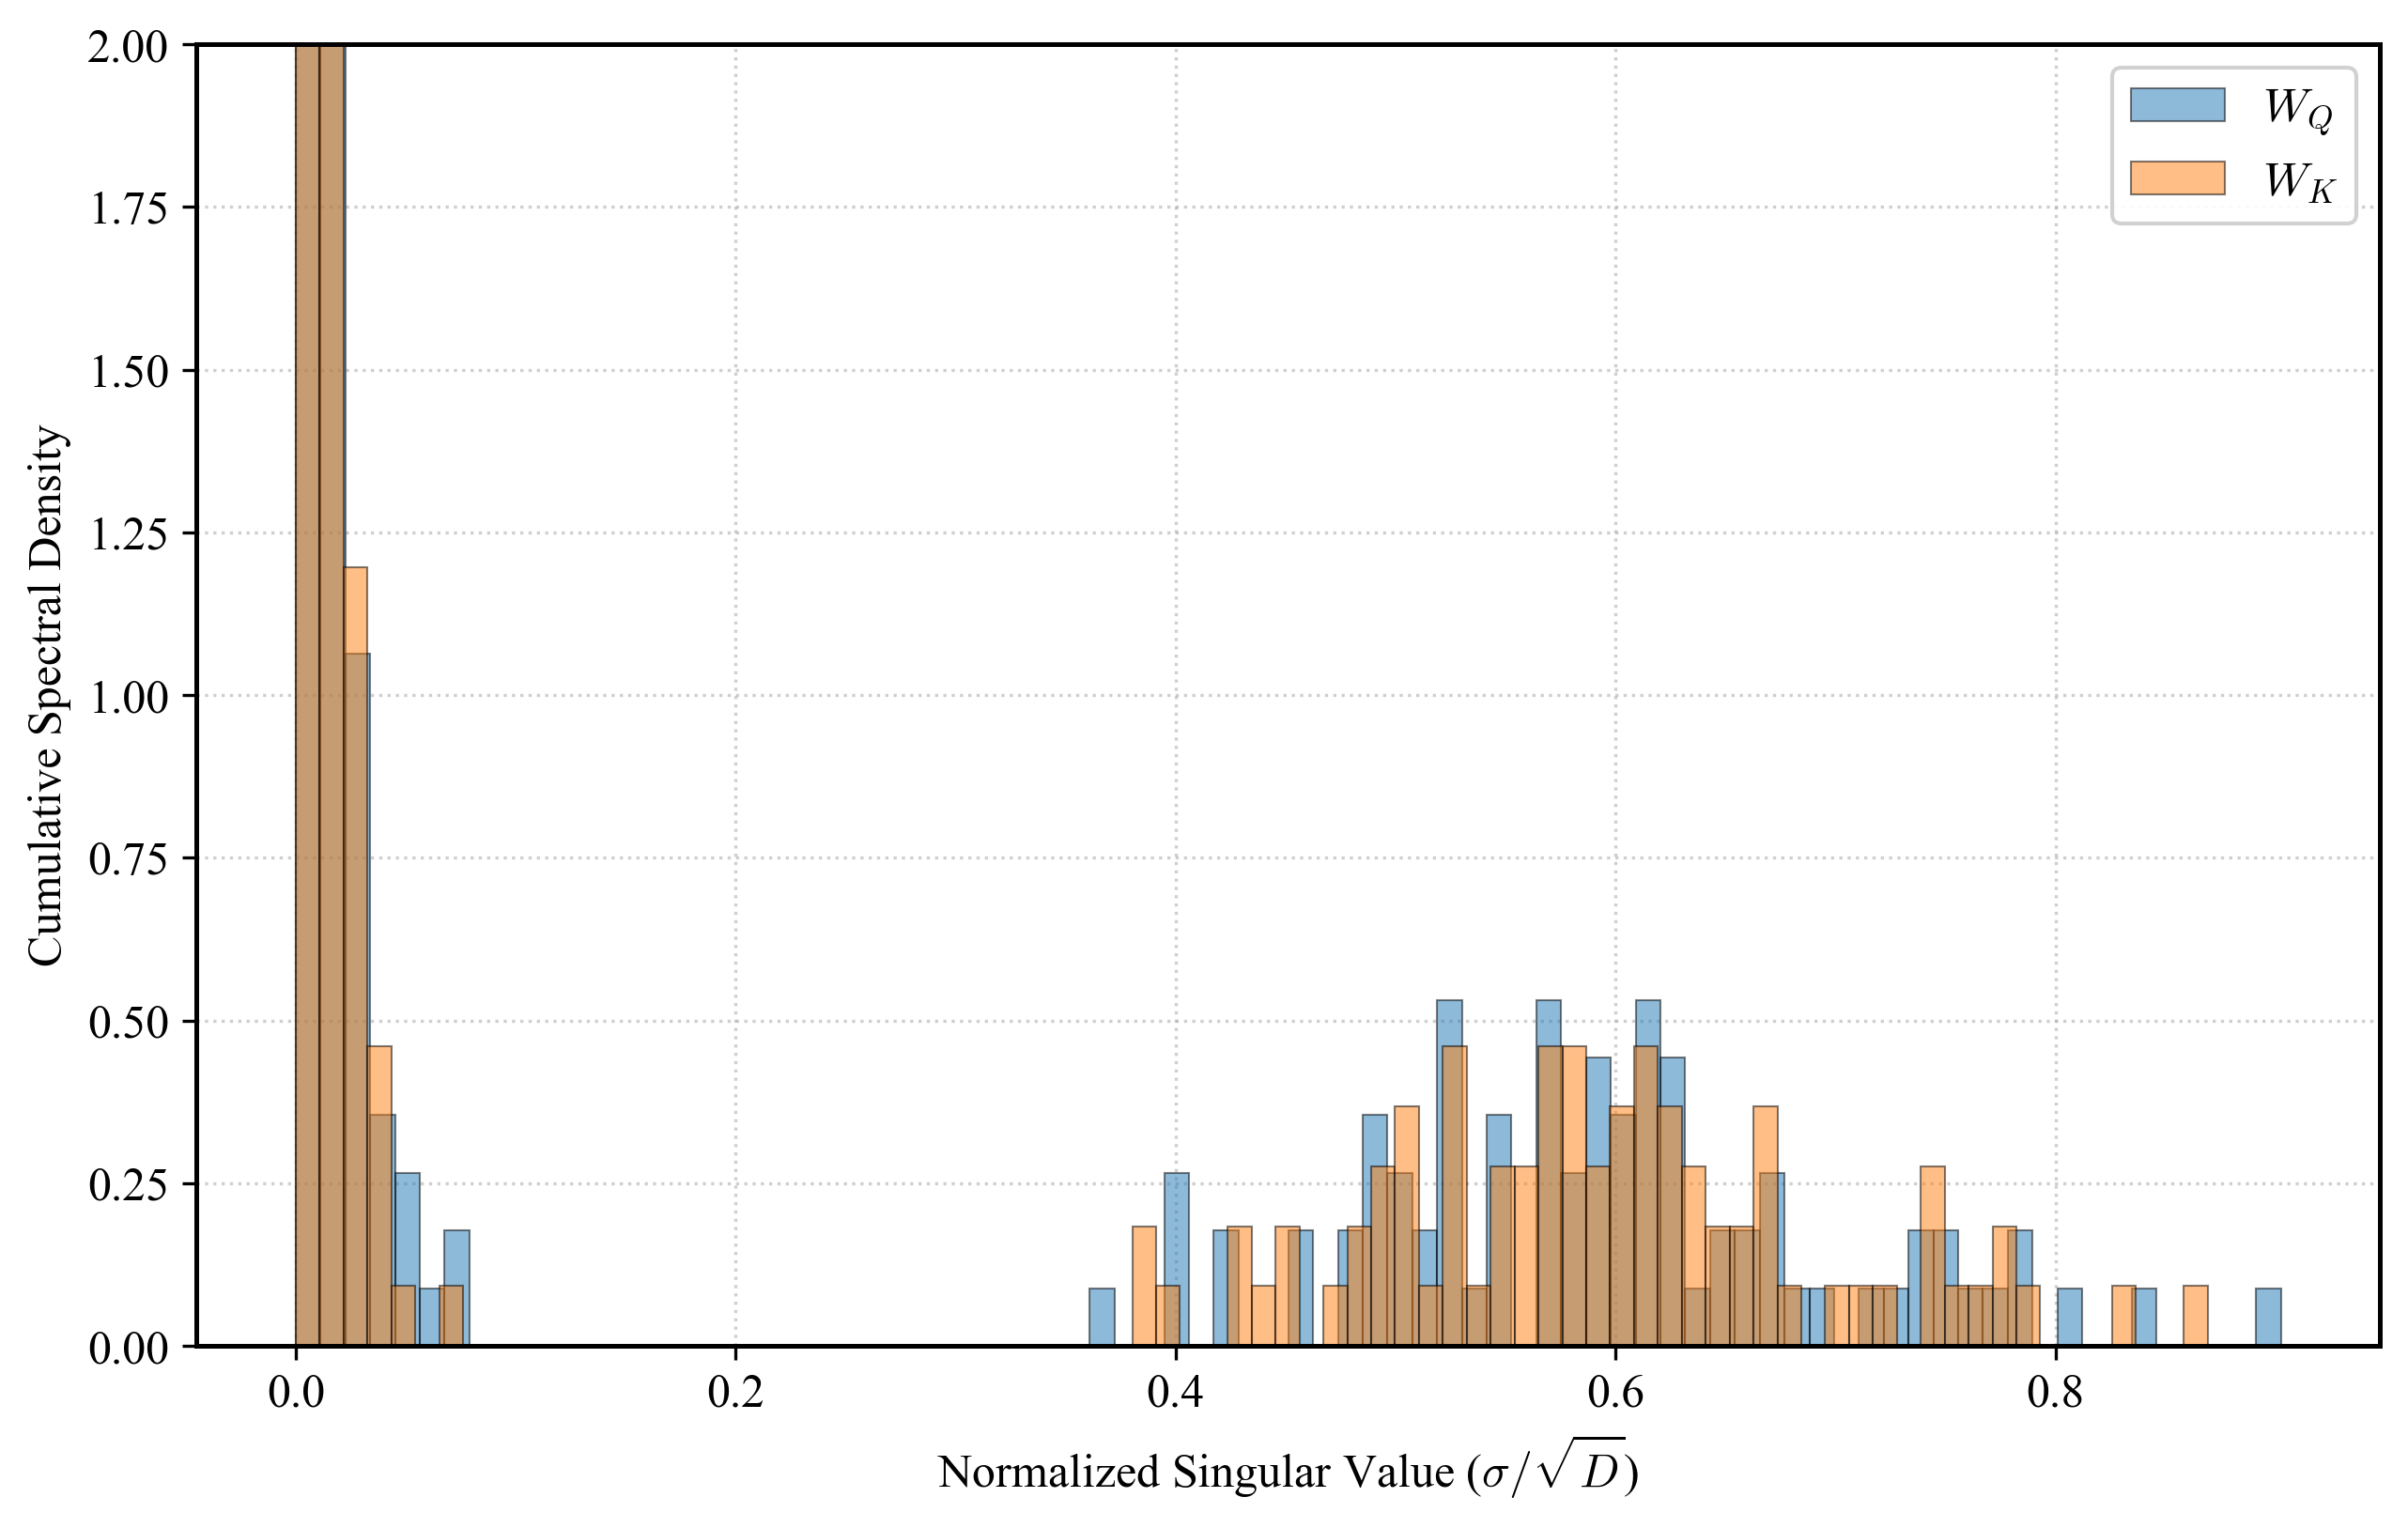

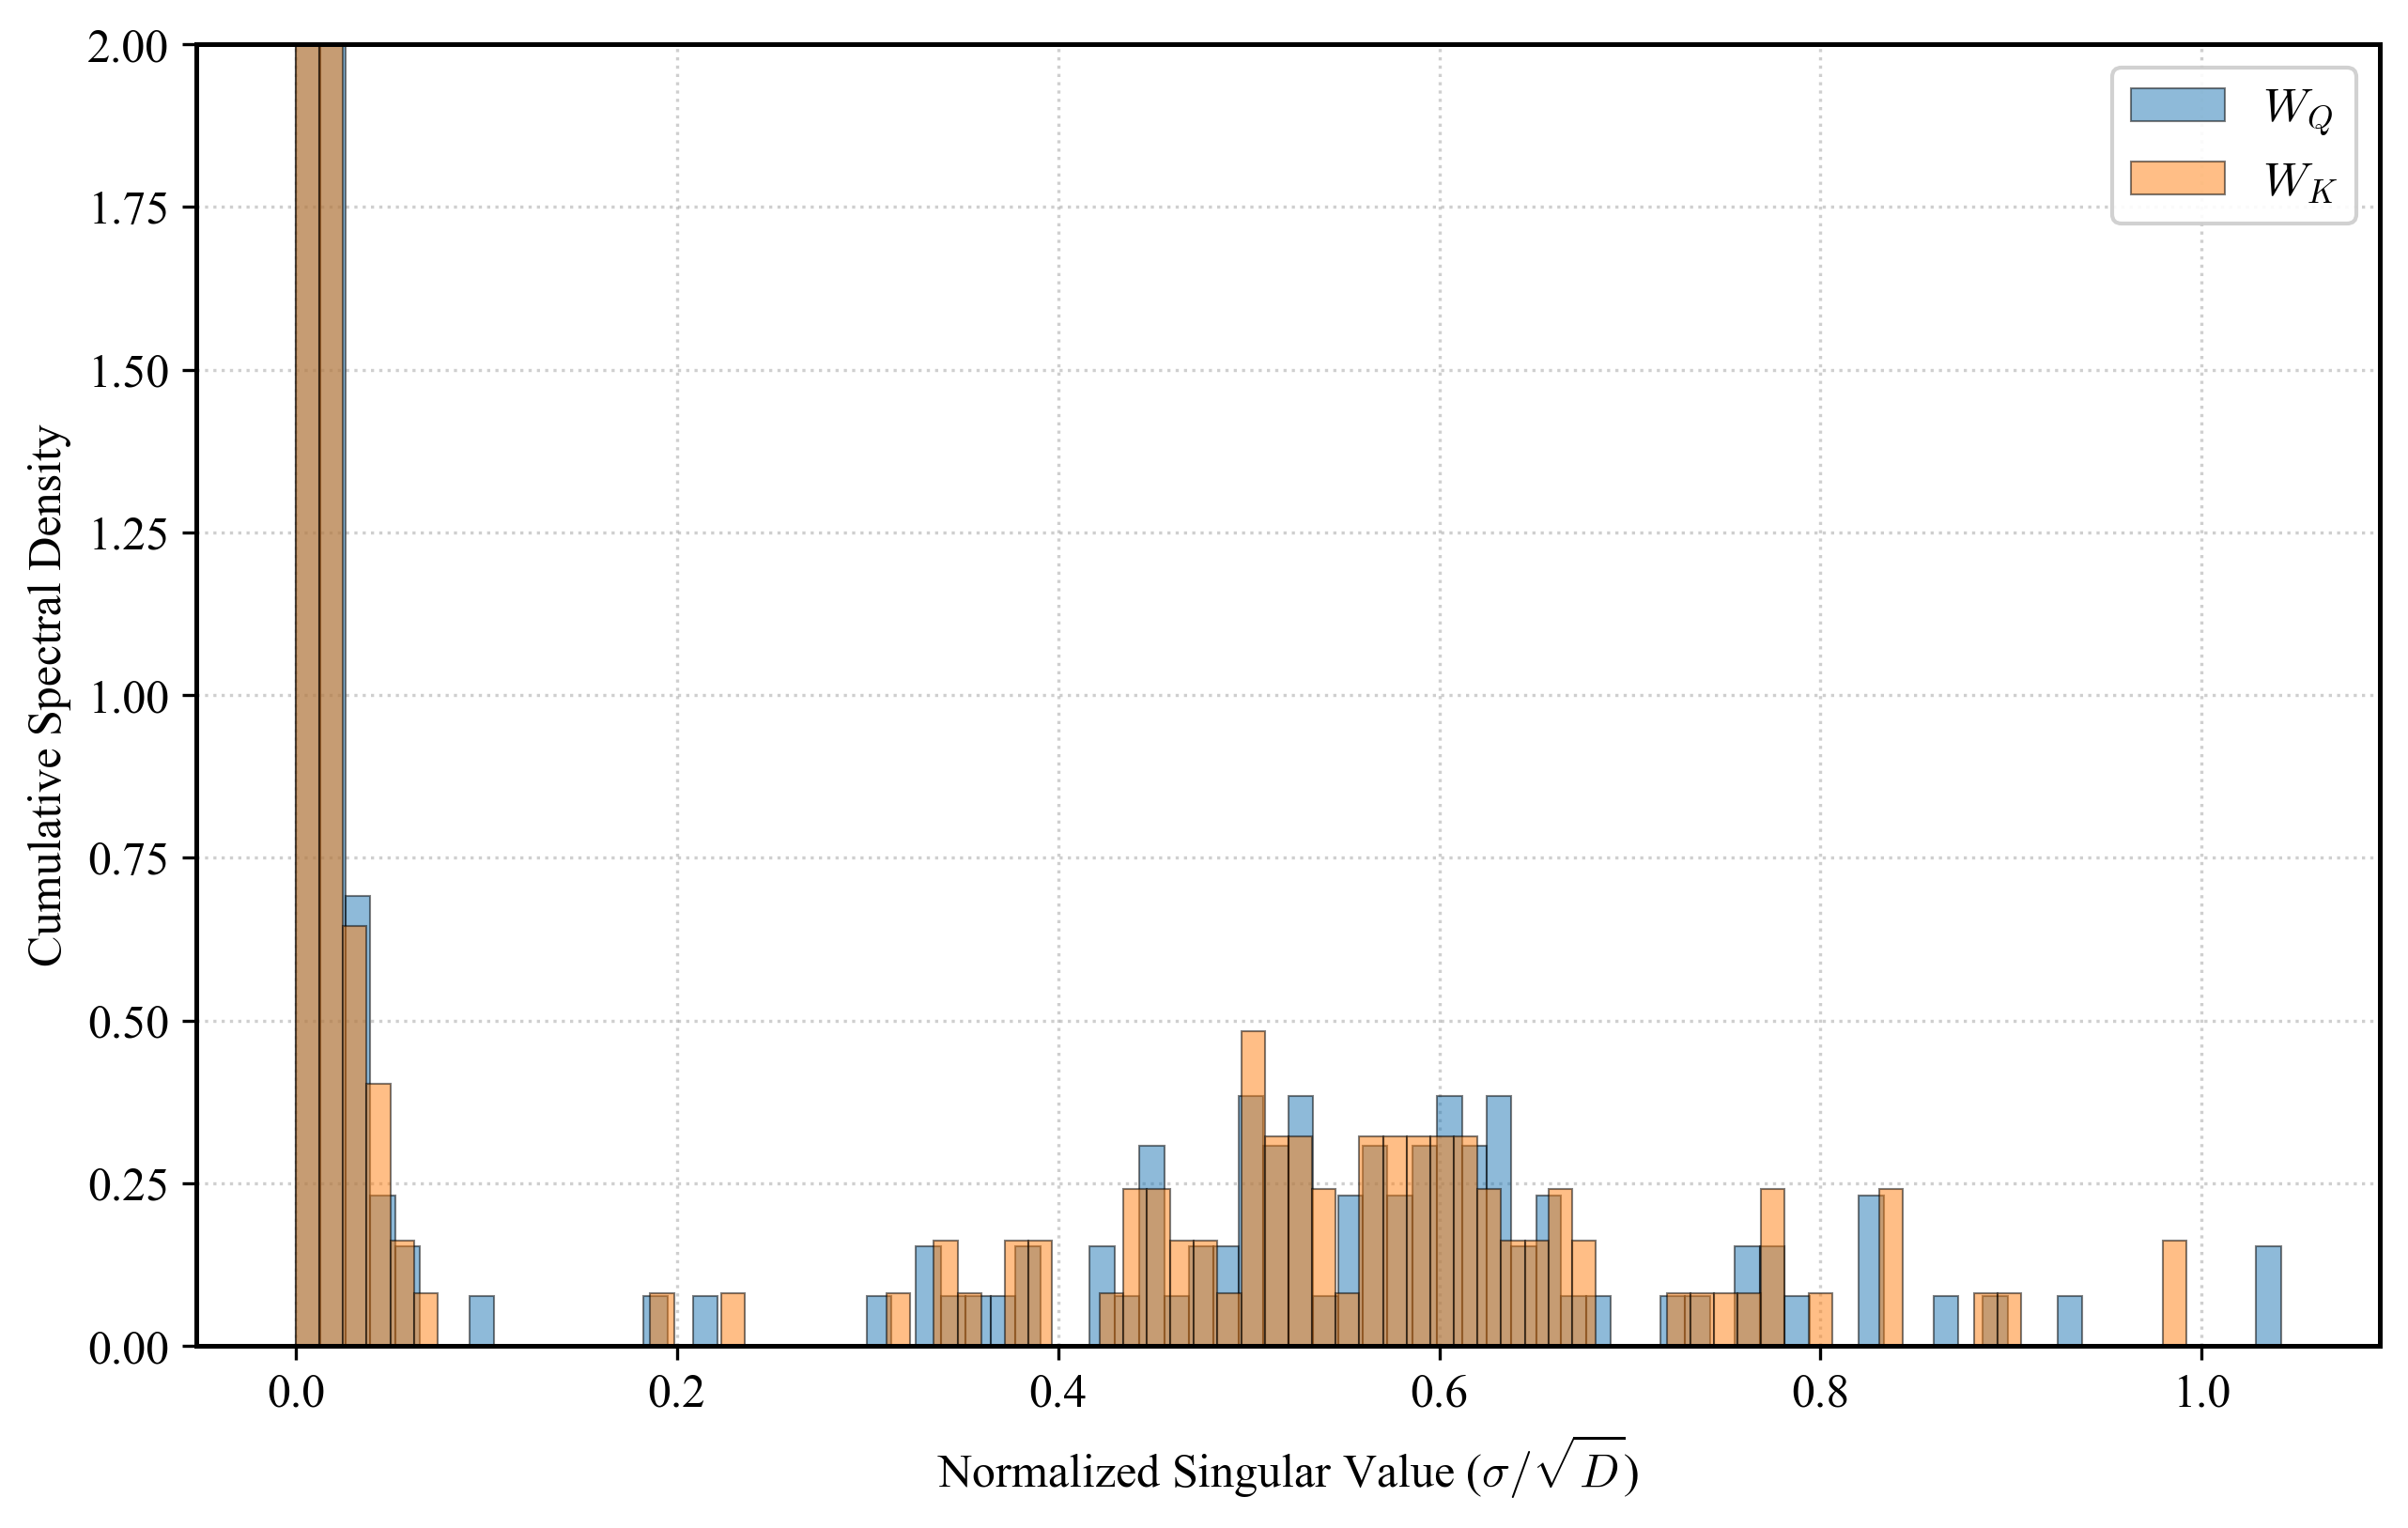

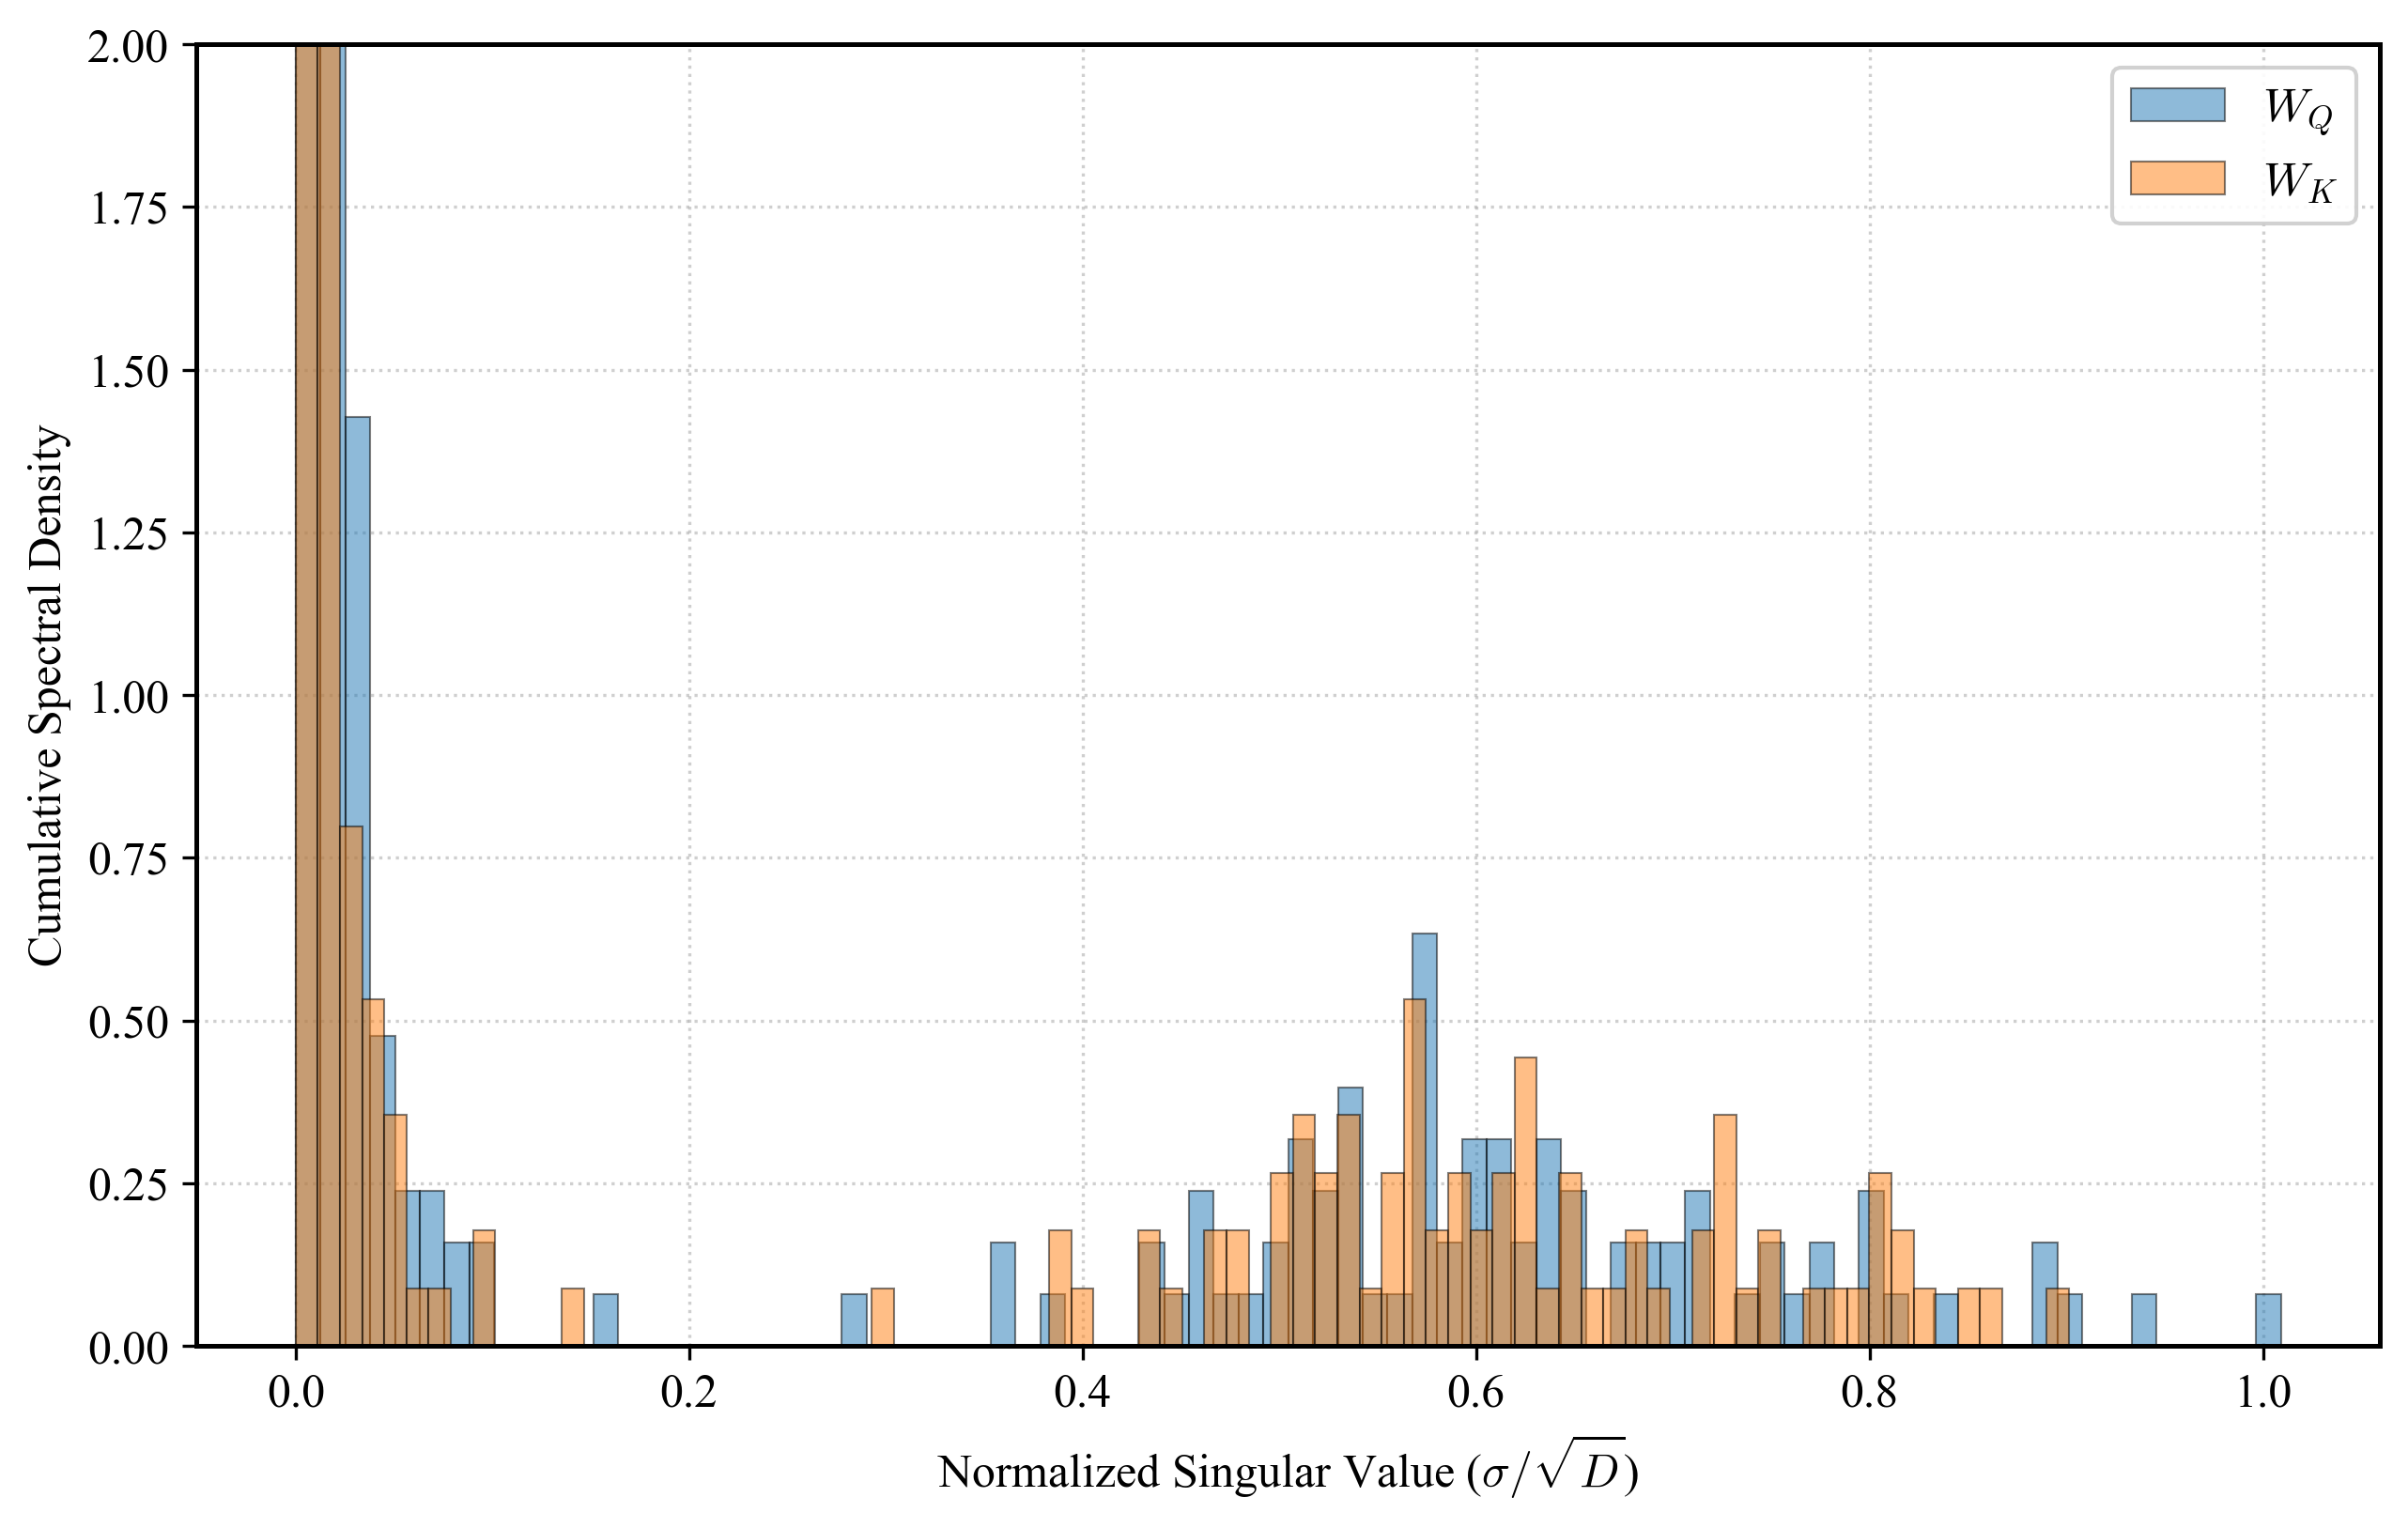

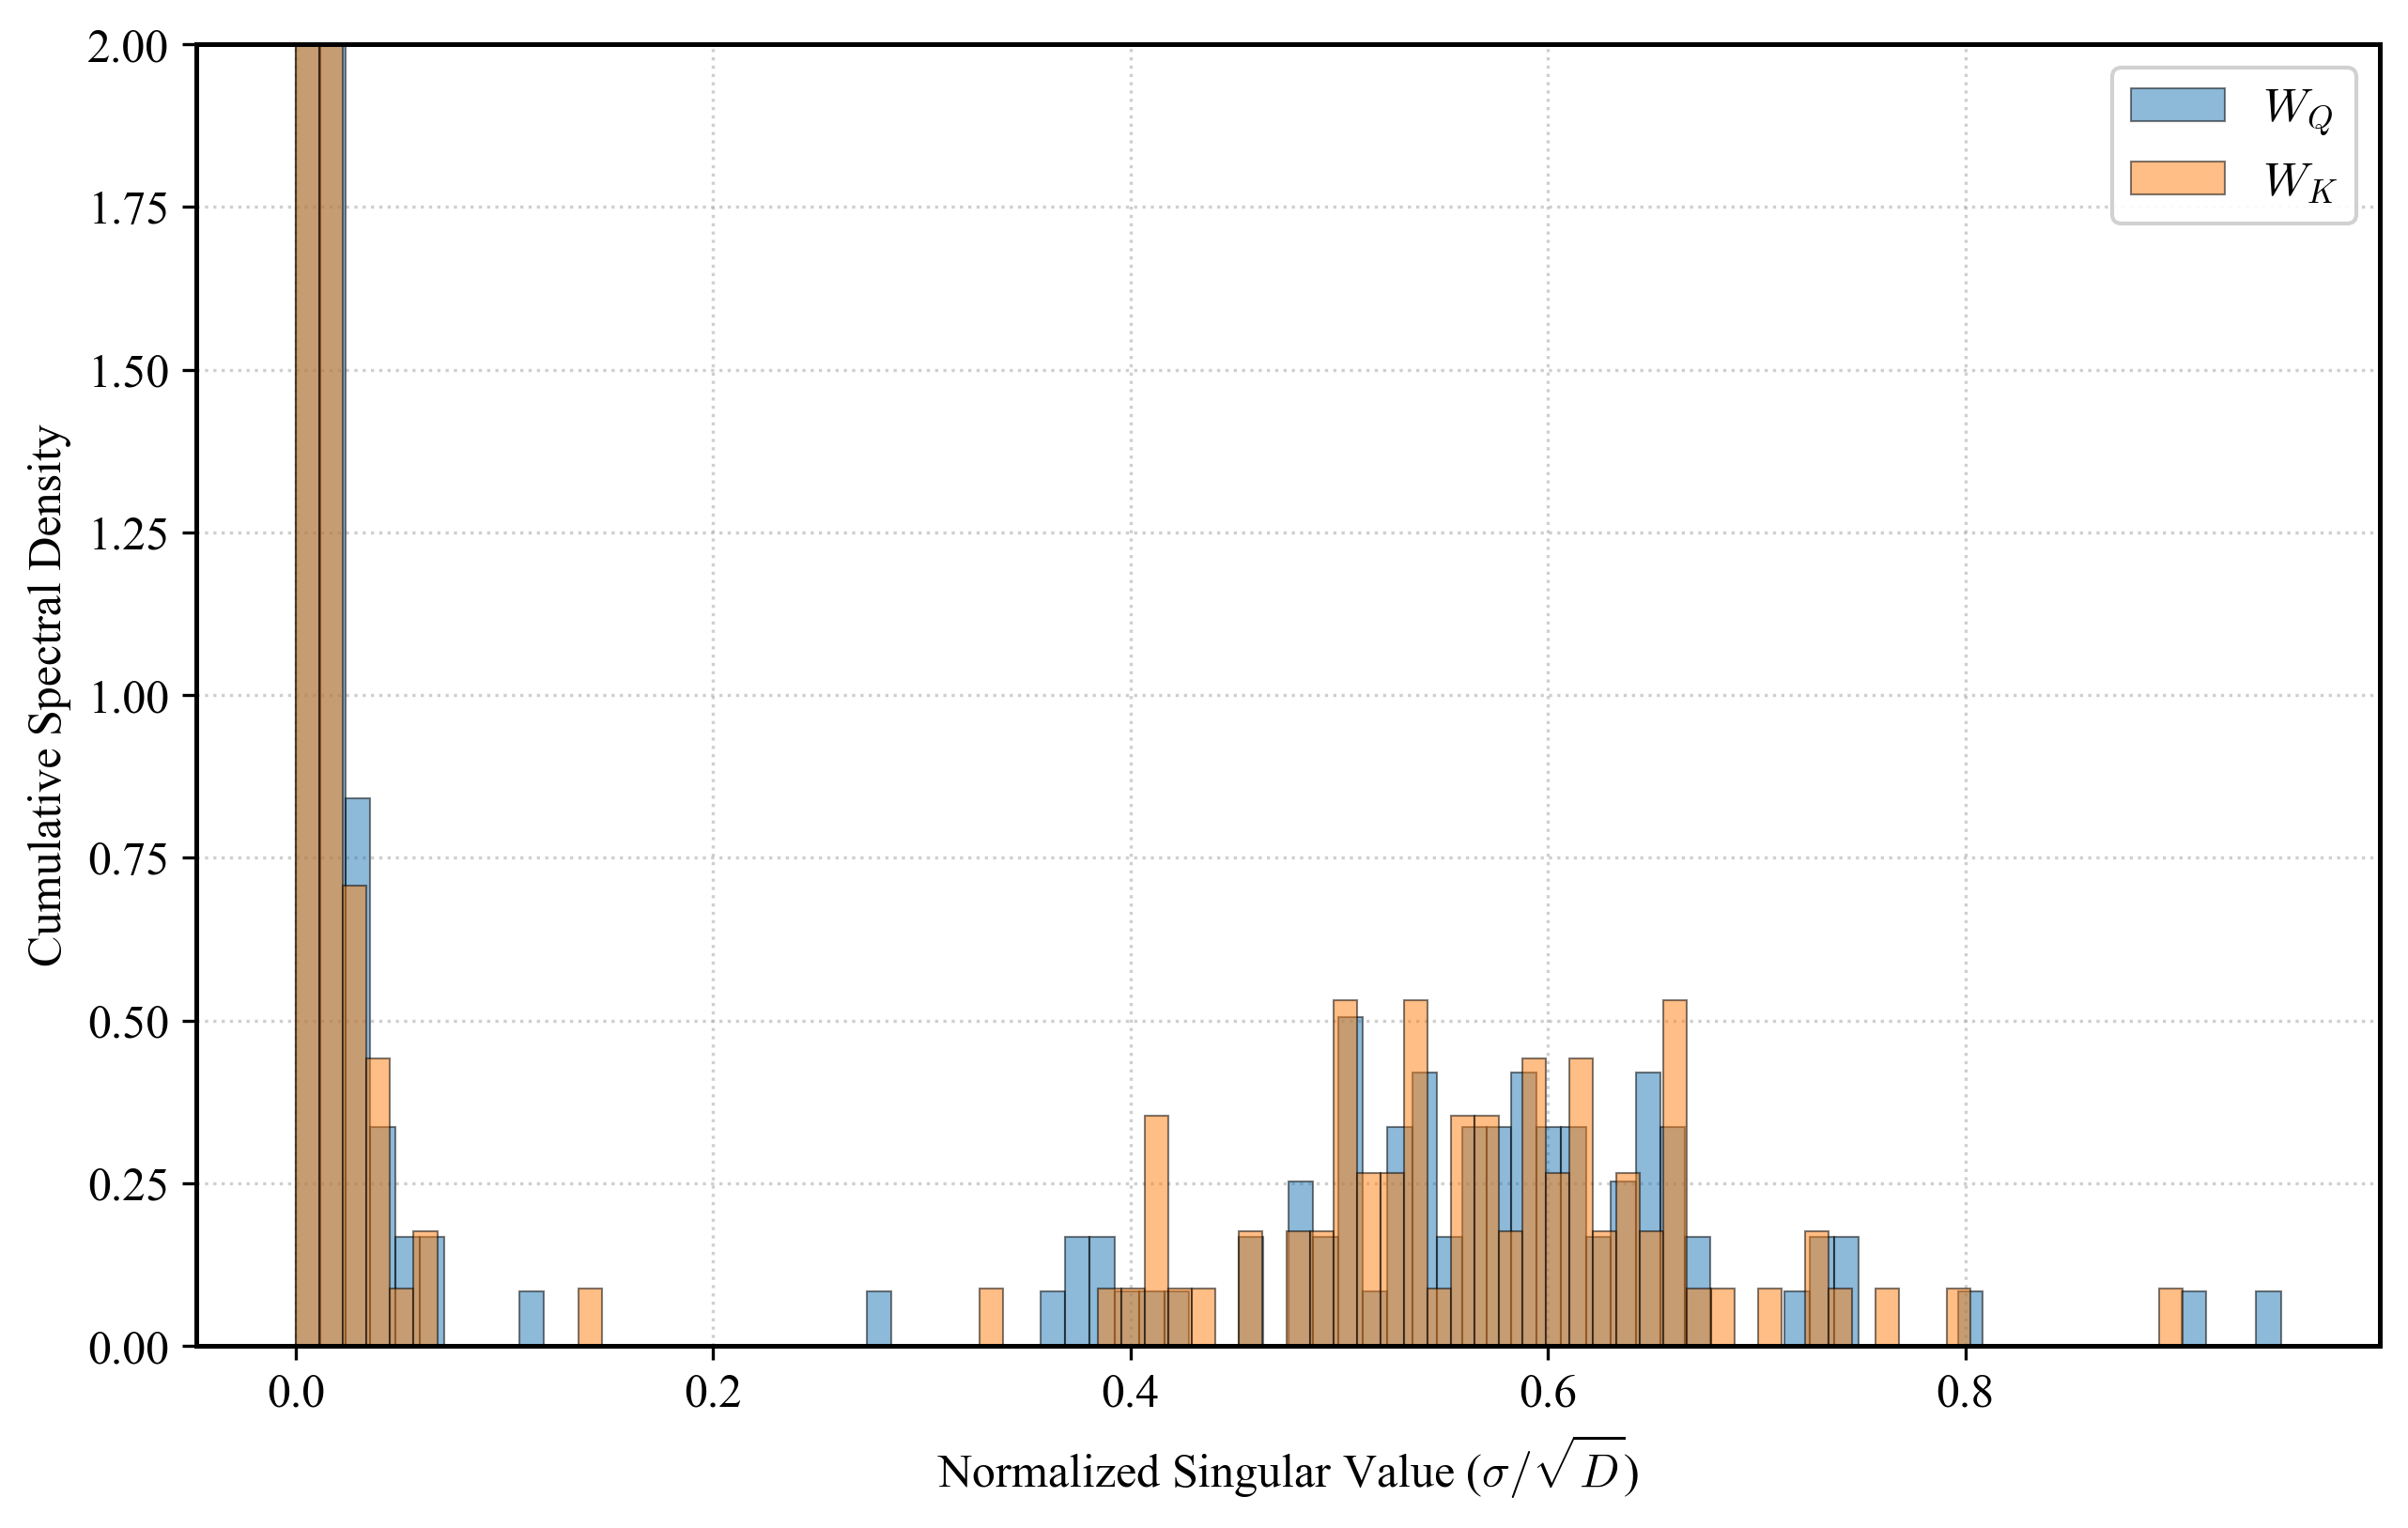

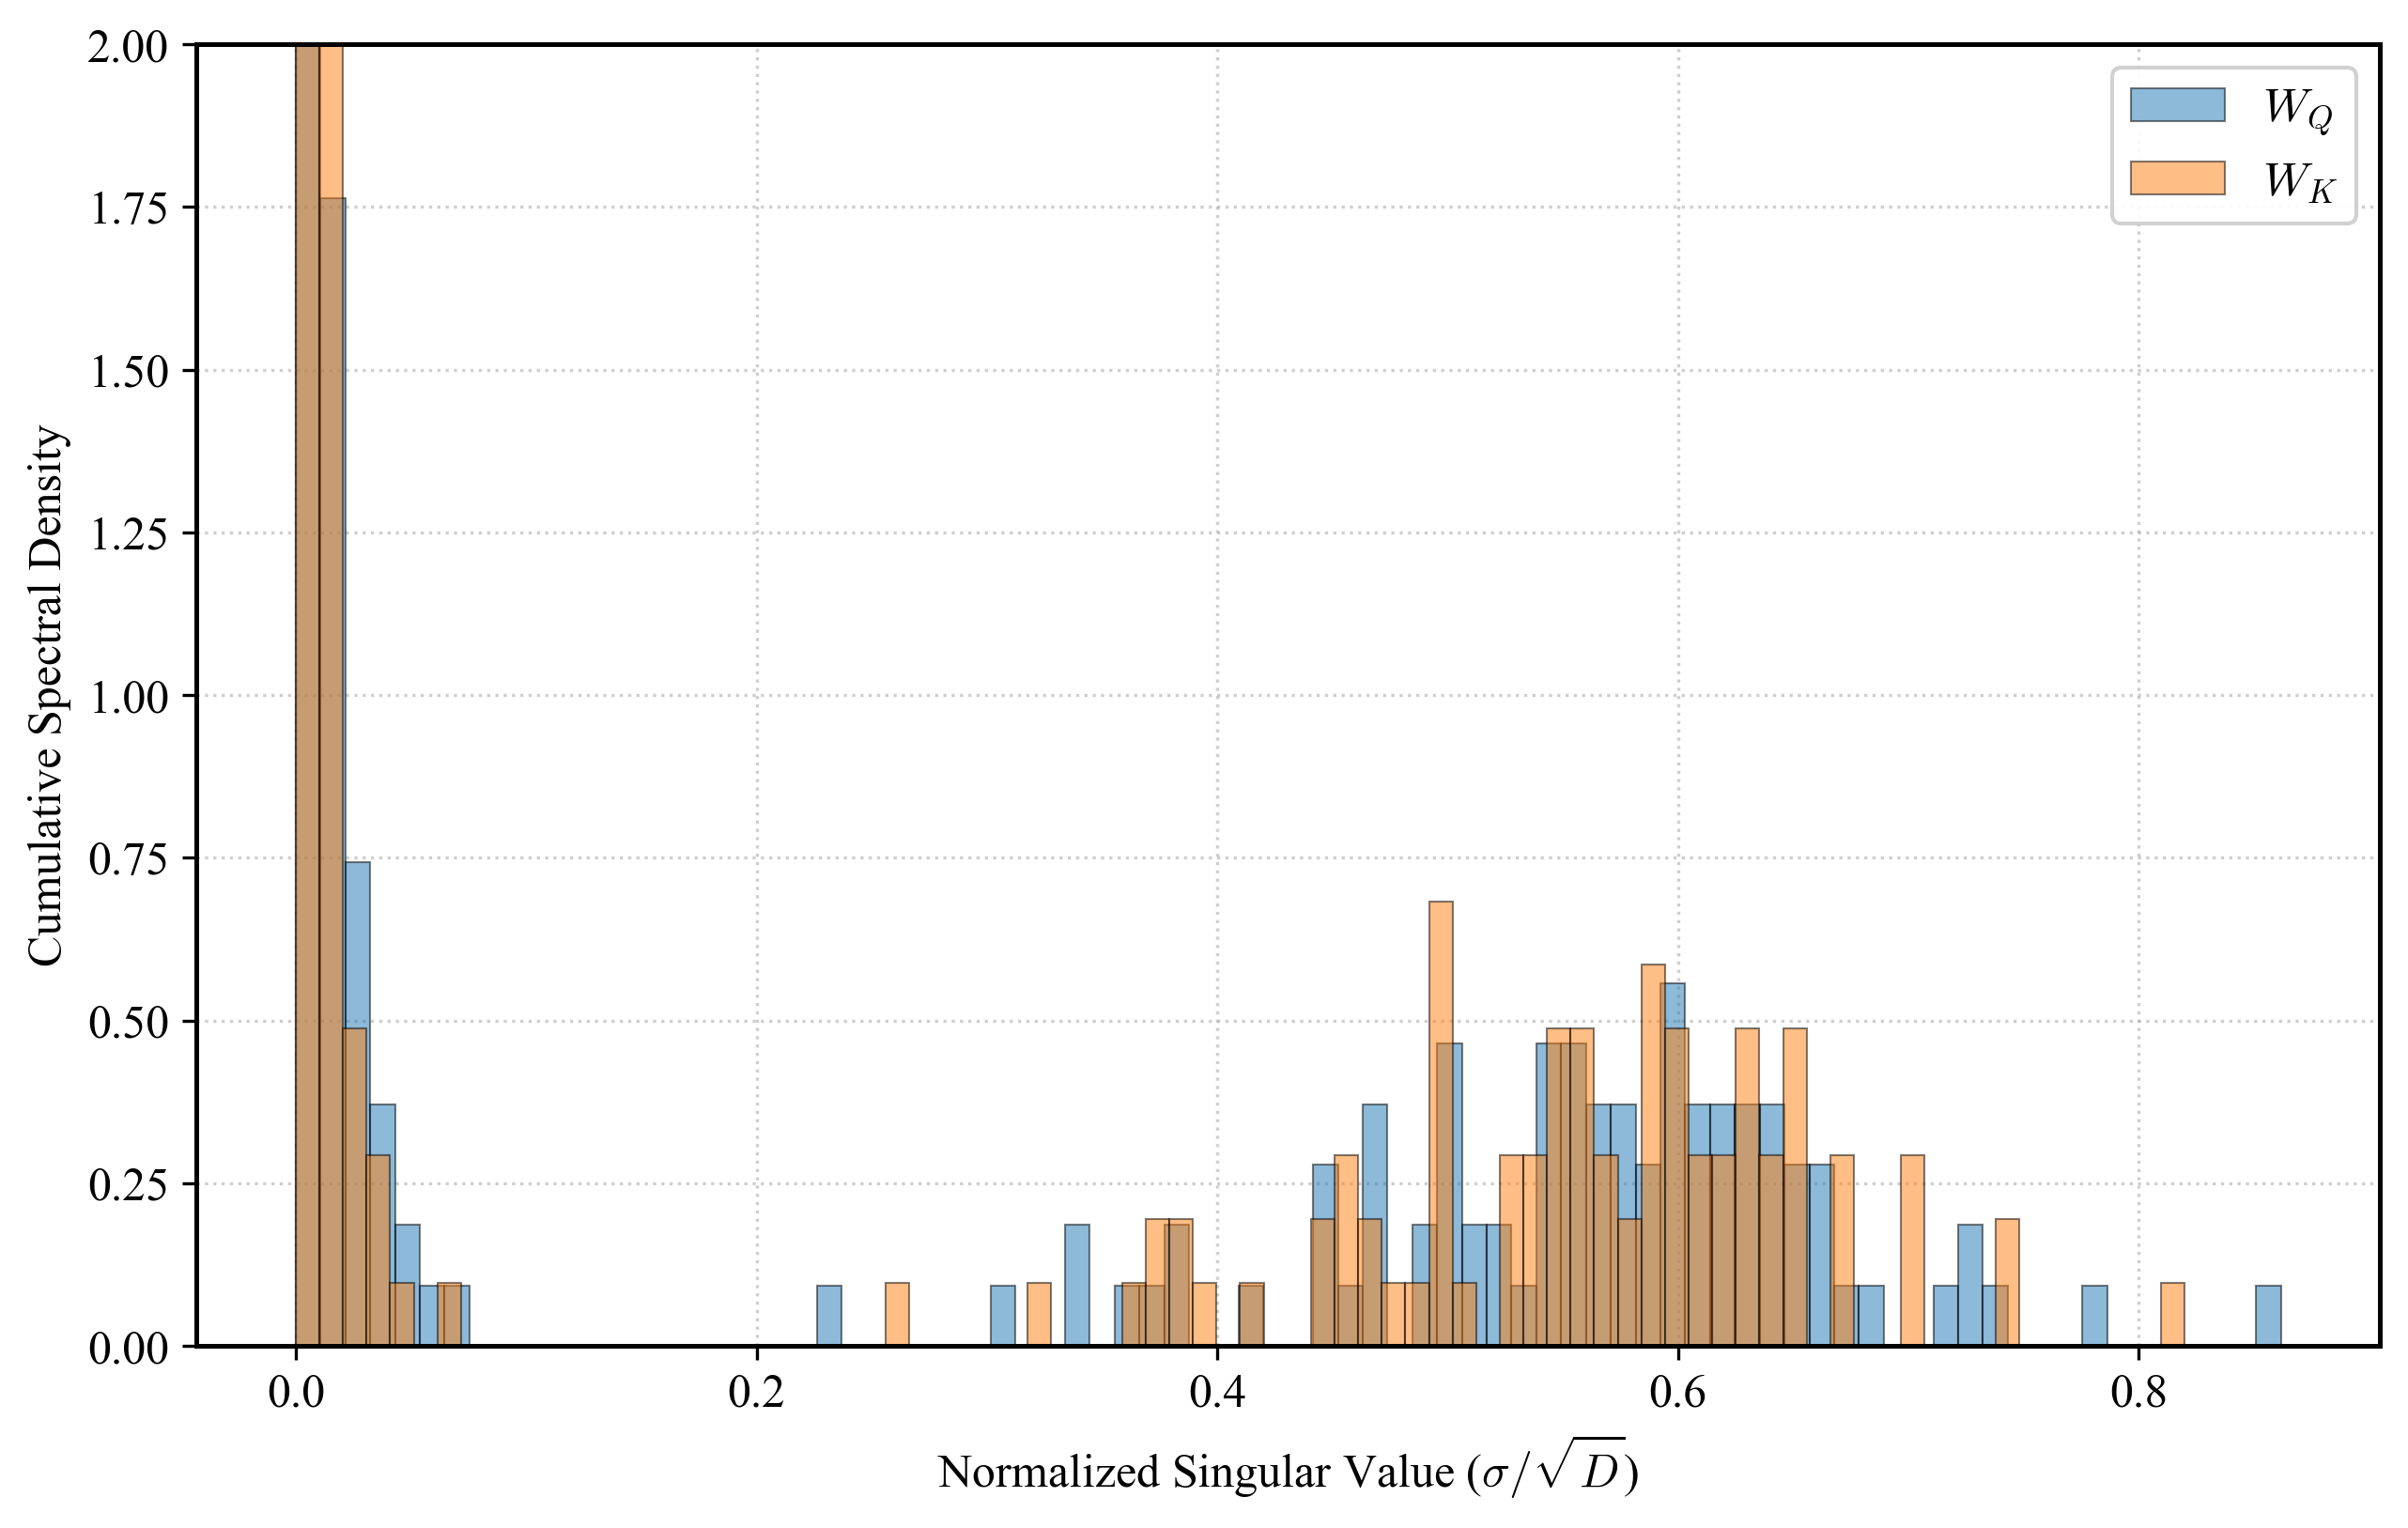

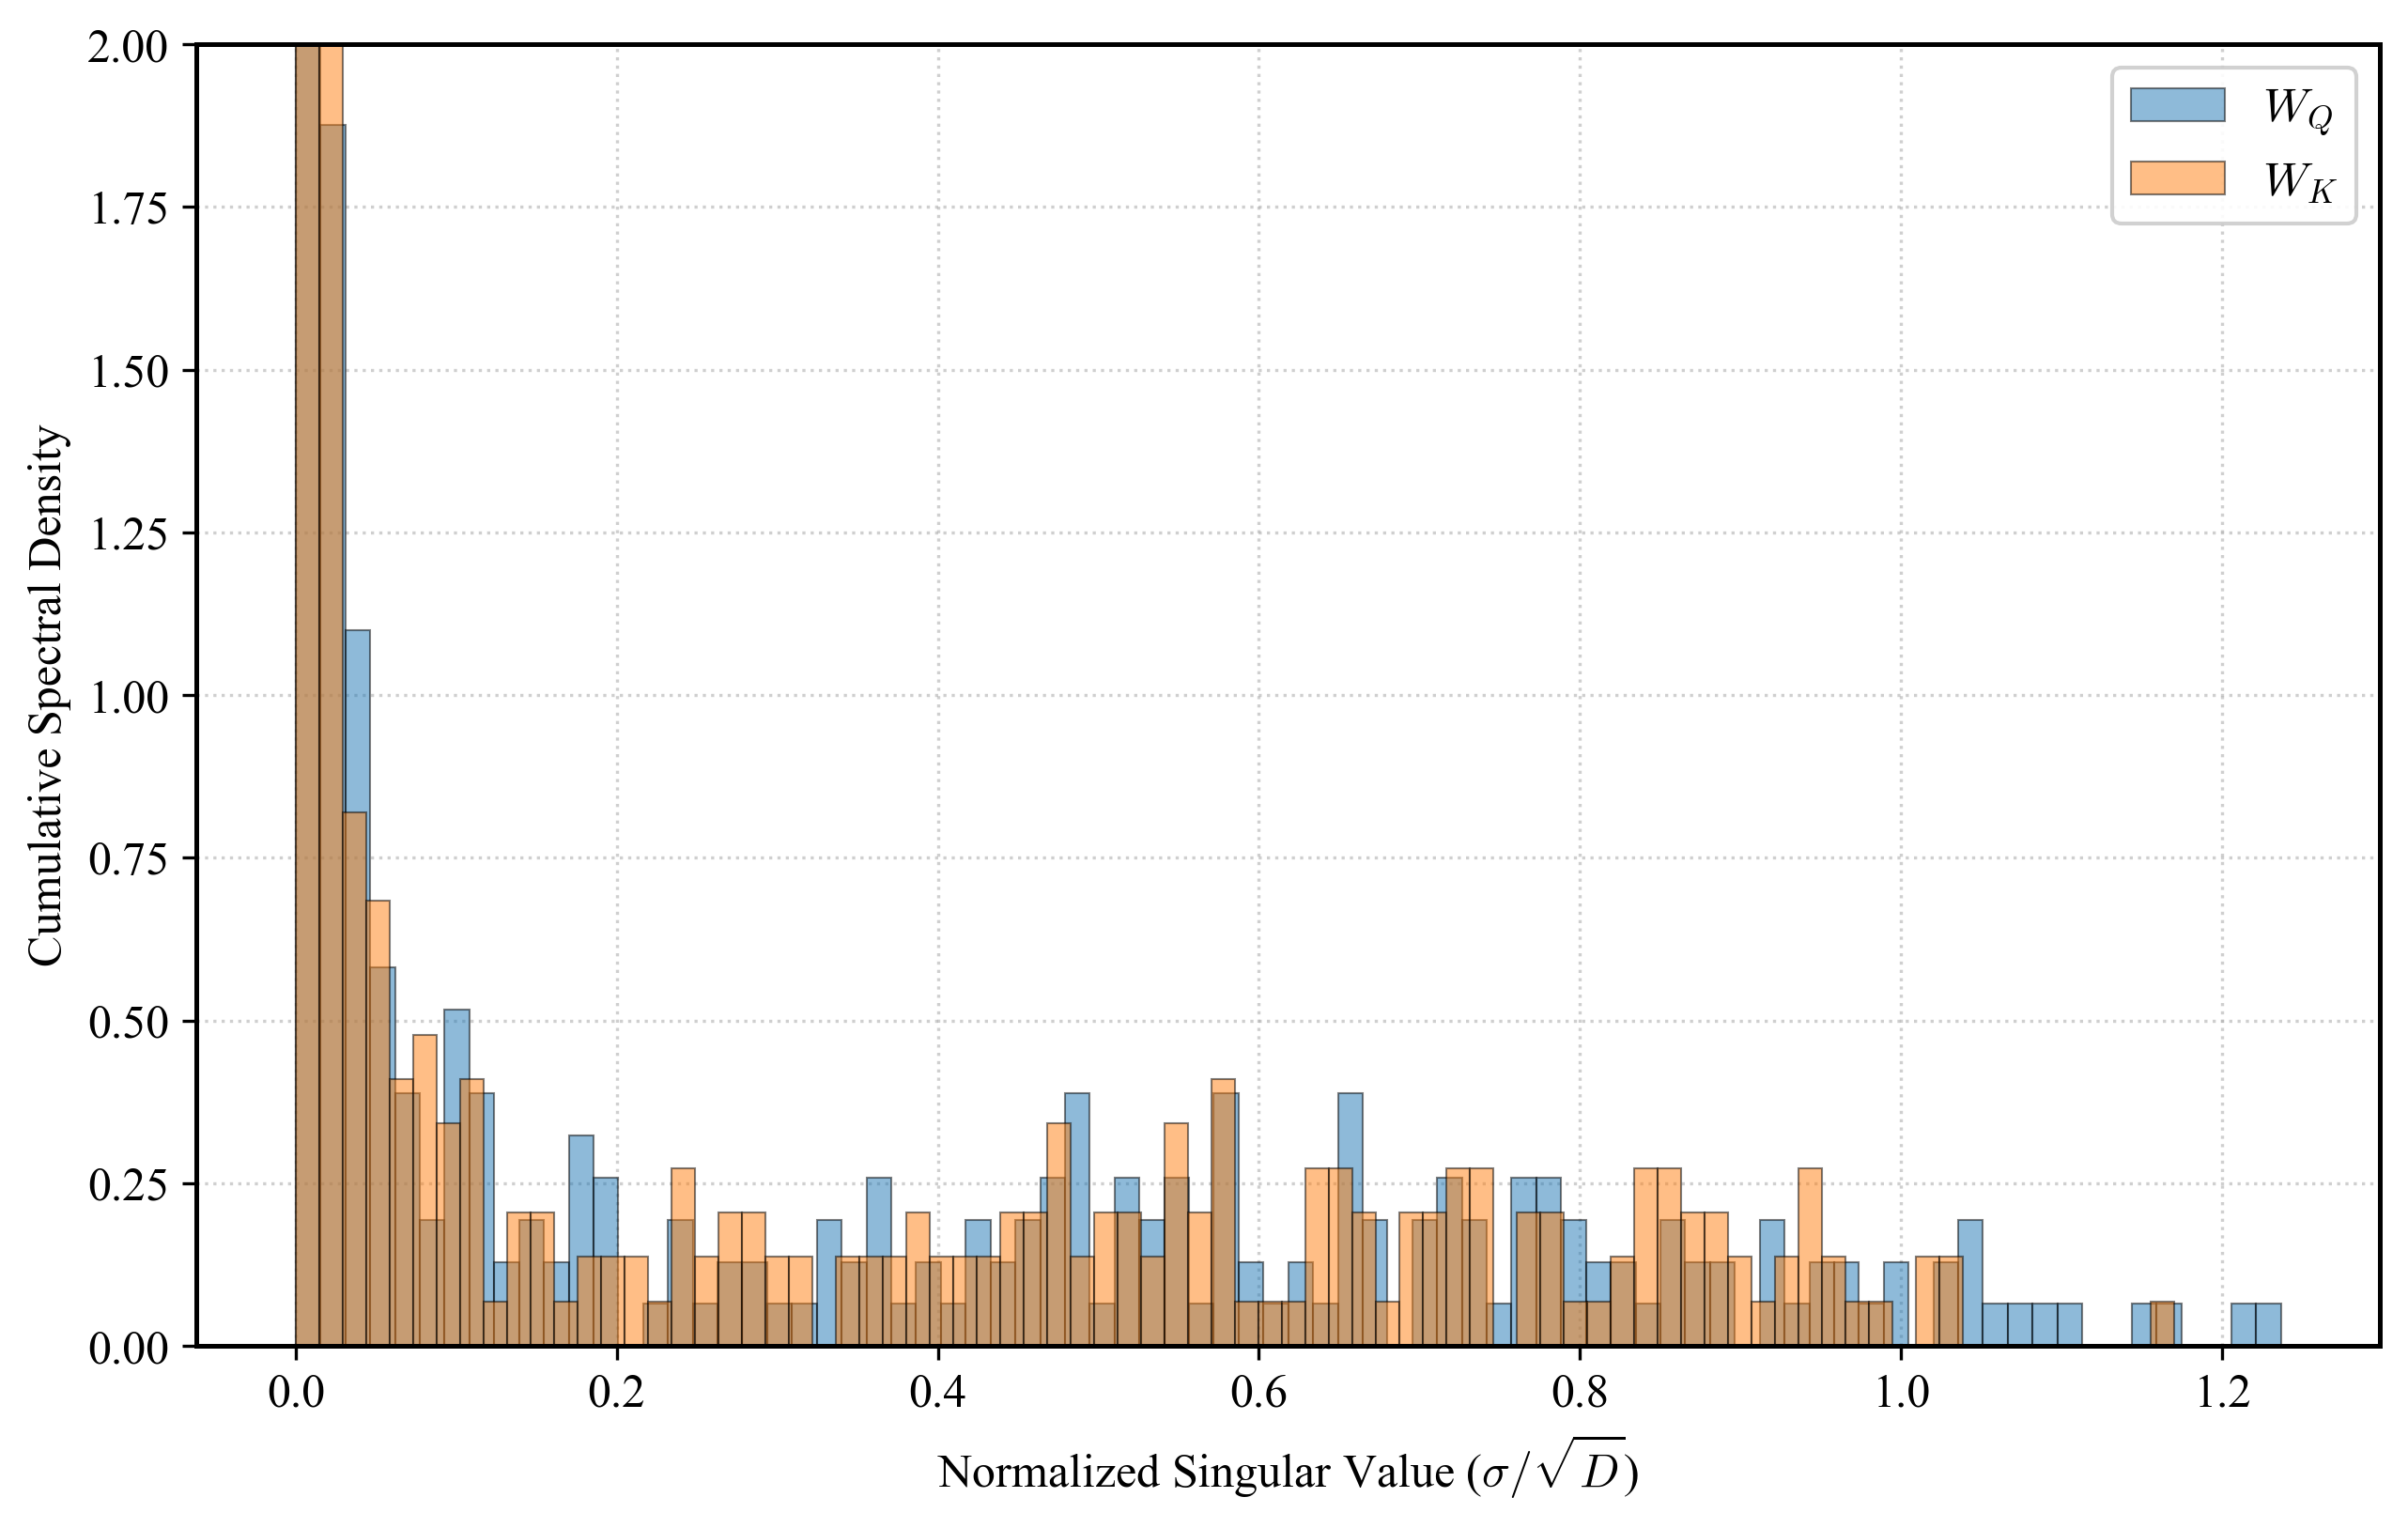

In [130]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt

def plot_svd_comparison(run_dir, bins_count=80):
    """
    Trace les histogrammes des valeurs singulières de W_Q et W_K sur le même plot.
    """
    # 1. Trouver les fichiers de données
    heavy_files = sorted(glob.glob(os.path.join(run_dir, "heavy_data_*.pkl")))
    print(f"✅ Found {len(heavy_files)} heavy_data files in {run_dir}\n")

    for heavy_file in heavy_files:
        filename = os.path.basename(heavy_file)
        print(f"Processing: {filename}...")

        try:
            with open(heavy_file, "rb") as f:
                data = pickle.load(f)

            # 2. Extraction sécurisée des listes de matrices
            W_Q_list = data.get("W_Q_runs", [])
            W_K_list = data.get("W_K_runs", [])

            # Si le format est ancien ou incomplet, on ignore
            if len(W_Q_list) == 0:
                print("   ⚠️ No W_Q data found. Skipping.\n")
                continue

            # 3. Fonction pour calculer et aplatir les valeurs singulières (SVD)
            def get_flat_svd(w_list):
                if not w_list: return None
                
                # On récupère la dimension D pour la normalisation (D = input_dim)
                # w.shape = (D, Hidden) ou (Hidden, D) selon l'implémentation
                # Généralement dans PyTorch Linear : (Out, In). 
                # Ta classe Net fait : self.W_Q = nn.Linear(input_dim, hidden_dim)
                # Donc weight shape = (hidden_dim, input_dim). D est la dimension 1.
                D = w_list[0].shape[0] 
                
                all_svd = []
                for W in w_list:
                    # compute_uv=False -> On veut juste les valeurs singulières (Sigma)
                    s = np.linalg.svd(W, compute_uv=False)
                    all_svd.append(s)
                
                # Concaténation et Normalisation standard (1/sqrt(D))
                return np.concatenate(all_svd) / np.sqrt(D)

            flat_Q = get_flat_svd(W_Q_list)
            flat_K = get_flat_svd(W_K_list)

            # 4. PLOTTING
            fig, ax = plt.subplots(figsize=(10, 6))

            # --- Histogramme W_Q (Bleu) ---
            if flat_Q is not None:
                mu_q = np.mean(flat_Q)
                ax.hist(
                    flat_Q,
                    bins=bins_count,
                    density=True,      # Densité de probabilité
                    alpha=0.5,         # Transparence pour voir ce qu'il y a derrière
                    color='#1f77b4',   # Bleu standard
                    label=fr"$W_Q$",
                    edgecolor='black',
                    linewidth=0.5
                )

            # --- Histogramme W_K (Orange) ---
            if flat_K is not None:
                mu_k = np.mean(flat_K)
                ax.hist(
                    flat_K,
                    bins=bins_count,
                    density=True,
                    alpha=0.5,         # Transparence
                    color='#ff7f0e',   # Orange standard
                    label=fr"$W_K$",
                    edgecolor='black',
                    linewidth=0.5
                )

            # Décoration du graphique
            ax.set_xlabel(r"Normalized Singular Value ($\sigma / \sqrt{D}$)", fontsize=12)
            ax.set_ylabel("Cumulative Spectral Density", fontsize=12)
            # ax.set_title(f"SVD Distribution Comparison: {filename}", fontsize=10)
            ax.set_ylim([0,2])
            
            # Grille et cadre style "Publication"
            ax.set_axisbelow(True)
            ax.grid(True, linestyle=':', alpha=0.6)
            for spine in ax.spines.values():
                spine.set_linewidth(1.2)

            # Légende
            ax.legend(fontsize=12, loc='upper right', frameon=True, framealpha=0.9)

            # Sauvegarde
            out_filename = f"SVD_Compare_{filename.replace('.pkl', '.png')}"
            out_path = os.path.join(plot_path, out_filename)
            plt.savefig(out_path, dpi=300, bbox_inches='tight')
            print(f"   📊 Plot saved: {out_path}\n")

        except Exception as e:
            print(f"   ❌ Error on {filename}: {e}\n")

# --- Exemple d'utilisation ---
plot_svd_comparison(run_dir)

Found 15 attention files and 15 preds files
Les images seront sauvegardées dans : ../results/run_20251218_1108/plots
Processing file: attn_0.pkl
✅ Saved plot: ../results/run_20251218_1108/plots/attn_0_run3.png


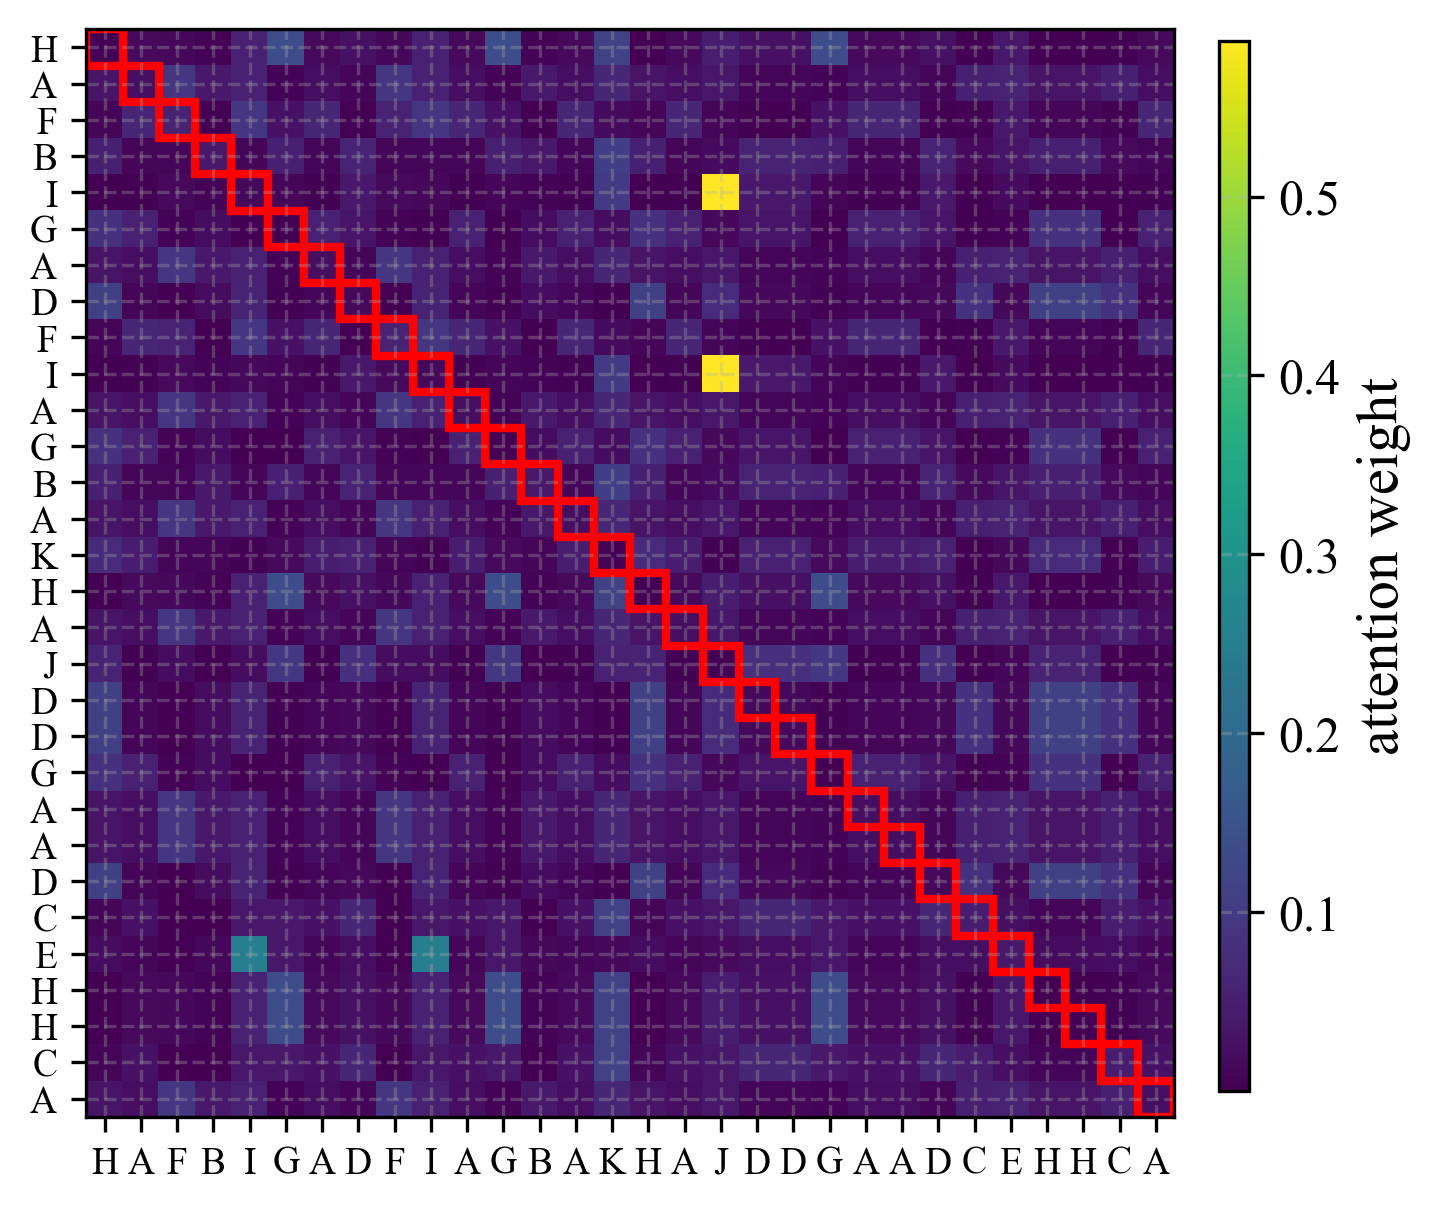

Processing file: attn_1.pkl
✅ Saved plot: ../results/run_20251218_1108/plots/attn_1_run3.png


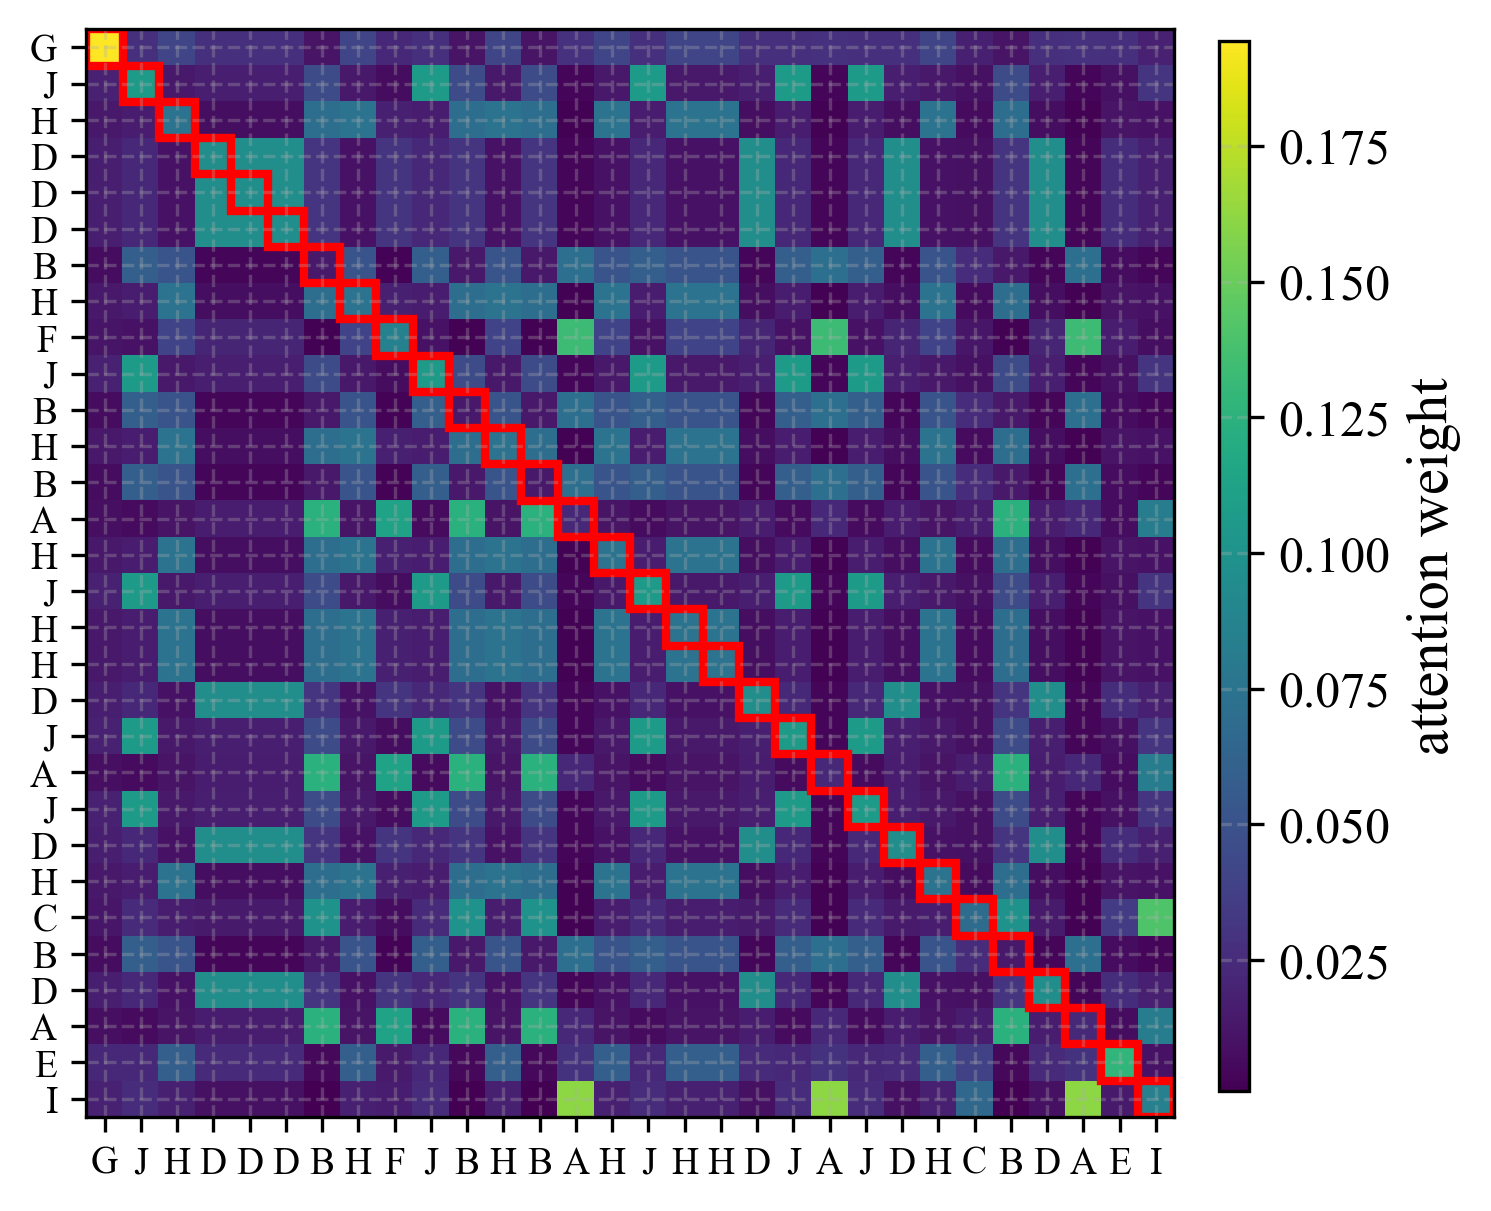

Processing file: attn_10.pkl
✅ Saved plot: ../results/run_20251218_1108/plots/attn_10_run3.png


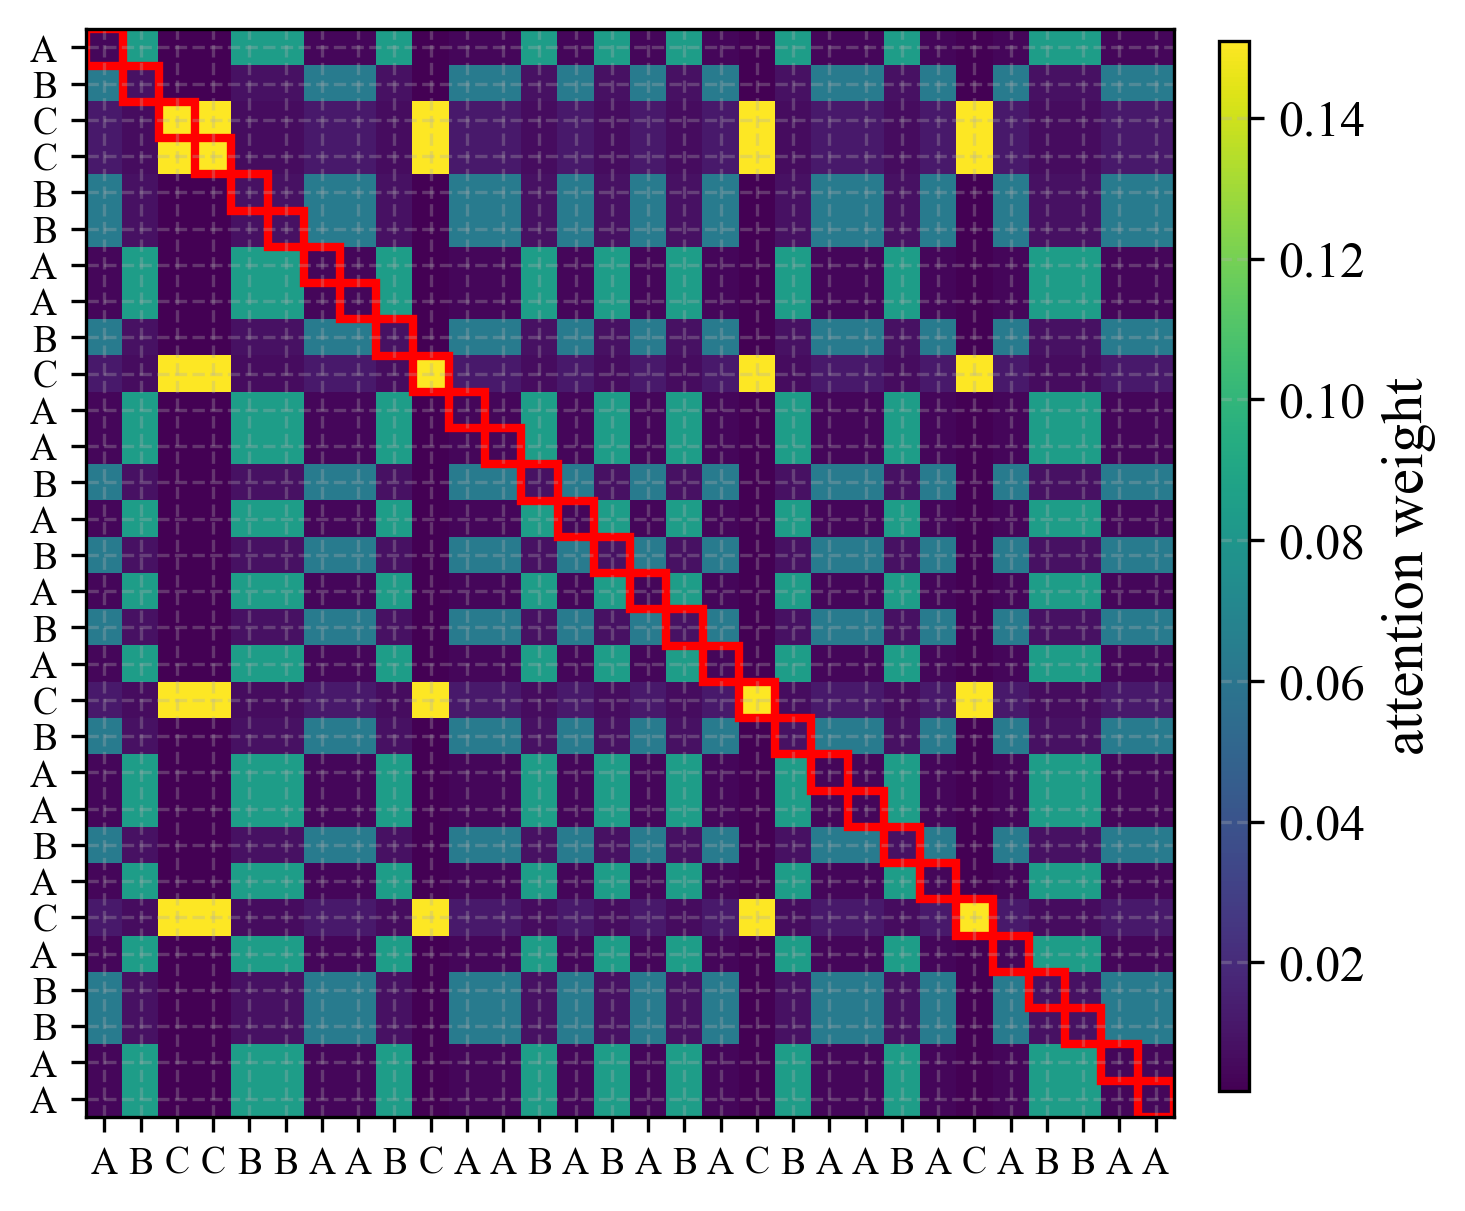

Processing file: attn_11.pkl
✅ Saved plot: ../results/run_20251218_1108/plots/attn_11_run3.png


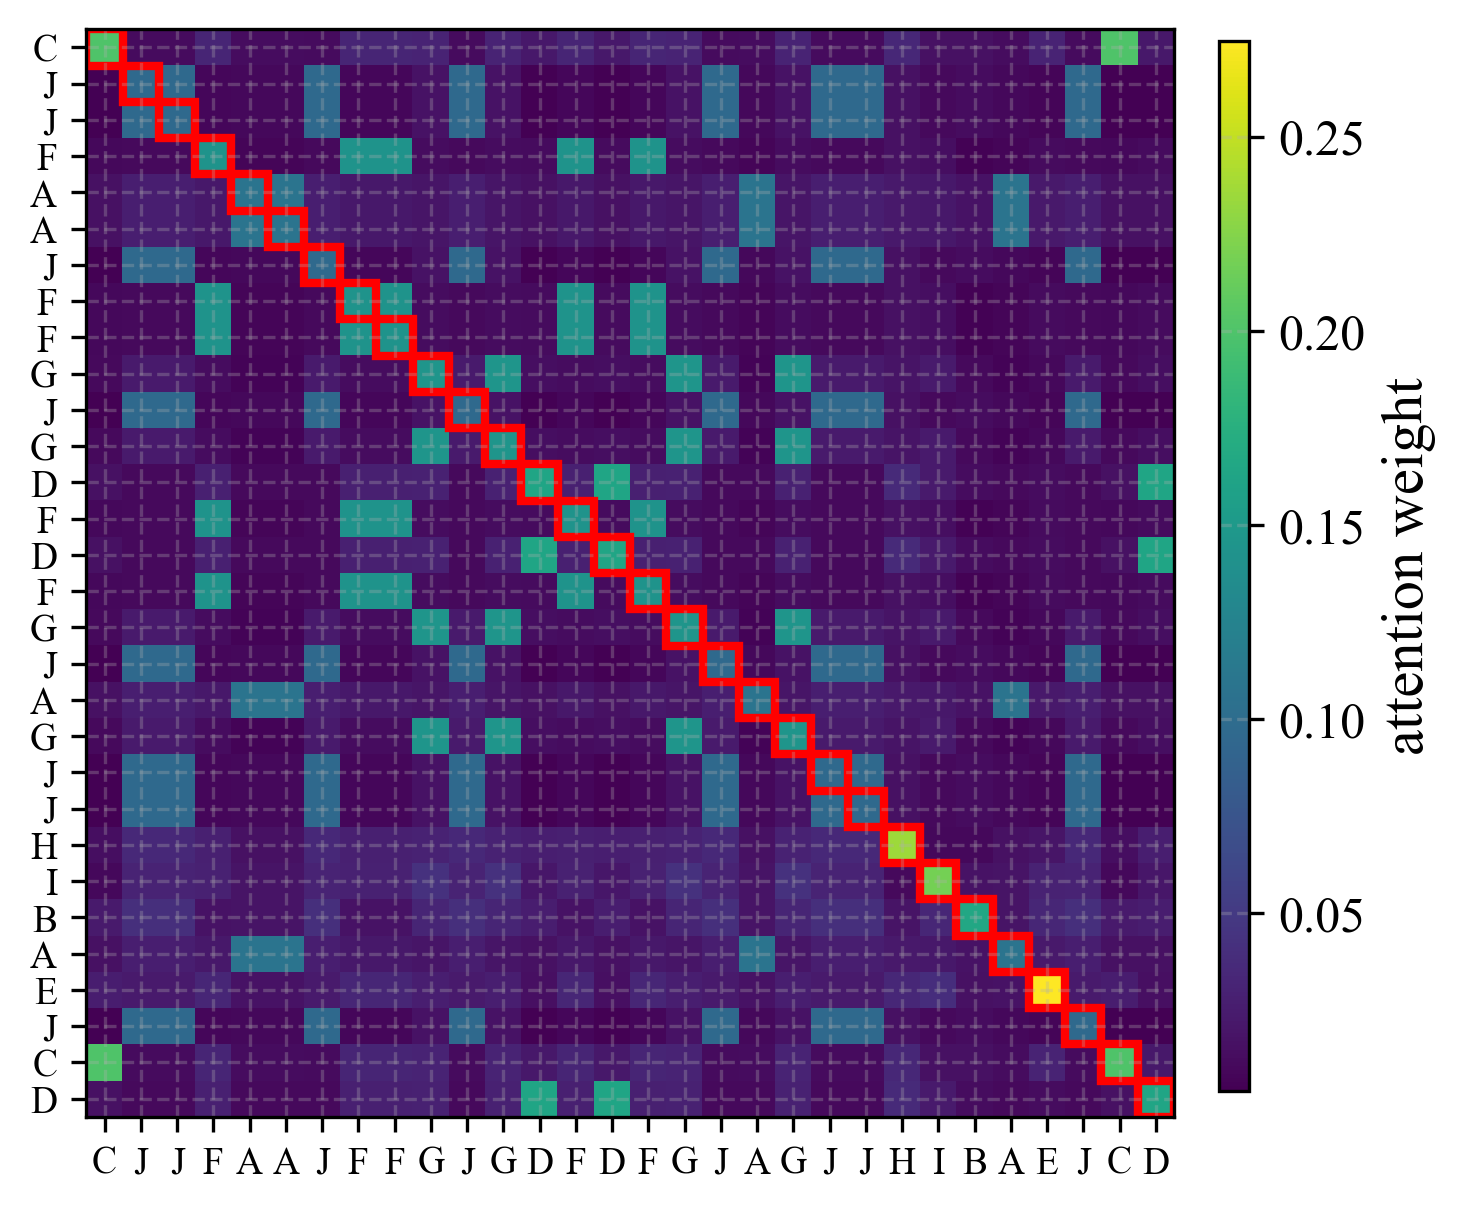

Processing file: attn_12.pkl
✅ Saved plot: ../results/run_20251218_1108/plots/attn_12_run3.png


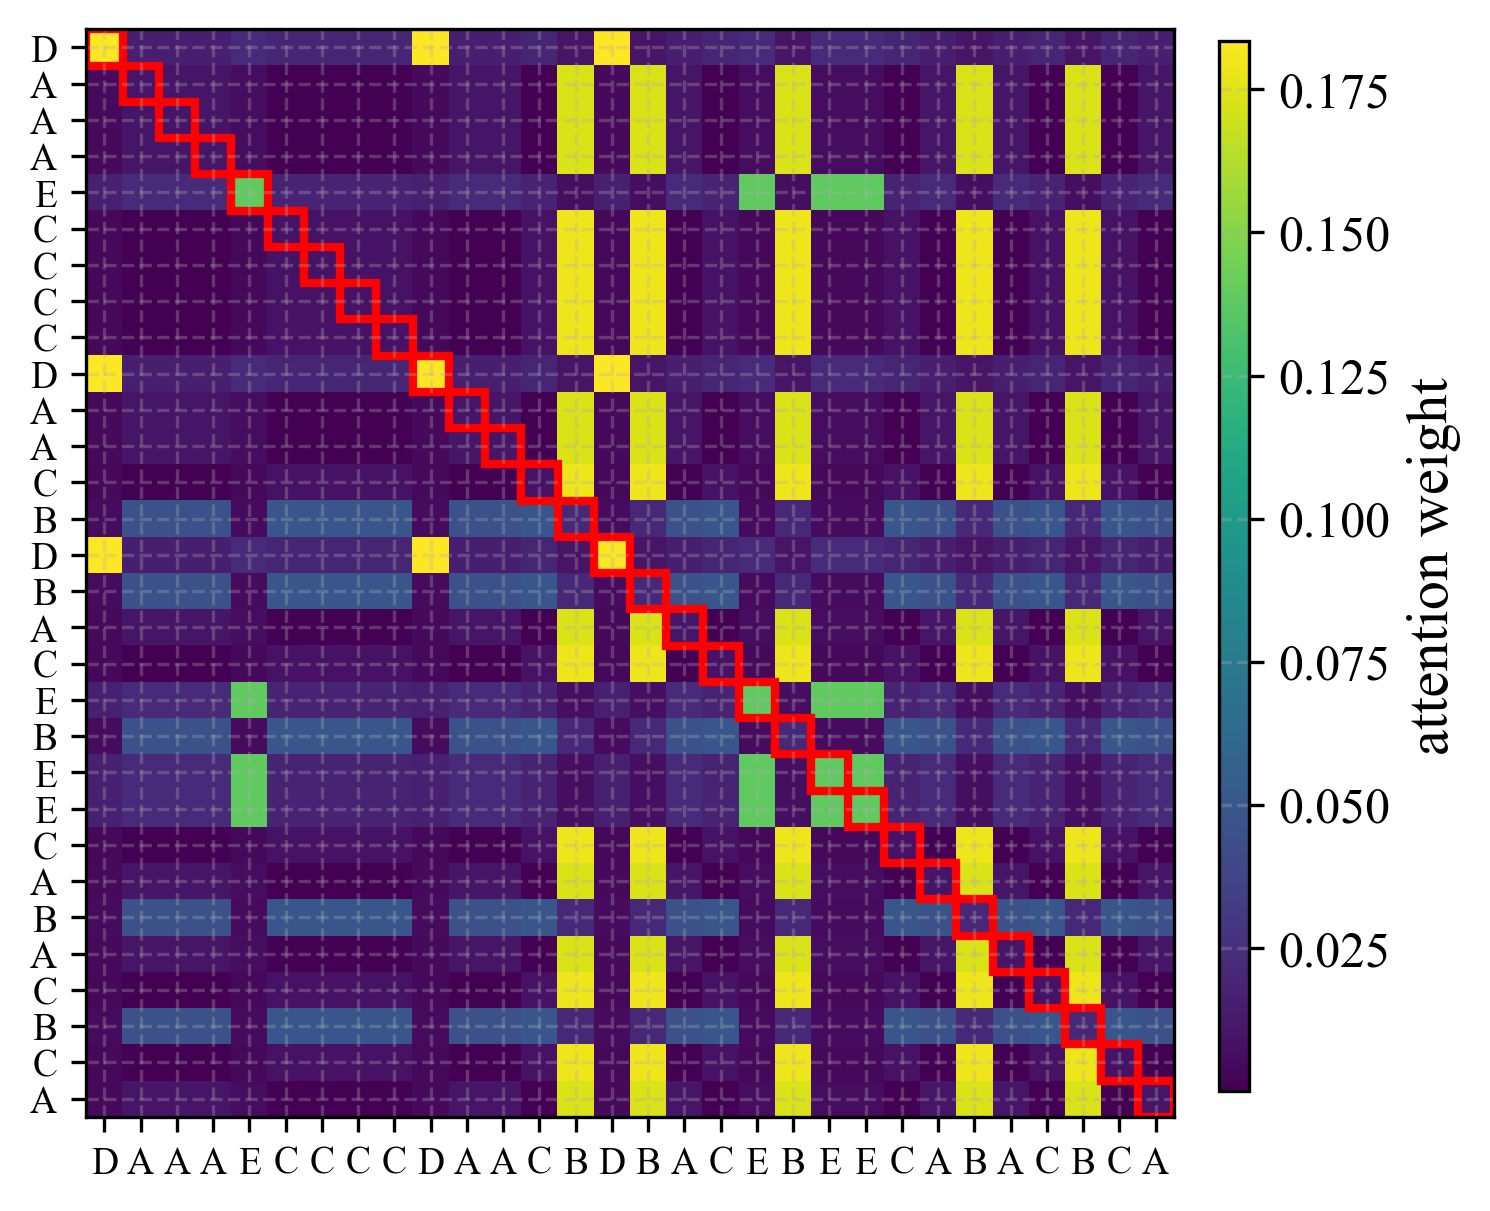

Processing file: attn_13.pkl
✅ Saved plot: ../results/run_20251218_1108/plots/attn_13_run3.png


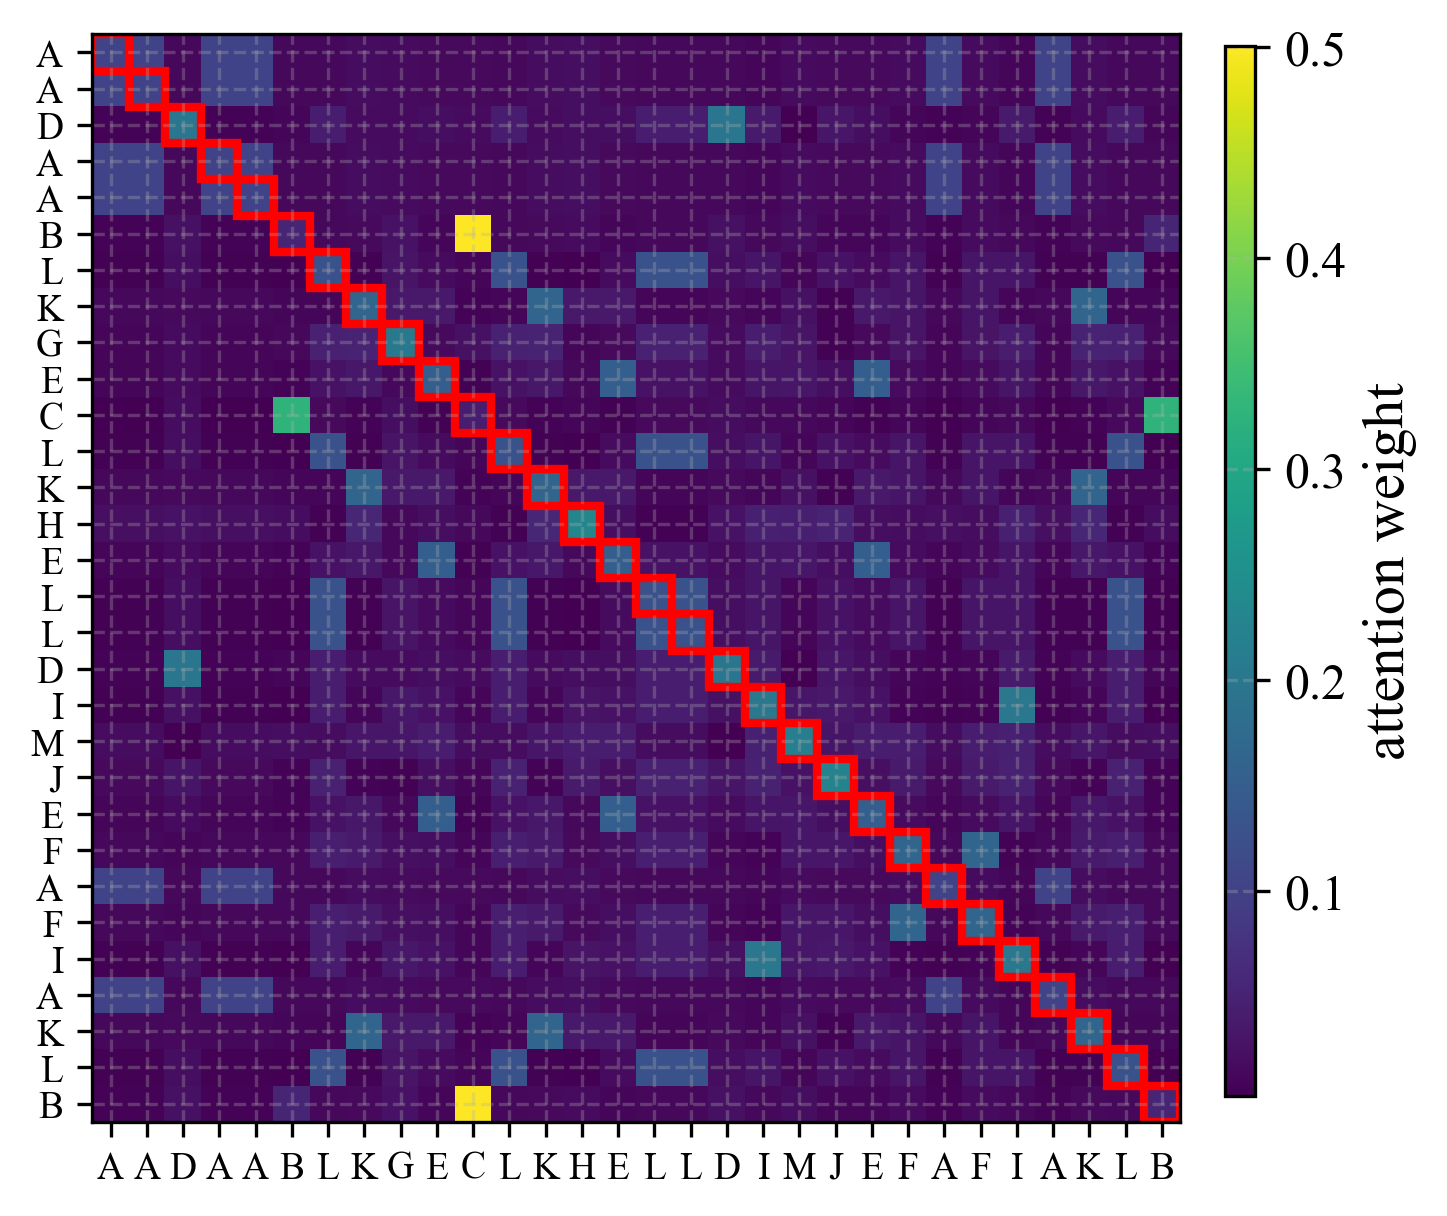

Processing file: attn_14.pkl
✅ Saved plot: ../results/run_20251218_1108/plots/attn_14_run3.png


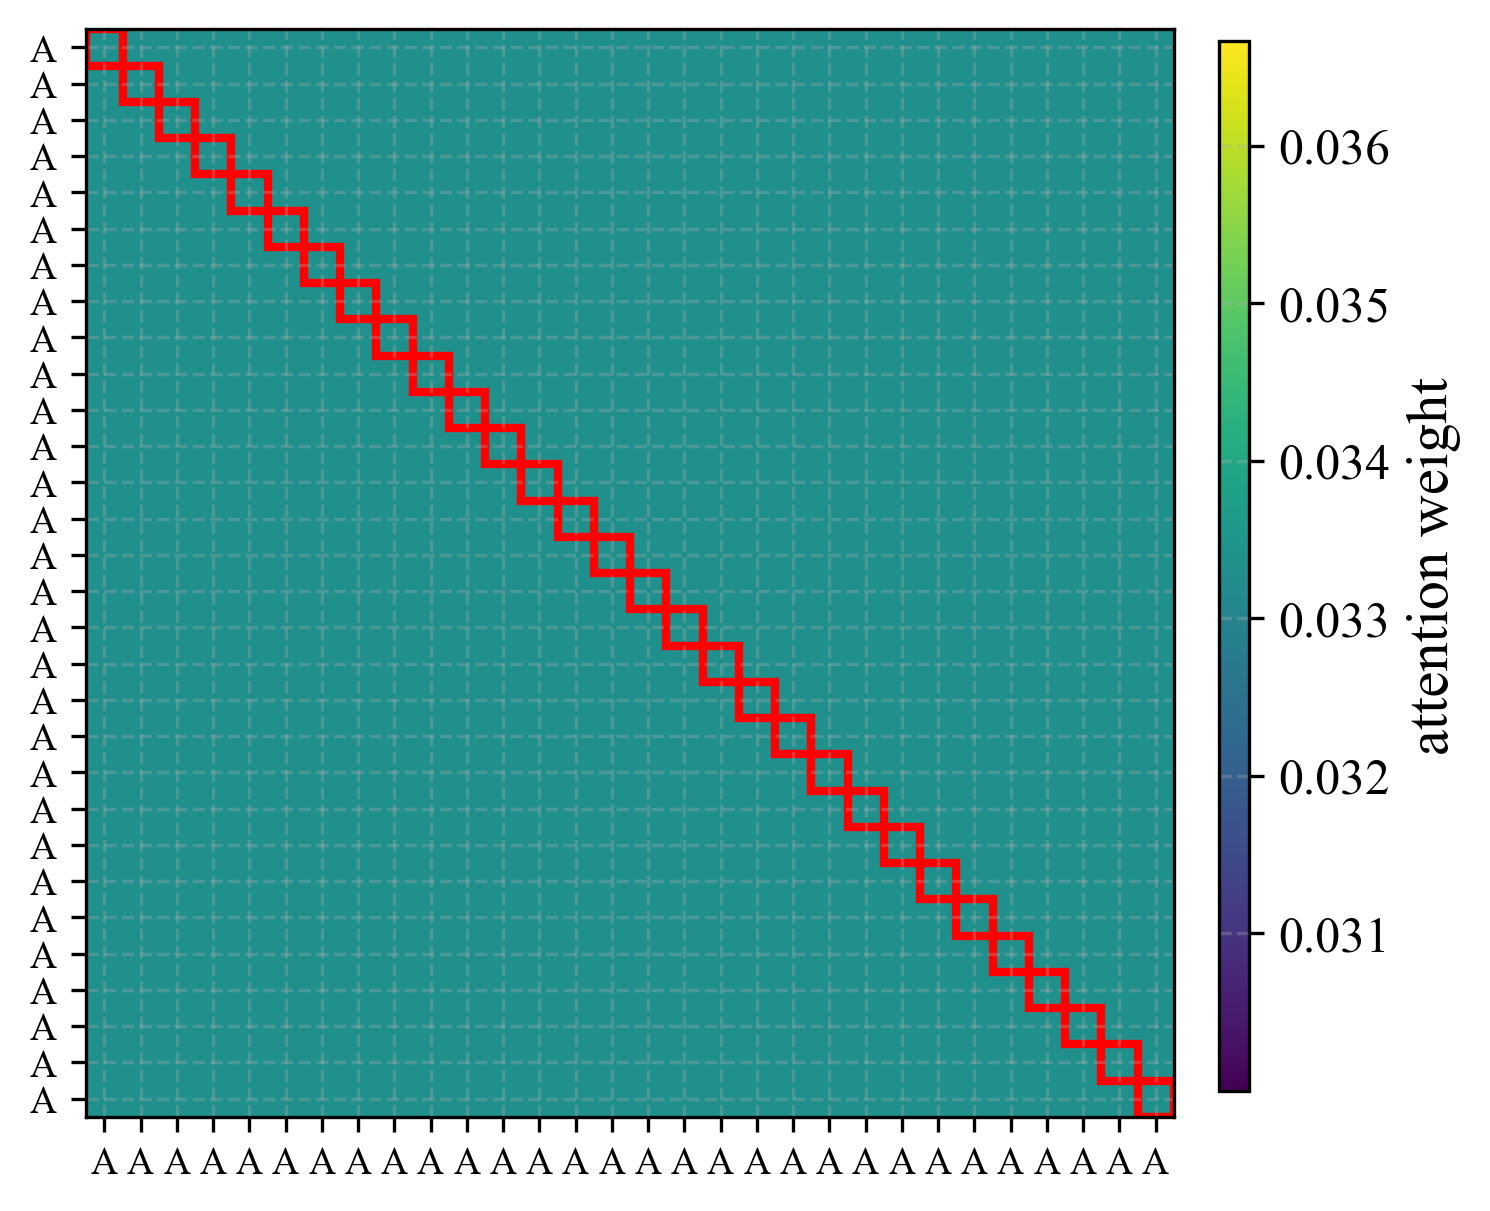

Processing file: attn_2.pkl
✅ Saved plot: ../results/run_20251218_1108/plots/attn_2_run3.png


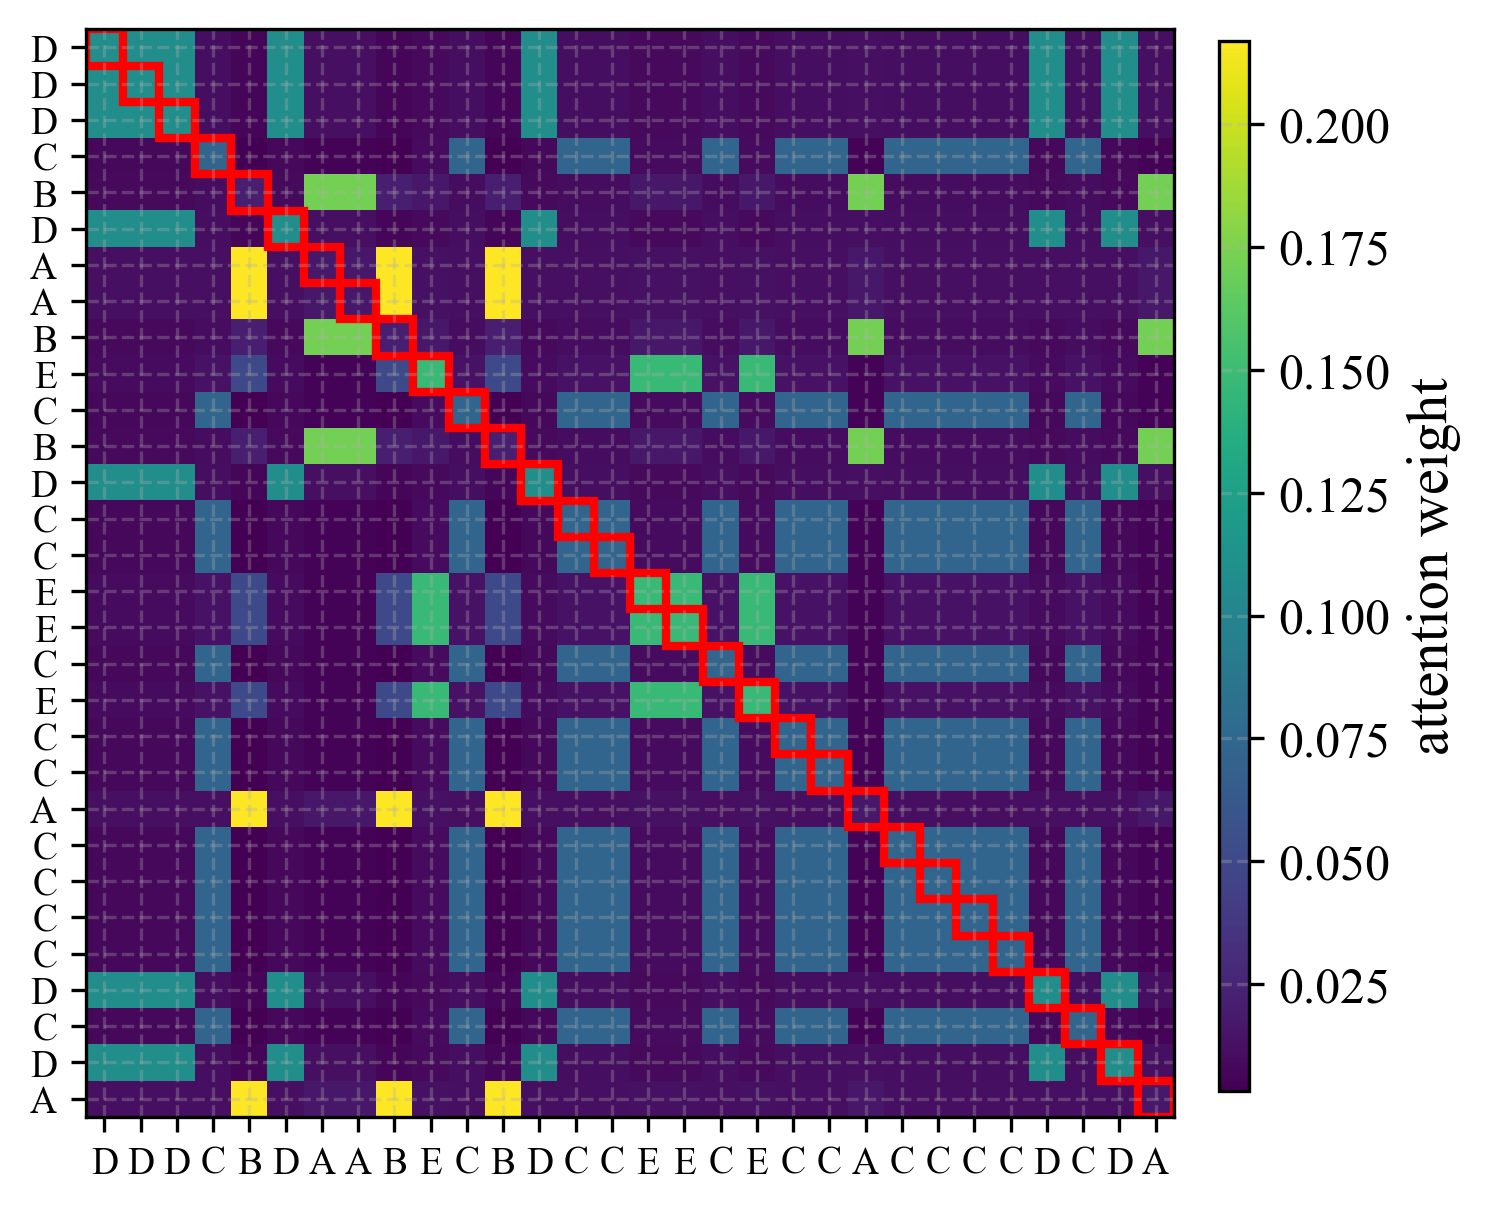

Processing file: attn_3.pkl
✅ Saved plot: ../results/run_20251218_1108/plots/attn_3_run3.png


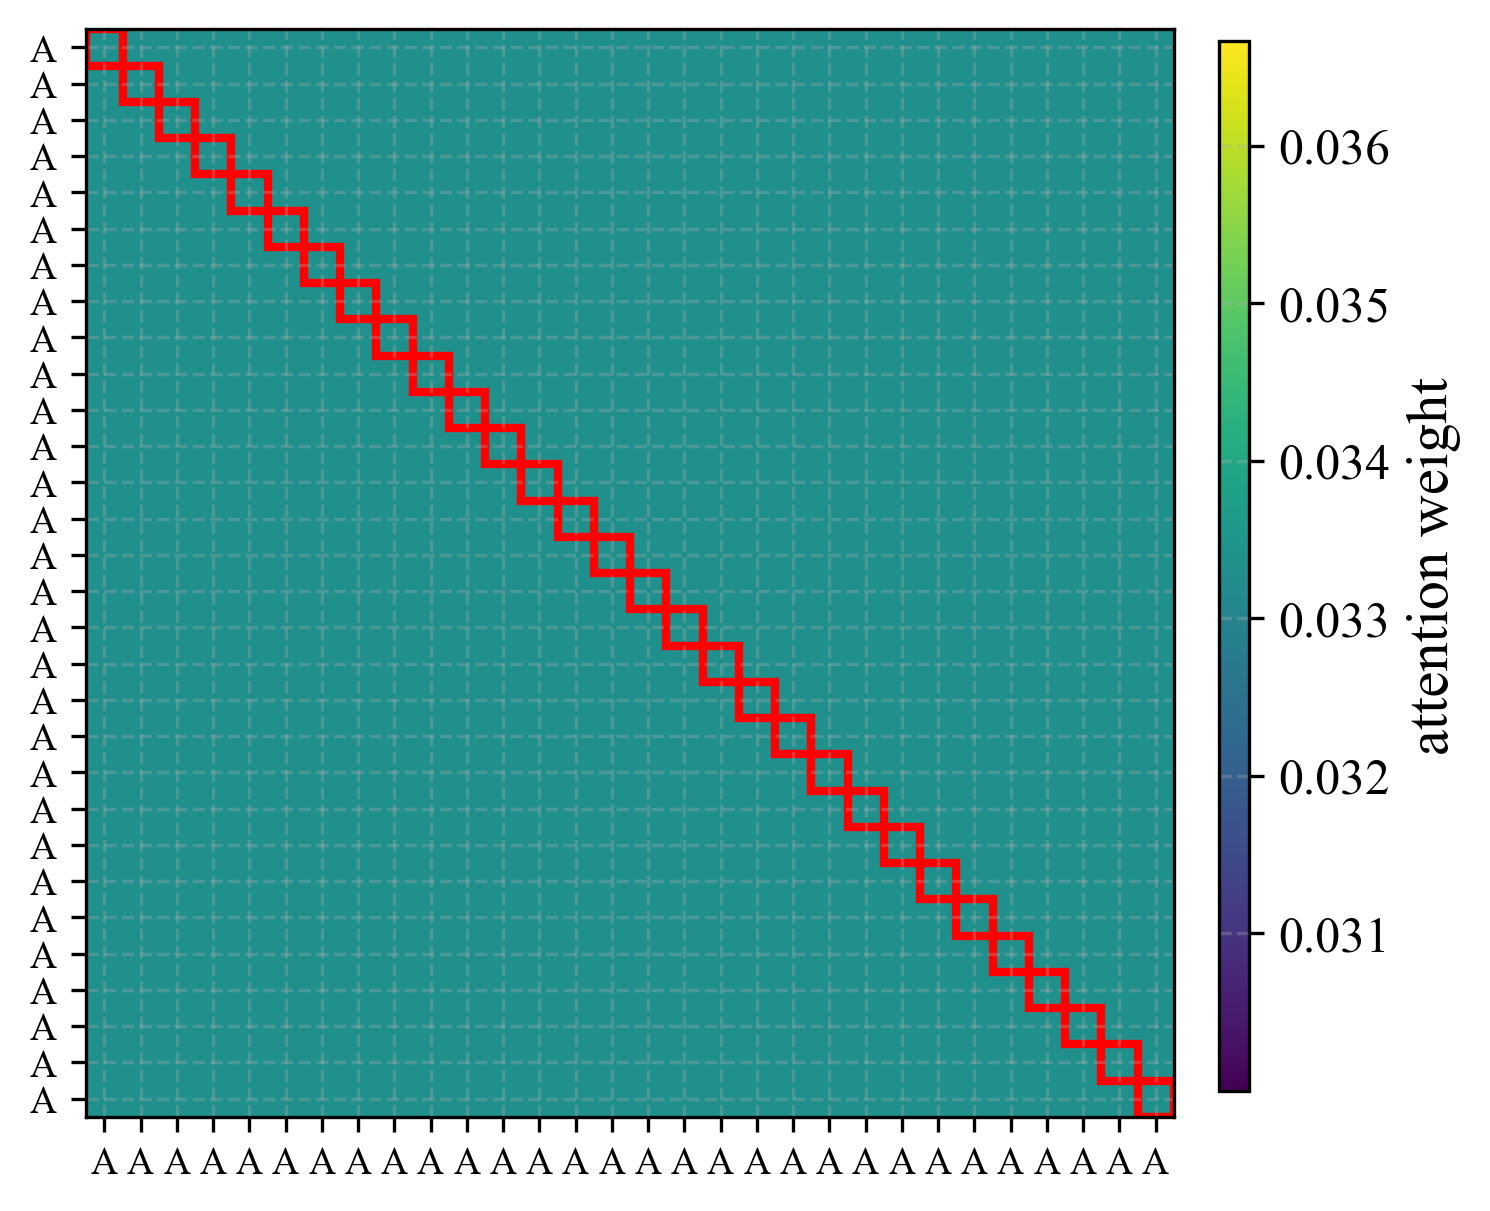

Processing file: attn_4.pkl
✅ Saved plot: ../results/run_20251218_1108/plots/attn_4_run3.png


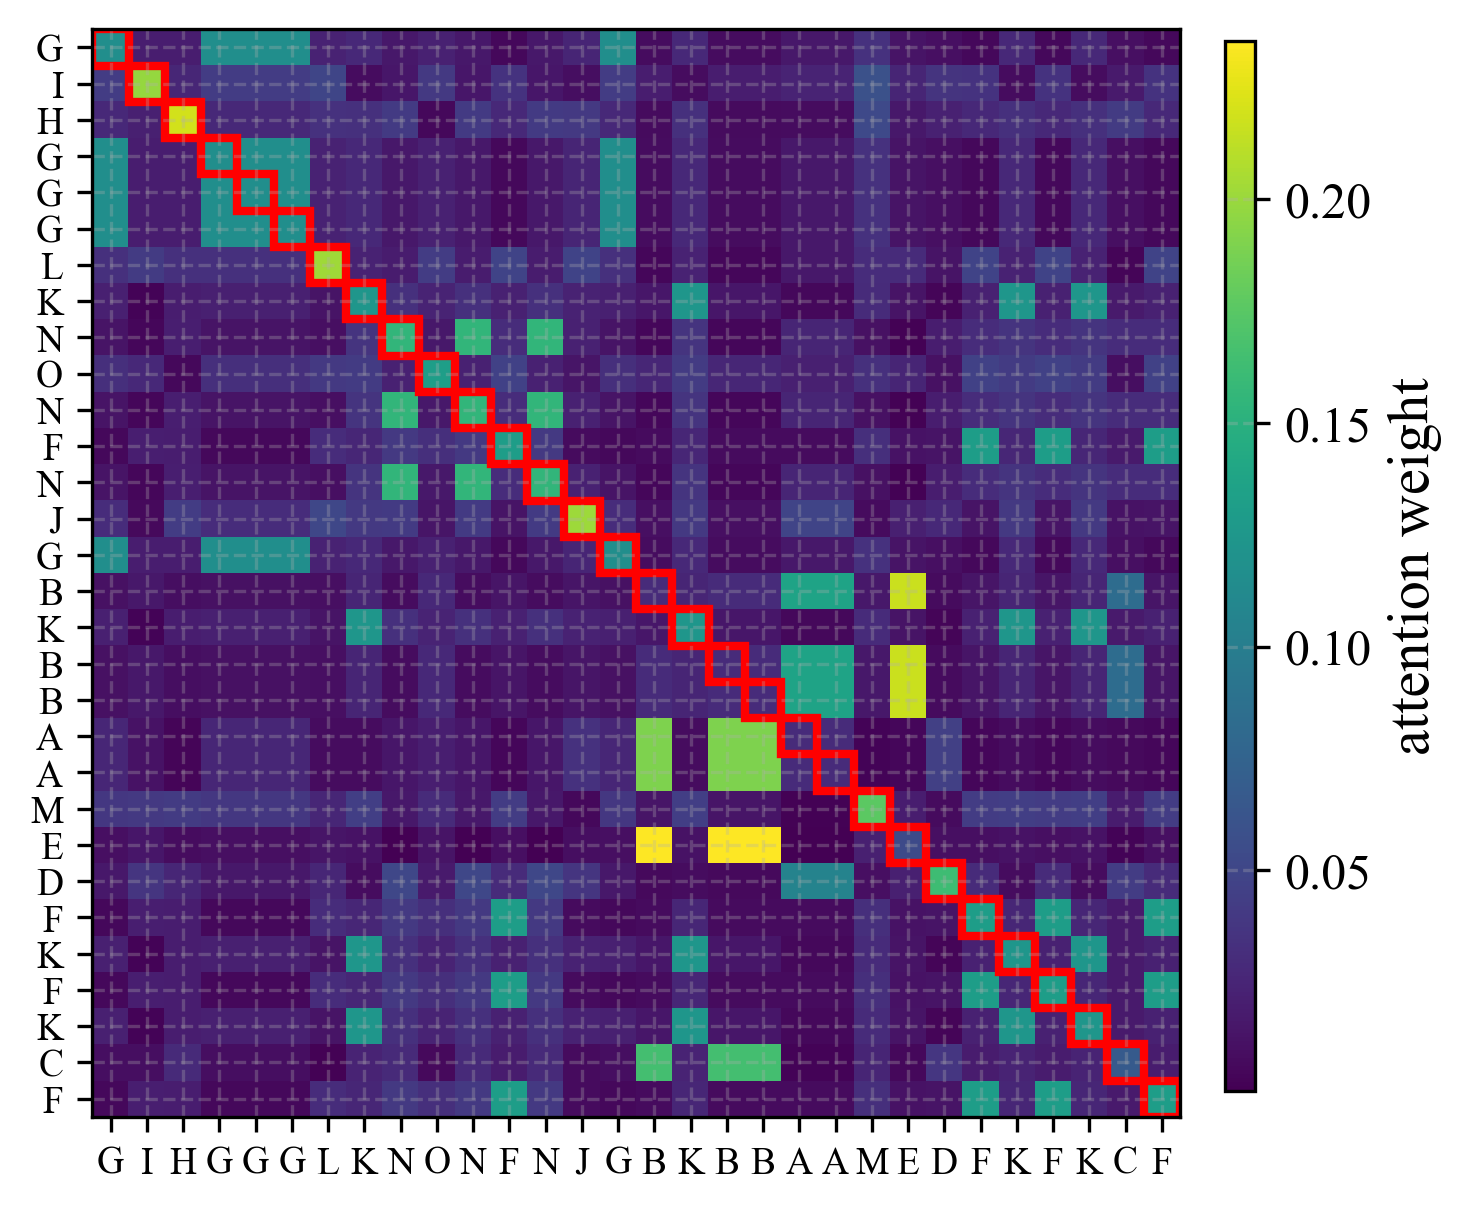

Processing file: attn_5.pkl
✅ Saved plot: ../results/run_20251218_1108/plots/attn_5_run3.png


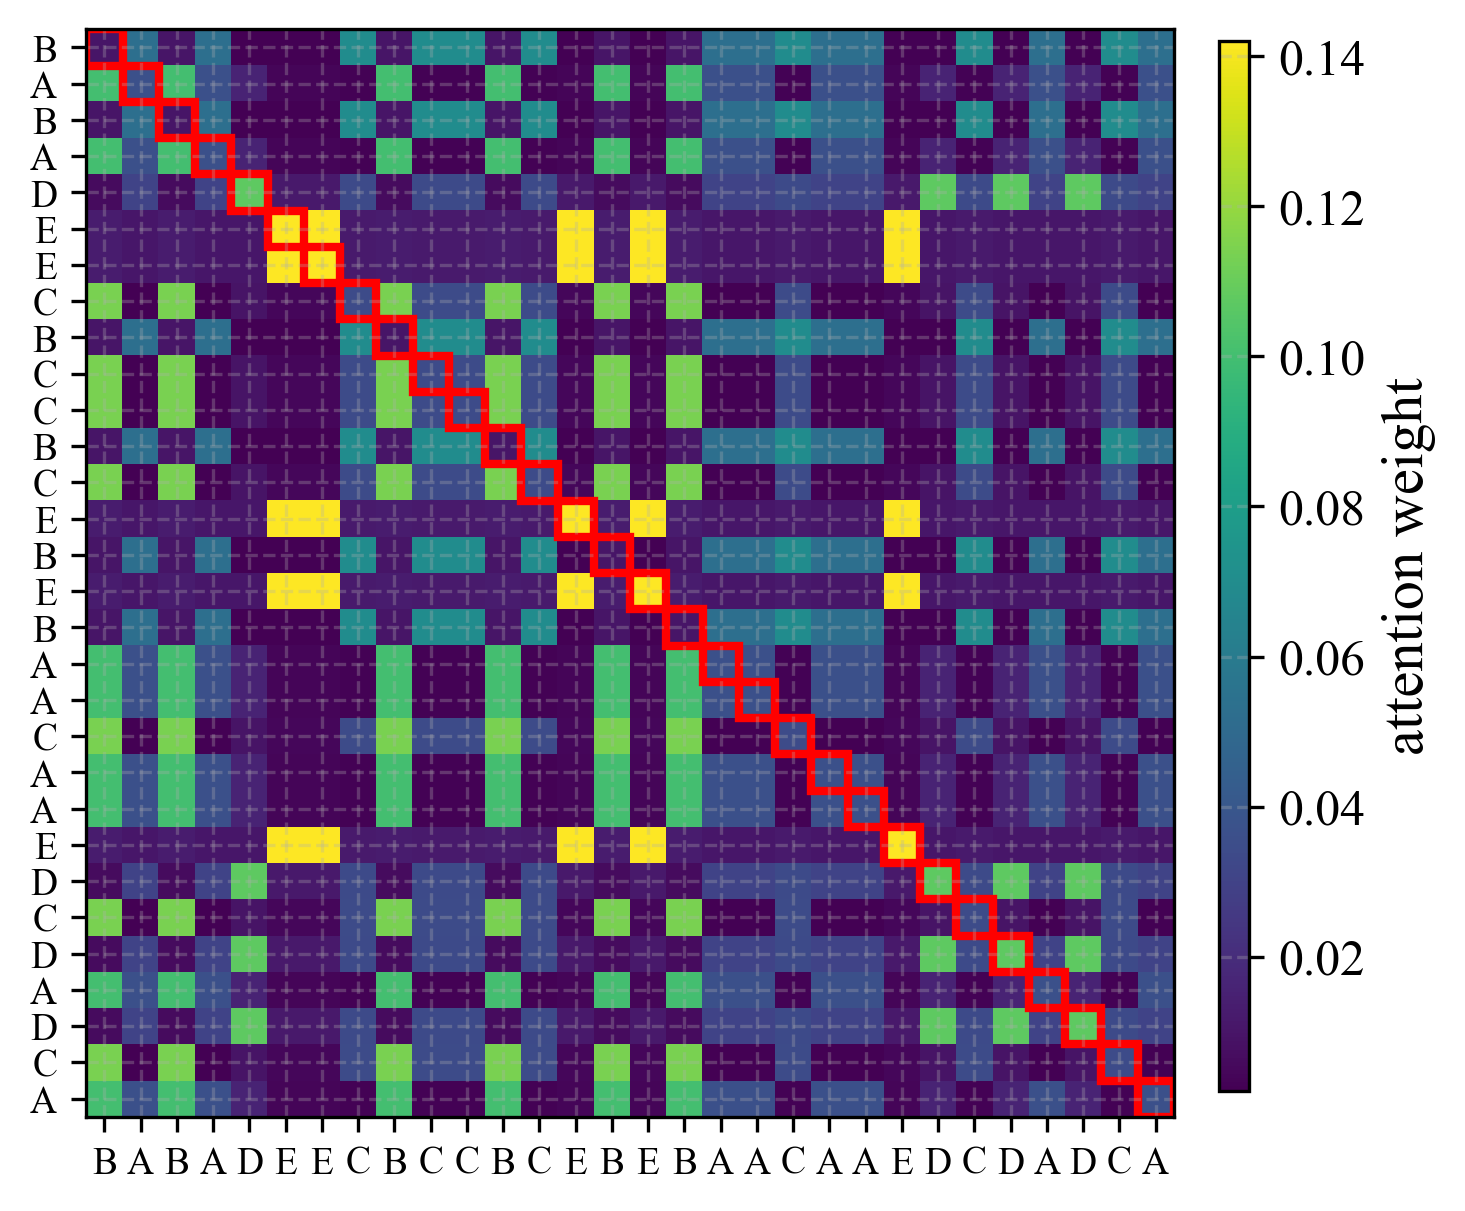

Processing file: attn_6.pkl
✅ Saved plot: ../results/run_20251218_1108/plots/attn_6_run3.png


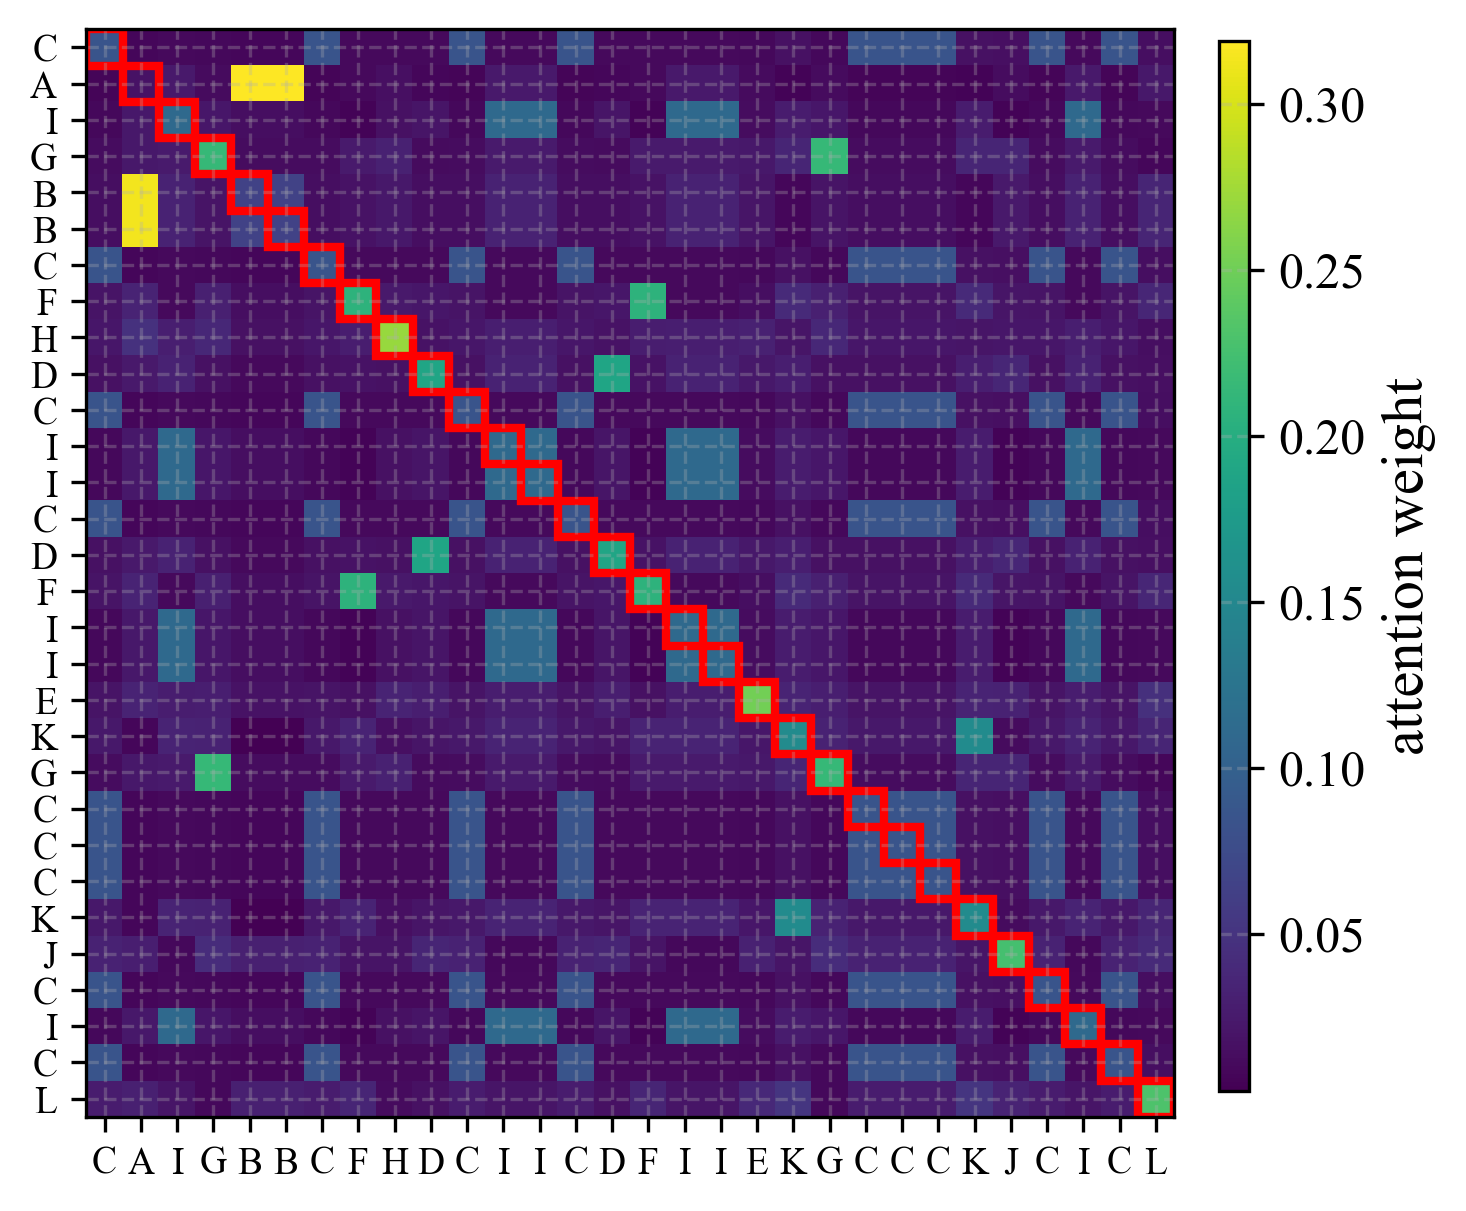

Processing file: attn_7.pkl
✅ Saved plot: ../results/run_20251218_1108/plots/attn_7_run3.png


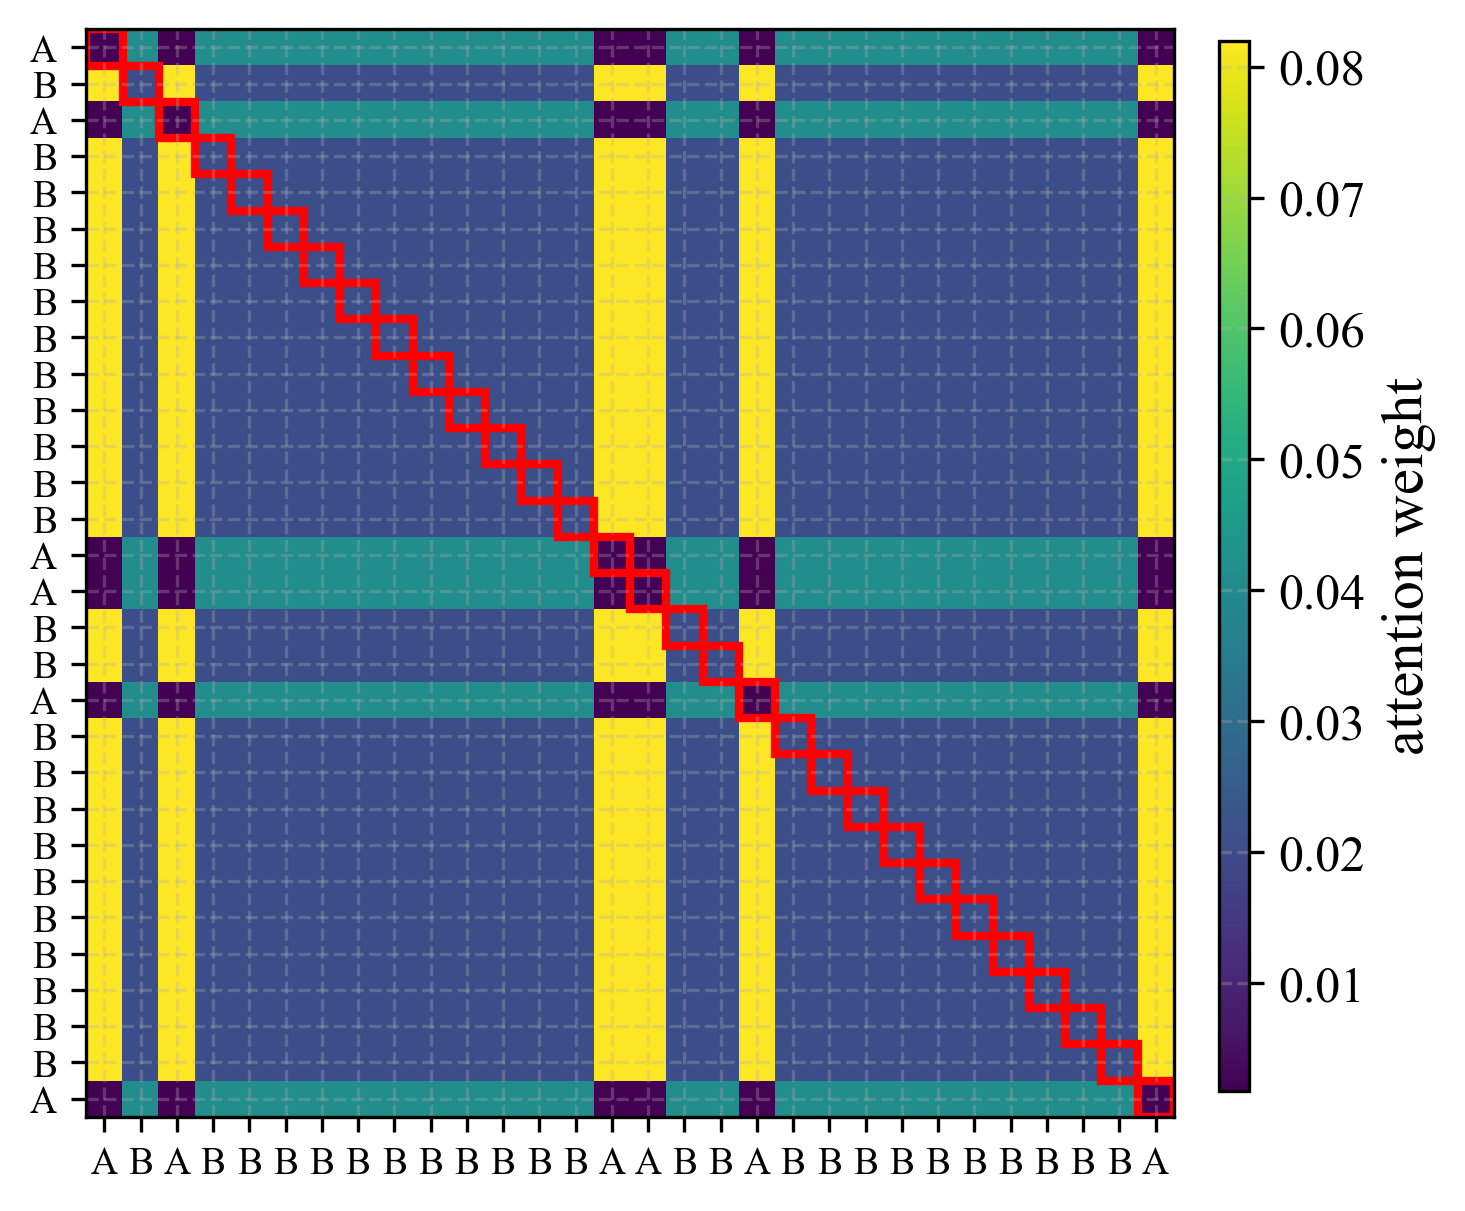

Processing file: attn_8.pkl
✅ Saved plot: ../results/run_20251218_1108/plots/attn_8_run3.png


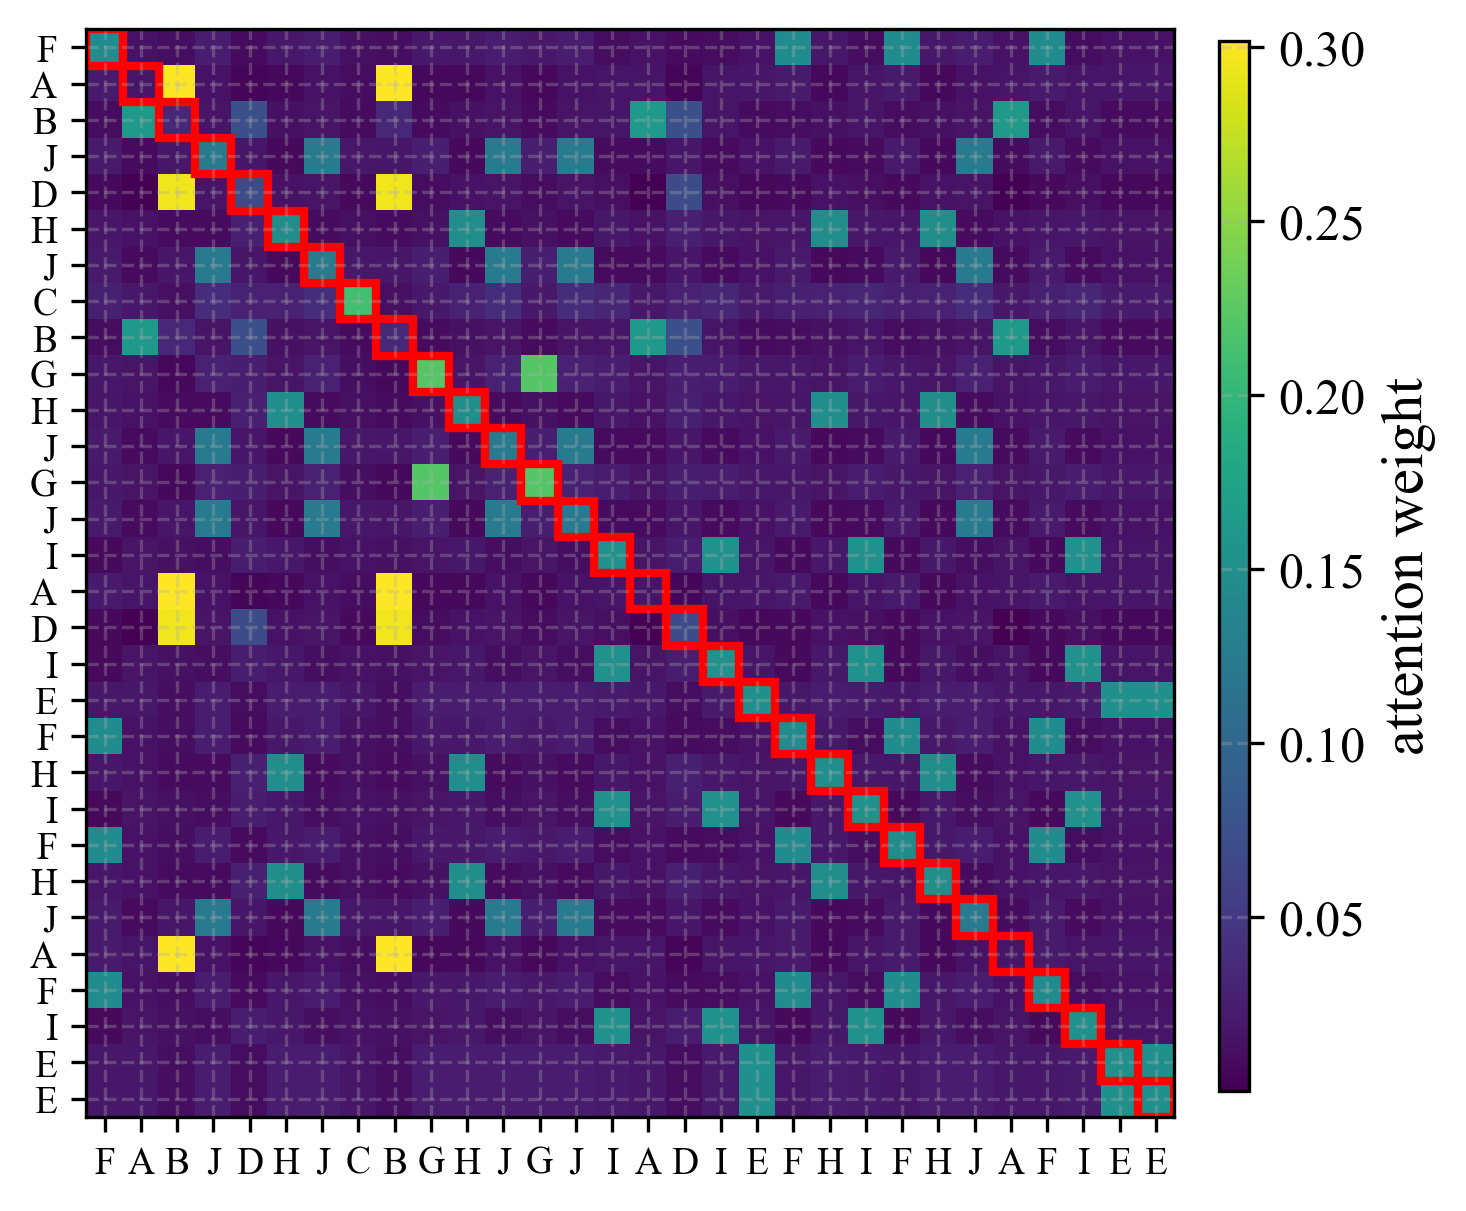

Processing file: attn_9.pkl
✅ Saved plot: ../results/run_20251218_1108/plots/attn_9_run3.png


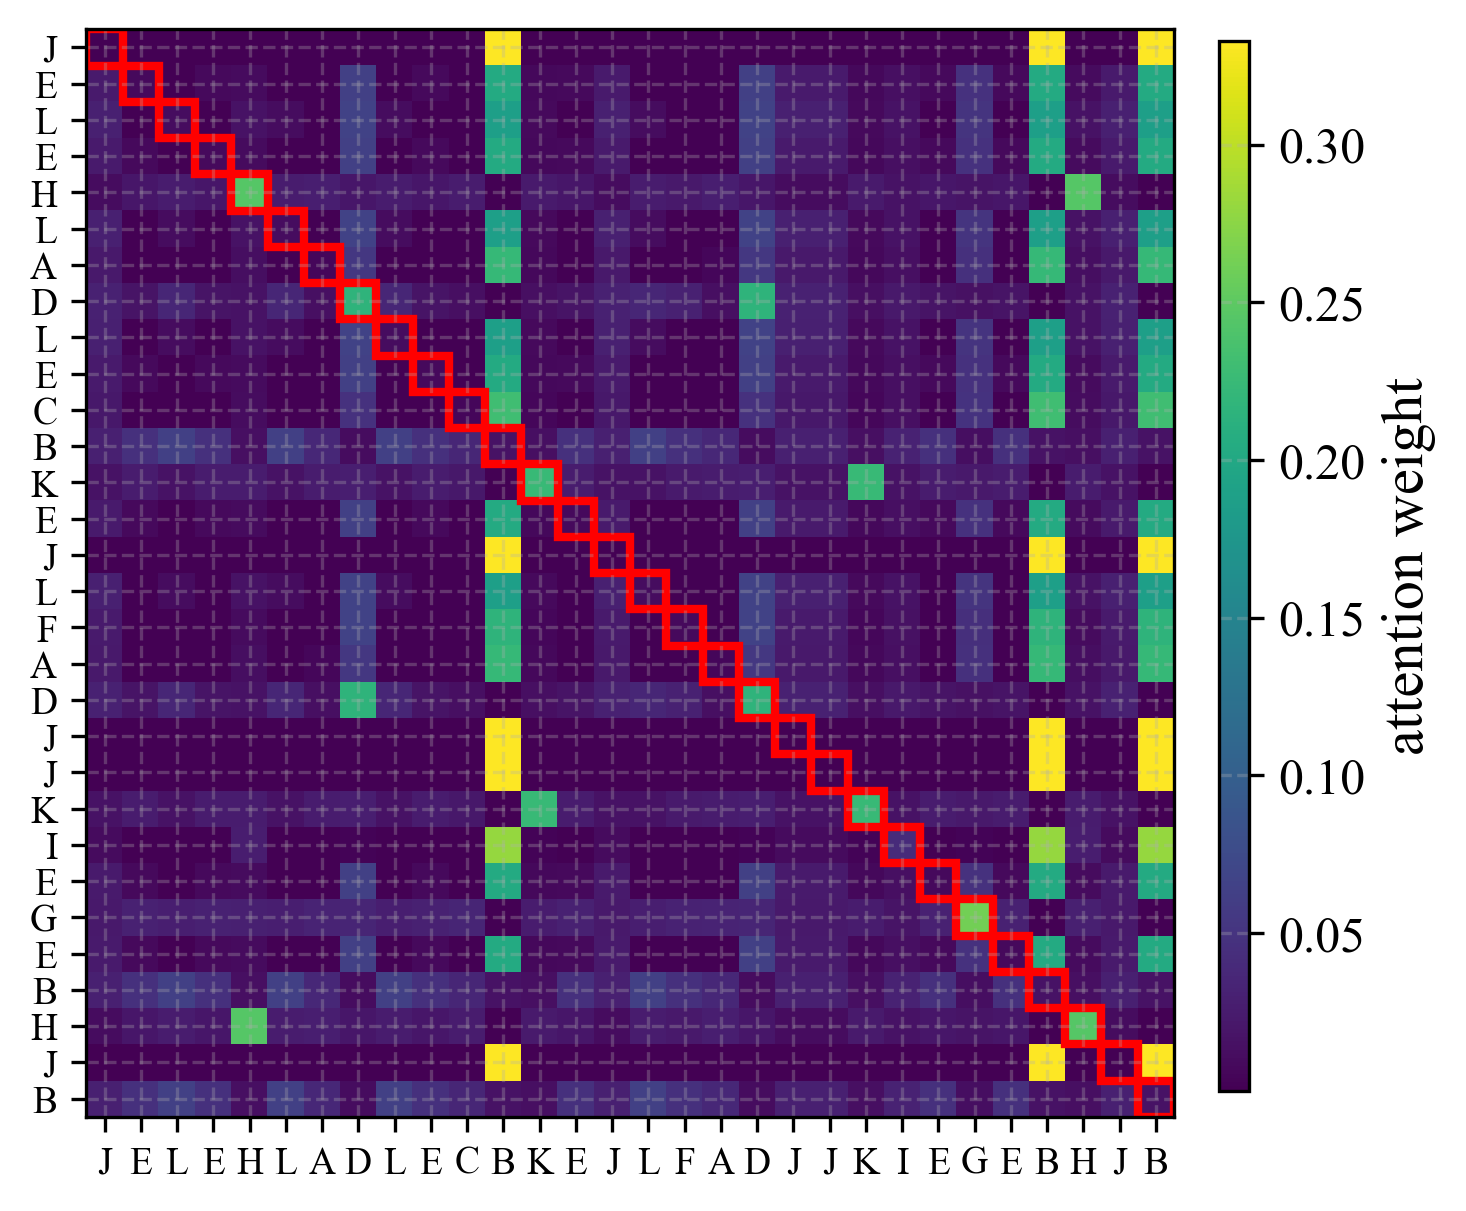

In [131]:
# Load attention and sequences
attn_files = sorted(glob.glob(os.path.join(run_dir, "attn_*.pkl")))
preds_files = sorted(glob.glob(os.path.join(run_dir, "preds_*.pkl")))

print(f"Found {len(attn_files)} attention files and {len(preds_files)} preds files")

# --- Configuration des chemins ---
# Assurez-vous que plot_path est défini avant la boucle
plot_path = os.path.join(run_dir, "plots") # Exemple de dossier de sortie
os.makedirs(plot_path, exist_ok=True) # Crée le dossier s'il n'existe pas

# --- Paramètres ---
NUM_EXAMPLES = 1 
RUN_IDX = 3
alphabet = list(string.ascii_uppercase)

print(f"Les images seront sauvegardées dans : {plot_path}")

for attn_path, preds_path in zip(attn_files, preds_files):

    print(f"Processing file: {os.path.basename(attn_path)}")

    # Load attention
    with open(attn_path, "rb") as f:
        attn_data = pickle.load(f)
    attn_all_runs = np.array(attn_data["attention_matrices"])

    # Load sequences
    with open(preds_path, "rb") as f:
        preds_data = pickle.load(f)
    seq_all_runs = preds_data["sequence_samples"]

    N_runs, N_samples, T, _ = attn_all_runs.shape

    # --- Select examples ---
    attn_examples = attn_all_runs[RUN_IDX, :NUM_EXAMPLES, :, :]
    seq_examples = seq_all_runs[RUN_IDX][:NUM_EXAMPLES]

    # Determine global min/max for colorbar
    vmin = attn_examples.min()
    vmax = attn_examples.max()

    # --- Plot matrices side by side ---
    fig, axes = plt.subplots(1, NUM_EXAMPLES, figsize=(5*NUM_EXAMPLES, 5))

    # Gestion axes unique vs multiple
    if NUM_EXAMPLES == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx in range(NUM_EXAMPLES):
        attn_matrix = attn_examples[idx]
        seq = seq_examples[idx]

        # Sequence → letters
        if seq.ndim == 2:
            token_seq = seq[:,0]
        elif seq.ndim == 1:
            token_seq = seq
        else:
            raise ValueError(f"Unexpected sequence shape: {seq.shape}")

        token_seq = token_seq[:T]
        token_labels = [alphabet[int(x) % len(alphabet)] for x in token_seq]
    
        ax = axes[idx]
        im = ax.imshow(attn_matrix, cmap="viridis", vmin=vmin, vmax=vmax)

        # Axis labels
        ax.set_xticks(np.arange(T))
        ax.set_xticklabels(token_labels, rotation=0, fontsize=9)
        ax.set_yticks(np.arange(T))
        ax.set_yticklabels(token_labels, fontsize=9)

        # Diagonal in red
        for i in range(T):
            rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)

    # --- Add colorbar ---
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="attention weight")

    # --- SAVE ---
    # 1. Récupérer le nom de base sans le chemin (ex: 'attn_data_01.pkl')
    base_name = os.path.basename(attn_path)
    # 2. Enlever l'extension .pkl (ex: 'attn_data_01')
    file_root = os.path.splitext(base_name)[0]
    # 3. Créer le nouveau nom .png
    save_name = f"{file_root}_run{RUN_IDX}.png"
    # 4. Joindre avec le dossier de destination
    save_full = os.path.join(plot_path, save_name)
    
    # bbox_inches='tight' enlève les marges blanches excessives
    fig.savefig(save_full, dpi=150, bbox_inches='tight') 
    
    print(f"✅ Saved plot: {save_full}")
    
    plt.show() # Optionnel si vous sauvegardez beaucoup de fichiers
    # plt.close(fig) # IMPORTANT : Ferme la figure pour libérer la mémoire (RAM)

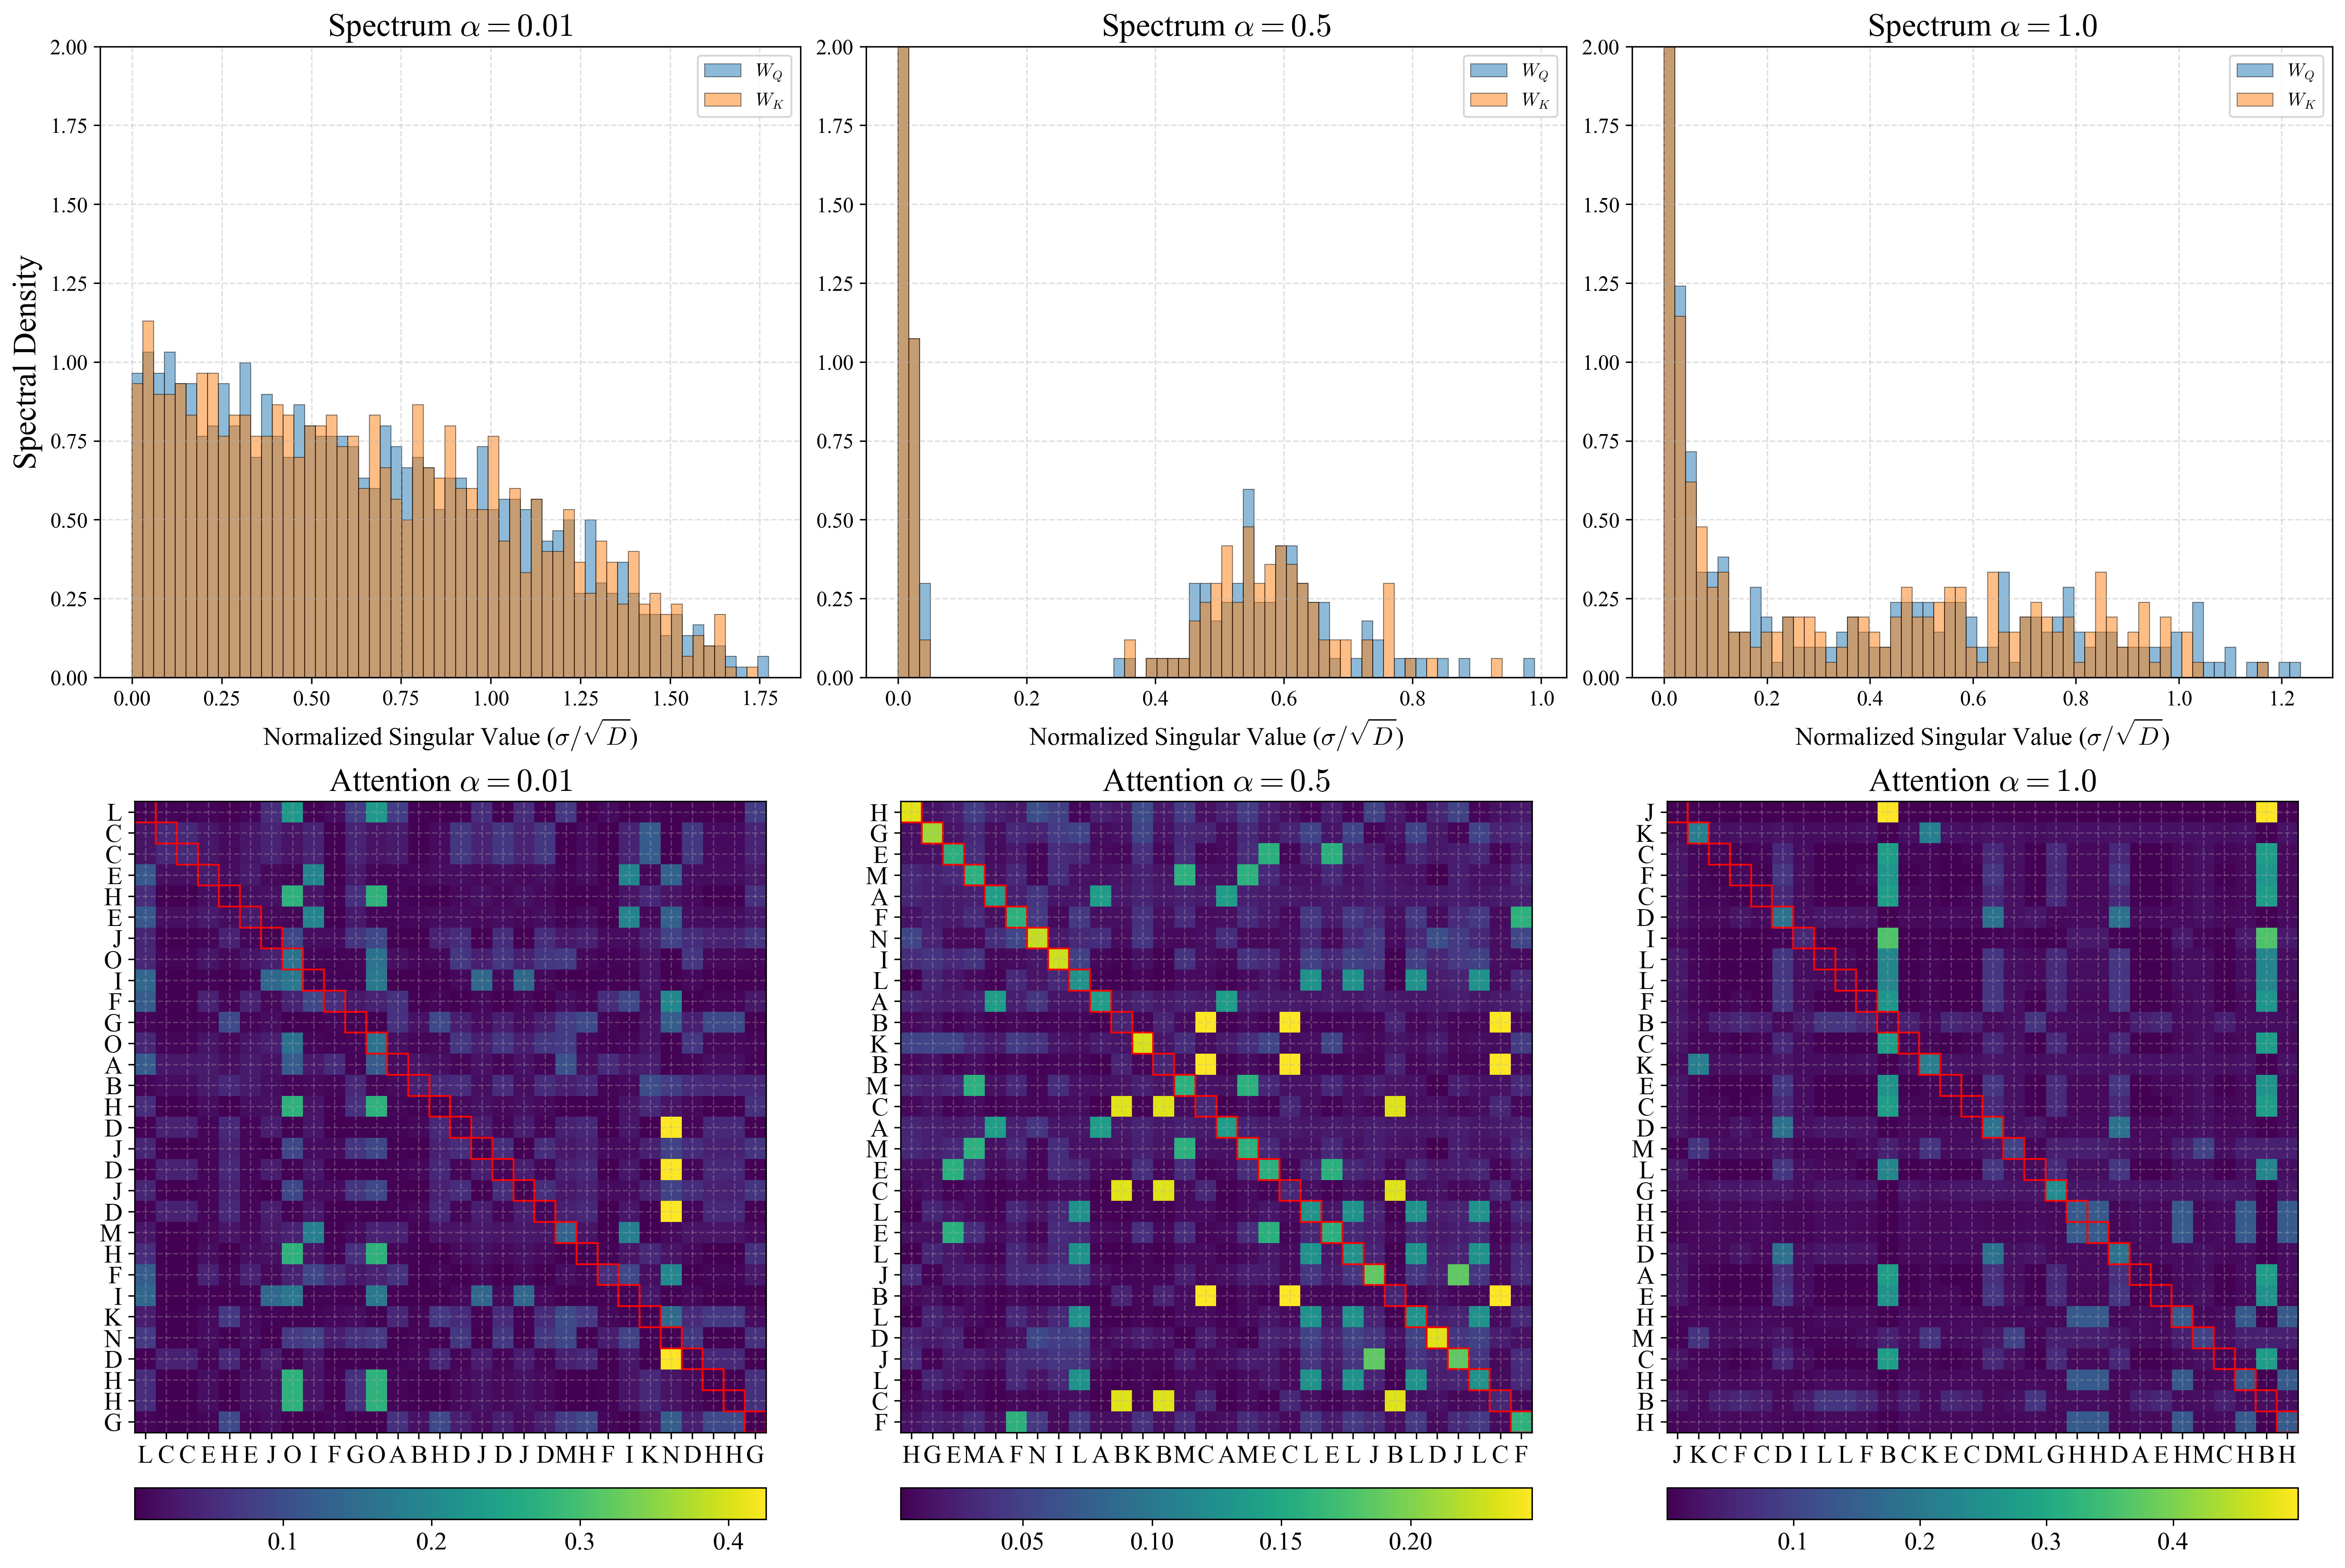

In [132]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
MLP_target = 100
INDICES_TO_PLOT = [0, 5, 14] 
TITLES = [r"$\alpha = 0.01$", r"$\alpha = 0.5$", r"$\alpha = 1.0$"]

RUN_IDX = 3       
SAMPLE_IDX = 2   
alphabet = list(string.ascii_uppercase)

heavy_files = sorted(glob.glob(os.path.join(run_dir, "heavy_data_*.pkl")))
attn_files = sorted(glob.glob(os.path.join(run_dir, "attn_*.pkl")))
preds_files = sorted(glob.glob(os.path.join(run_dir, "preds_*.pkl")))

# ==========================================
# 2. GÉNÉRATION DE LA FIGURE
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12), constrained_layout=True)

for col, file_idx in enumerate(INDICES_TO_PLOT):
    current_title = TITLES[col]

    # --- CHARGEMENT ---
    with open(heavy_files[file_idx], "rb") as f:
        h_data = pickle.load(f)
    
    # Adaptation Untied : On cherche W_Q et W_K
    W_Q_runs = h_data.get("W_Q_runs", [])
    W_K_runs = h_data.get("W_K_runs", [])
    
    with open(attn_files[file_idx], "rb") as f:
        a_data = pickle.load(f)
    with open(preds_files[file_idx], "rb") as f:
        p_data = pickle.load(f)
        
    # --- PLOT 1 : SPECTRE COMPARATIF (Haut) ---
    ax_spec = axes[0, col]
    
    def get_normalized_svd(w_list):
        if len(w_list) == 0: return None
        D = w_list[0].shape[0] # Dimension d'entrée
        svds = [np.linalg.svd(W, compute_uv=False) / np.sqrt(D) for W in w_list]
        return np.concatenate(svds)

    flat_Q = get_normalized_svd(W_Q_runs)
    flat_K = get_normalized_svd(W_K_runs)

    # Plot des deux histogrammes superposés
    bins = np.linspace(min(flat_Q.min(), flat_K.min()),max(flat_Q.max(), flat_K.max()),60)
    
    if flat_Q is not None:
        ax_spec.hist(flat_Q, bins=bins, density=True, alpha=0.5, 
                     color="#1f77b4", label=r"$W_Q$", edgecolor='black', linewidth=0.5)
    
    if flat_K is not None:
        ax_spec.hist(flat_K, bins=bins, density=True, alpha=0.5, 
                     color="#ff7f0e", label=r"$W_K$", edgecolor='black', linewidth=0.5)
    
    ax_spec.set_title(f"Spectrum {current_title}", fontsize=18)
    ax_spec.set_xlabel(r"Normalized Singular Value ($\sigma / \sqrt{D}$)")
    ax_spec.set_ylim(0, 2.0) # Ajusté selon ton exemple (était 0.2, mais density=True souvent > 1)
    ax_spec.grid(True, linestyle="--", alpha=0.4)
    ax_spec.legend(fontsize=10)
    
    if col == 0:
        ax_spec.set_ylabel("Spectral Density",  fontsize=18)

    # --- PLOT 2 : MATRICE D'ATTENTION (Bas) ---
    ax_attn = axes[1, col]
    
    attn_matrix = np.array(a_data["attention_matrices"])[RUN_IDX, SAMPLE_IDX]
    seq = p_data["sequence_samples"][RUN_IDX][SAMPLE_IDX]
    T = attn_matrix.shape[0]

    if seq.ndim == 2: seq = seq[:, 0]
    token_labels = [alphabet[int(x) % len(alphabet)] for x in seq[:T]]

    im = ax_attn.imshow(attn_matrix, cmap="viridis", aspect='equal') 
    ax_attn.set_title(f"Attention {current_title}", fontsize=18)
    
    ax_attn.set_xticks(np.arange(T))
    ax_attn.set_xticklabels(token_labels, fontsize=14)
    ax_attn.set_yticks(np.arange(T))
    ax_attn.set_yticklabels(token_labels, fontsize=14)
    
    # Marquage de la diagonale
    for i in range(T):
        rect = Rectangle((i-0.5, i-0.5), 1, 1, linewidth=1, edgecolor='red', facecolor='none')
        ax_attn.add_patch(rect)

    # Colorbar horizontale sous chaque matrice
    cbar = plt.colorbar(im, ax=ax_attn, orientation='horizontal', location='bottom',
                        fraction=0.05, pad=0.03)
    cbar.ax.tick_params(labelsize=14)

# ==========================================
# 3. SAUVEGARDE
# ==========================================
save_name = f"Untied_Spectra_Attention_Comparison_MLP{MLP_target}.png"
full_path = os.path.join(plot_path, save_name)
plt.savefig(full_path, dpi=300, bbox_inches='tight')
plt.show()